

---
#Smart-Vehical-Health-Intelligence-and-Predictive-Maintenance-Recommendation-System


---



In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:

# =============================================================================
# Dataset Path
# =============================================================================

DATASET_PATH = "/content/drive/MyDrive/Btech Final Year Project/Dataset/flex_fuel_predictive_maintenance_dataset_augmented.csv"
# =============================================================================
# Load Dataset
# =============================================================================

from pathlib import Path
import pandas as pd

# Check whether the dataset exists
if not Path(DATASET_PATH).exists():
    raise FileNotFoundError(
        f"Dataset not found.\nPlease check the path:\n{DATASET_PATH}"
    )

# Load dataset
vehicle_df = pd.read_csv(DATASET_PATH)

# Check if dataset is empty
if vehicle_df.empty:
    raise ValueError("The dataset is empty.")

print("✅ Dataset loaded successfully.")
print(f"Shape : {vehicle_df.shape}")

# Display first 5 rows
display(vehicle_df.head())

✅ Dataset loaded successfully.
Shape : (120000, 56)


,Vehicle_ID,Timestamp,Vehicle_Model,Vehicle_Age_years,Engine_Size_cc,Fuel_System_Material_Compatibility,Climate_Region,Ambient_Temperature_C,Humidity_Pct,Altitude_m,...,Fuel_Line_Seal_Condition,O2_Sensor_Response_ms,Cold_Start_Duration_s,Cranking_Voltage_V,Time_Since_Last_Service_days,Time_Since_Injector_Replacement_km,Time_Since_SparkPlug_Replacement_km,Need_Maintenance,Failure_Type,Remaining_Useful_Life_km
0,FFV2-000001,2023-07-04,Truck,10,2876,Standard,Coastal,22.3,73.3,394.0,...,Pass,151.0,1.47,11.70,19.0,140675.0,19822.0,Yes,Catalytic Converter,5383.0
1,FFV2-000002,2024-08-21,SUV,8,1935,Retrofit-Upgraded,Arid,22.7,29.3,629.0,...,Pass,140.0,1.74,11.79,93.0,158999.0,13537.0,Yes,Electrical,4120.0
2,FFV2-000003,2024-02-28,Truck,3,2964,Ethanol-Compatible (Tier-2/3),Arid,35.5,21.6,1538.0,...,Pass,96.0,1.47,12.10,221.0,51807.0,22730.0,No,No Failure,15566.0
3,FFV2-000004,2024-02-09,SUV,10,1945,Standard,Humid,23.8,78.2,391.0,...,Pass,129.0,1.67,NaN,23.0,121717.0,50980.0,Yes,Fuel System,3256.0
4,FFV2-000005,2024-05-16,Car,10,1125,Standard,Arid,40.5,28.0,NaN,...,Pass,160.0,1.86,11.80,195.0,3064.0,84.0,Yes,Injector,1037.0


In [63]:
# =============================================================================
# Stage 1 – Dataset Inspection
# =============================================================================

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 1 – Dataset Inspection")
print("=" * 80)

import pandas as pd
import numpy as np

# =============================================================================
# 1. Dataset Shape
# =============================================================================

print("\n" + "=" * 80)
print("1. DATASET SHAPE")
print("=" * 80)

print(f"Rows    : {vehicle_df.shape[0]:,}")
print(f"Columns : {vehicle_df.shape[1]}")

# =============================================================================
# 2. First Five Records
# =============================================================================

print("\n" + "=" * 80)
print("2. FIRST FIVE RECORDS")
print("=" * 80)

display(vehicle_df.head())

# =============================================================================
# 3. Dataset Information
# =============================================================================

print("\n" + "=" * 80)
print("3. DATASET INFORMATION")
print("=" * 80)

vehicle_df.info()

# =============================================================================
# 4. Data Types
# =============================================================================

print("\n" + "=" * 80)
print("4. DATA TYPES")
print("=" * 80)

display(vehicle_df.dtypes.to_frame(name="Data Type"))

# =============================================================================
# 5. Missing Value Analysis
# =============================================================================

print("\n" + "=" * 80)
print("5. MISSING VALUE ANALYSIS")
print("=" * 80)

missing = pd.DataFrame({
    "Missing Values": vehicle_df.isnull().sum(),
    "Missing Percentage (%)":
    (vehicle_df.isnull().mean()*100).round(2)
})

missing = missing[missing["Missing Values"] > 0]

if missing.empty:
    print("No missing values found.")
else:
    display(
        missing.sort_values(
            by="Missing Percentage (%)",
            ascending=False
        )
    )

# =============================================================================
# 6. Duplicate Analysis
# =============================================================================

print("\n" + "=" * 80)
print("6. DUPLICATE ANALYSIS")
print("=" * 80)

duplicates = vehicle_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates:,}")

# =============================================================================
# 7. Statistical Summary
# =============================================================================

print("\n" + "=" * 80)
print("7. NUMERICAL FEATURE SUMMARY")
print("=" * 80)

display(vehicle_df.describe())

# =============================================================================
# 8. Target Variable Analysis
# =============================================================================

print("\n" + "=" * 80)
print("8. TARGET VARIABLE ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# Primary Target
# -------------------------------------------------------------------------

print("\nNeed_Maintenance Distribution\n")

display(vehicle_df["Need_Maintenance"].value_counts())

print("\nPercentage Distribution\n")

display(
    (
        vehicle_df["Need_Maintenance"]
        .value_counts(normalize=True)*100
    ).round(2)
)

# -------------------------------------------------------------------------
# Secondary Target
# -------------------------------------------------------------------------

print("\nFailure_Type Distribution\n")

display(vehicle_df["Failure_Type"].value_counts())

# -------------------------------------------------------------------------
# Remaining Useful Life
# -------------------------------------------------------------------------

print("\nRemaining_Useful_Life_km Summary\n")

display(vehicle_df["Remaining_Useful_Life_km"].describe())

# =============================================================================
# 9. Dataset Quality Summary
# =============================================================================

print("\n" + "=" * 80)
print("9. DATASET QUALITY SUMMARY")
print("=" * 80)

print(f"Total Features          : {vehicle_df.shape[1]}")
print(f"Total Records           : {vehicle_df.shape[0]:,}")
print(f"Missing Values          : {vehicle_df.isnull().sum().sum():,}")
print(f"Duplicate Rows          : {duplicates:,}")

numeric = vehicle_df.select_dtypes(include=np.number).shape[1]
categorical = vehicle_df.select_dtypes(
    include=["object", "category", "bool"]
).shape[1]

print(f"Numeric Features        : {numeric}")
print(f"Categorical Features    : {categorical}")

# =============================================================================
# 10. Observations
# =============================================================================

print("\n" + "=" * 80)
print("10. OBSERVATIONS")
print("=" * 80)

print("• Dataset loaded successfully.")
print("• Dataset structure verified.")
print("• Data types inspected.")
print("• Missing values identified.")
print("• Duplicate rows checked.")
print("• Target variables verified.")
print("• Dataset remains unchanged.")
print("• Dataset is ready for Stage 2 (Exploratory Data Analysis).")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 1 – Dataset Inspection

1. DATASET SHAPE
Rows    : 120,000
Columns : 56

2. FIRST FIVE RECORDS


,Vehicle_ID,Timestamp,Vehicle_Model,Vehicle_Age_years,Engine_Size_cc,Fuel_System_Material_Compatibility,Climate_Region,Ambient_Temperature_C,Humidity_Pct,Altitude_m,...,Fuel_Line_Seal_Condition,O2_Sensor_Response_ms,Cold_Start_Duration_s,Cranking_Voltage_V,Time_Since_Last_Service_days,Time_Since_Injector_Replacement_km,Time_Since_SparkPlug_Replacement_km,Need_Maintenance,Failure_Type,Remaining_Useful_Life_km
0,FFV2-000001,2023-07-04,Truck,10,2876,Standard,Coastal,22.3,73.3,394.0,...,Pass,151.0,1.47,11.70,19.0,140675.0,19822.0,Yes,Catalytic Converter,5383.0
1,FFV2-000002,2024-08-21,SUV,8,1935,Retrofit-Upgraded,Arid,22.7,29.3,629.0,...,Pass,140.0,1.74,11.79,93.0,158999.0,13537.0,Yes,Electrical,4120.0
2,FFV2-000003,2024-02-28,Truck,3,2964,Ethanol-Compatible (Tier-2/3),Arid,35.5,21.6,1538.0,...,Pass,96.0,1.47,12.10,221.0,51807.0,22730.0,No,No Failure,15566.0
3,FFV2-000004,2024-02-09,SUV,10,1945,Standard,Humid,23.8,78.2,391.0,...,Pass,129.0,1.67,NaN,23.0,121717.0,50980.0,Yes,Fuel System,3256.0
4,FFV2-000005,2024-05-16,Car,10,1125,Standard,Arid,40.5,28.0,NaN,...,Pass,160.0,1.86,11.80,195.0,3064.0,84.0,Yes,Injector,1037.0



3. DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 56 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Vehicle_ID                           120000 non-null  object 
 1   Timestamp                            120000 non-null  object 
 2   Vehicle_Model                        120000 non-null  object 
 3   Vehicle_Age_years                    120000 non-null  int64  
 4   Engine_Size_cc                       120000 non-null  int64  
 5   Fuel_System_Material_Compatibility   120000 non-null  object 
 6   Climate_Region                       120000 non-null  object 
 7   Ambient_Temperature_C                117547 non-null  float64
 8   Humidity_Pct                         115229 non-null  float64
 9   Altitude_m                           112788 non-null  float64
 10  Ethanol_Content_Pct                  120000 non-null  fl

,Data Type
Vehicle_ID,object
Timestamp,object
Vehicle_Model,object
Vehicle_Age_years,int64
Engine_Size_cc,int64
Fuel_System_Material_Compatibility,object
Climate_Region,object
Ambient_Temperature_C,float64
Humidity_Pct,float64
Altitude_m,float64



5. MISSING VALUE ANALYSIS


...


Failure_Type Distribution



,count
Failure_Type,
No Failure,60833
Fuel System,10071
Cooling System,9685
Electrical,8615
Ignition,8501
Injector,8069
Lubrication,7341
Catalytic Converter,6885



Remaining_Useful_Life_km Summary



,Remaining_Useful_Life_km
count,120000.000000
mean,10092.204903
std,4791.888194
min,200.000000
25%,6047.270000
50%,10399.620000
75%,14293.355000
max,20000.000000



9. DATASET QUALITY SUMMARY
Total Features          : 56
Total Records           : 120,000
Missing Values          : 156,626
Duplicate Rows          : 0
Numeric Features        : 45
Categorical Features    : 11

10. OBSERVATIONS
• Dataset loaded successfully.
• Dataset structure verified.
• Data types inspected.
• Missing values identified.
• Duplicate rows checked.
• Target variables verified.
• Dataset remains unchanged.
• Dataset is ready for Stage 2 (Exploratory Data Analysis).


SMART VEHICLE HEALTH INTELLIGENCE
Stage 2 – Exploratory Data Analysis (EDA)

1. Need_Maintenance Distribution


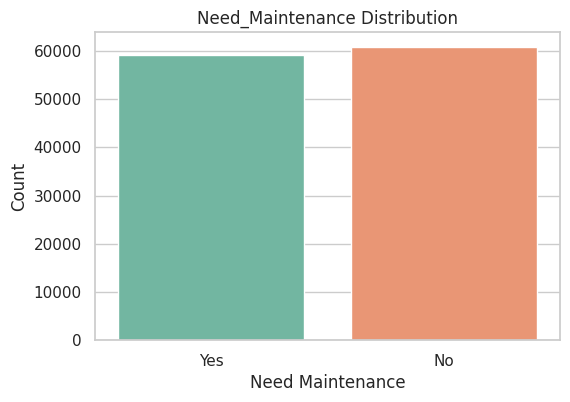

Need_Maintenance
No     50.694167
Yes    49.305833
Name: proportion, dtype: float64

2. Failure Type Distribution


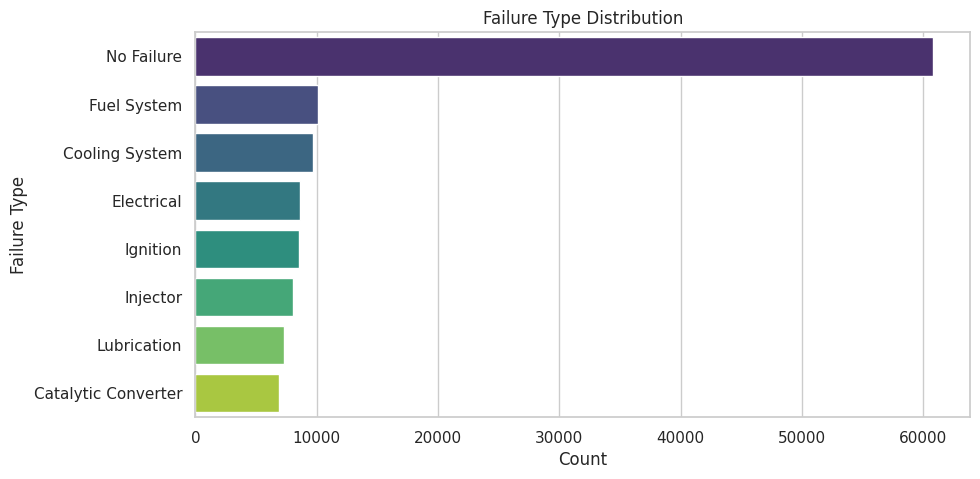


3. Remaining Useful Life Distribution


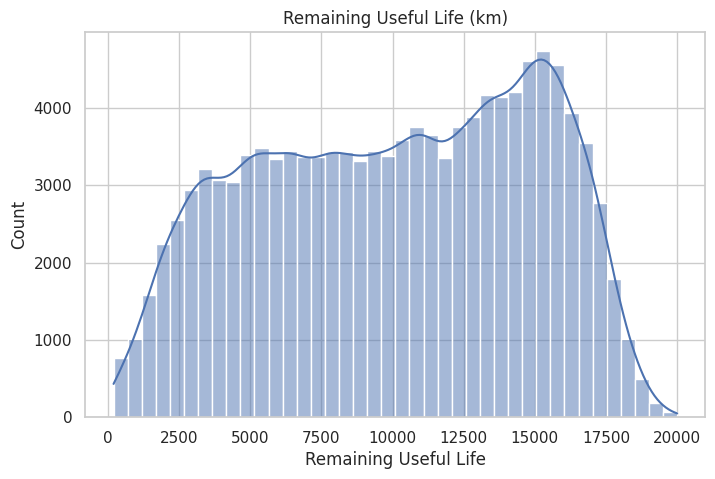


4. Missing Value Analysis


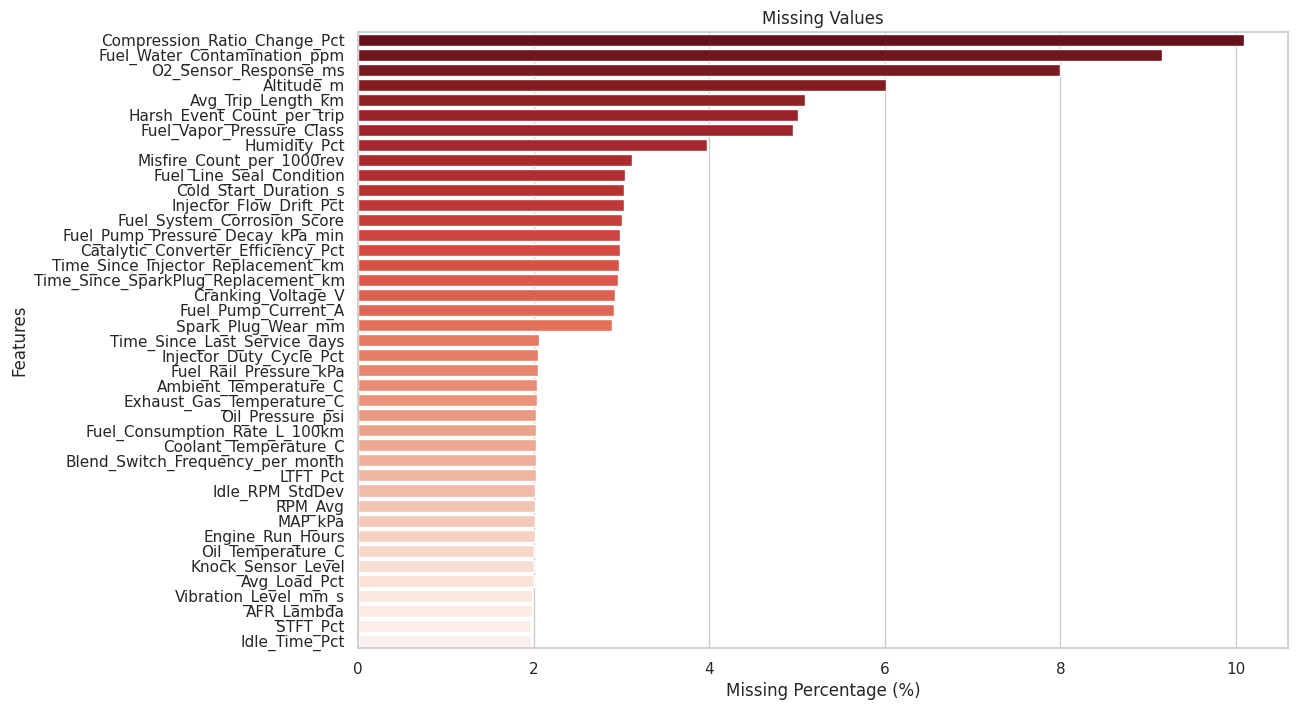


5. Numerical Feature Distribution


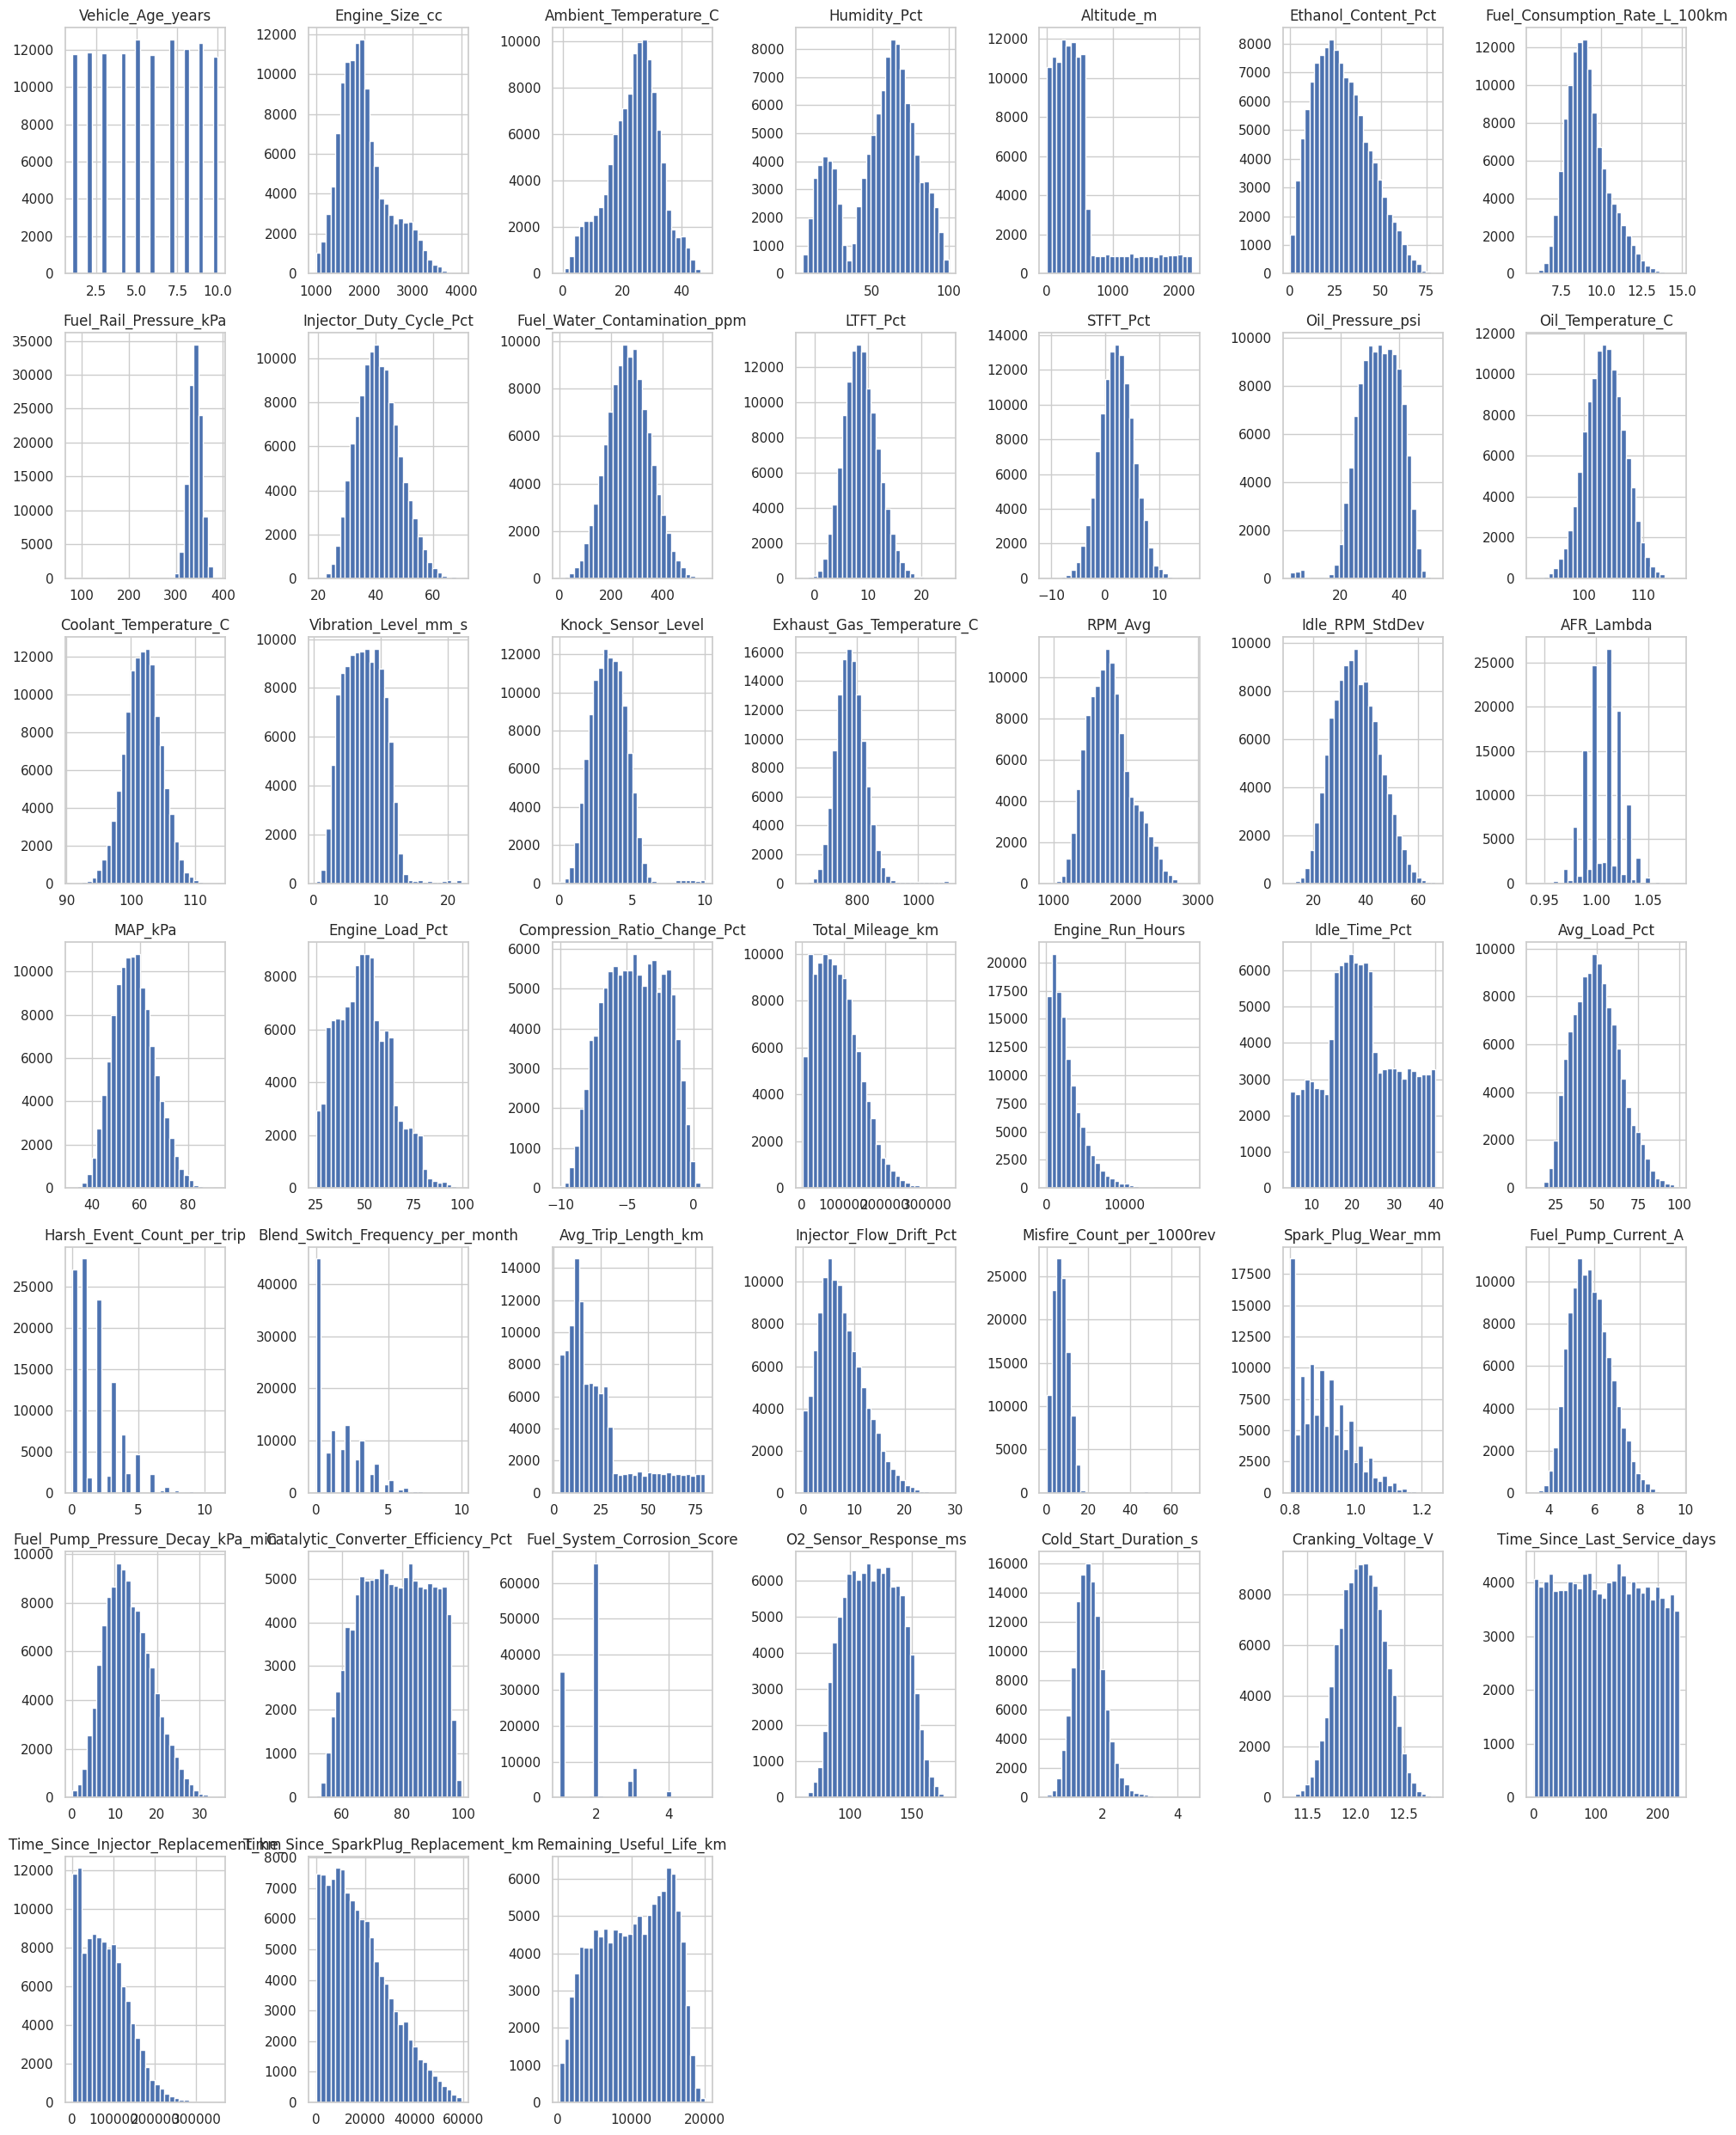


6. Correlation Heatmap


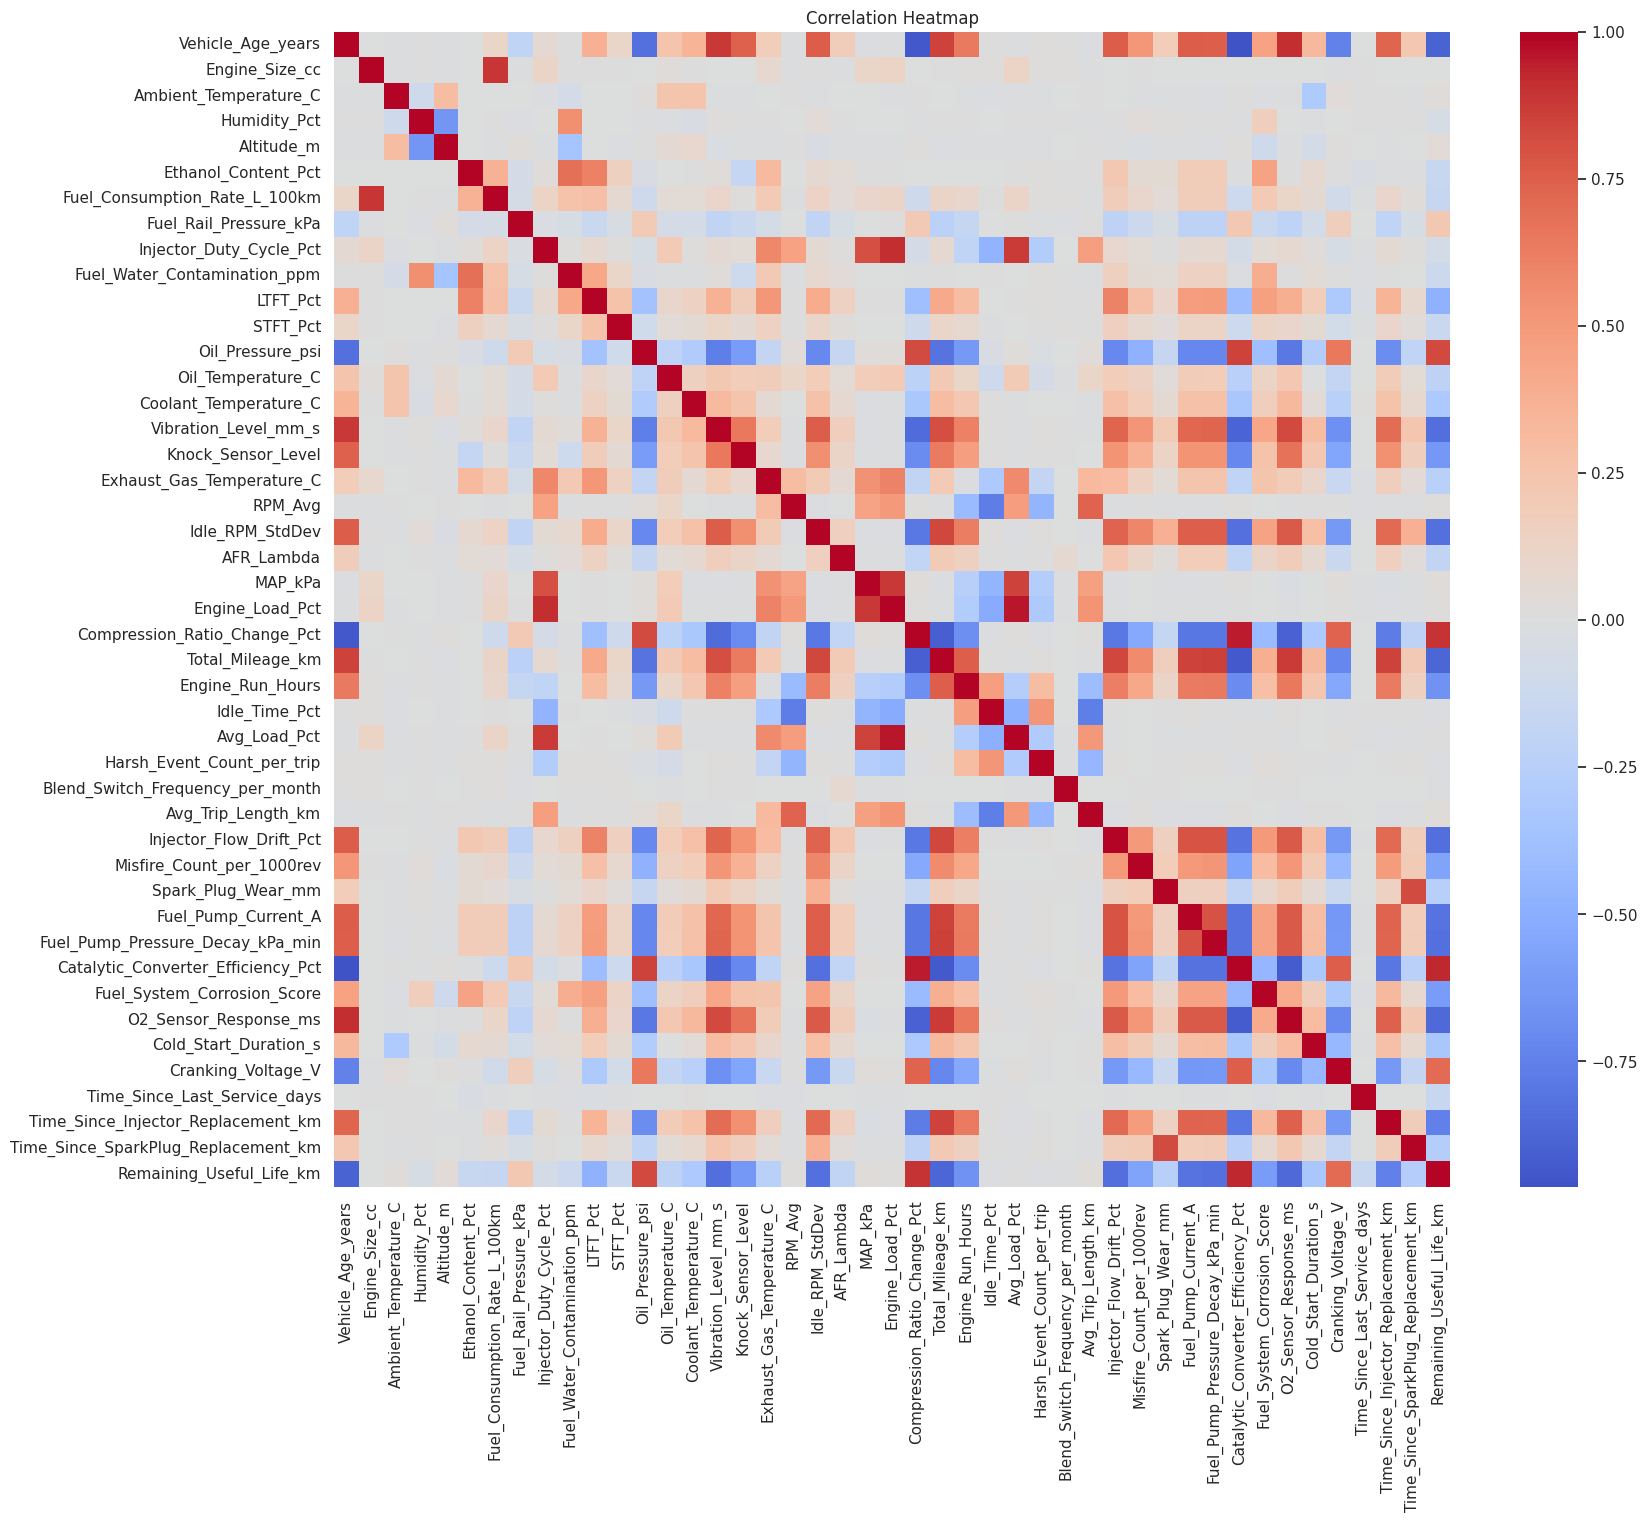


7. Outlier Analysis


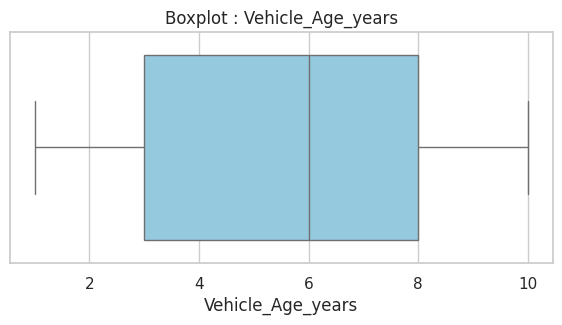

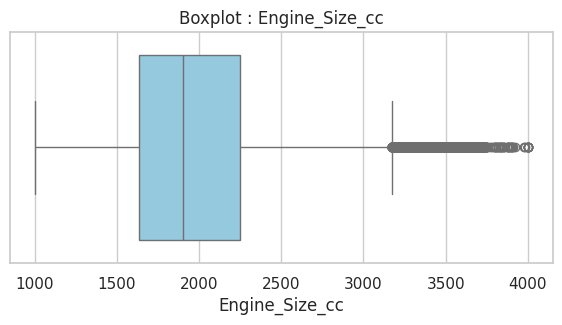

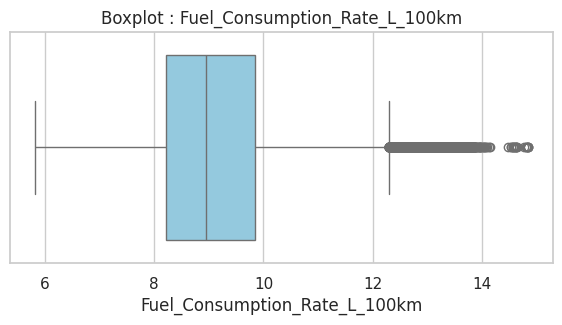

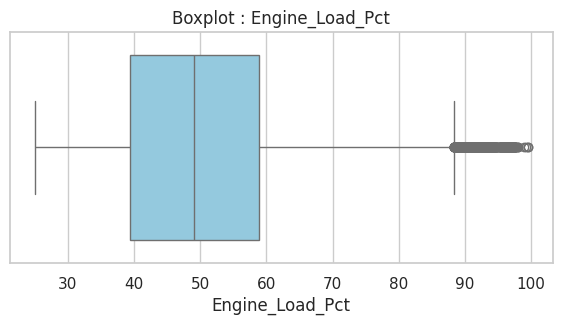

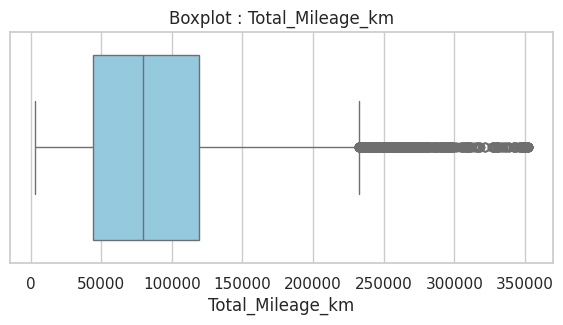

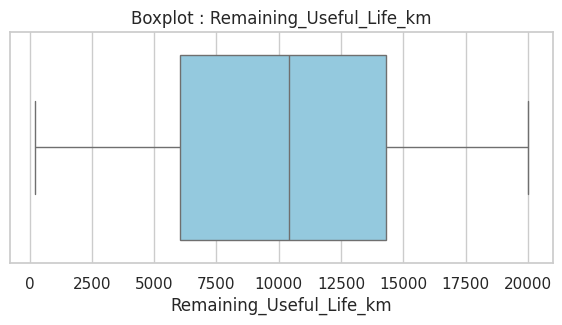


8. Important Categorical Features


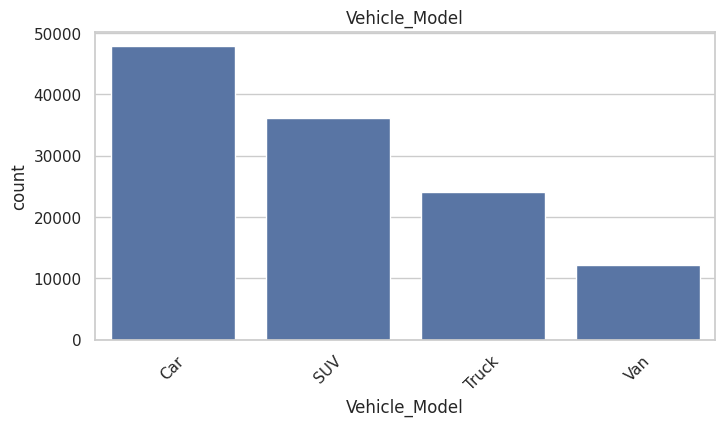

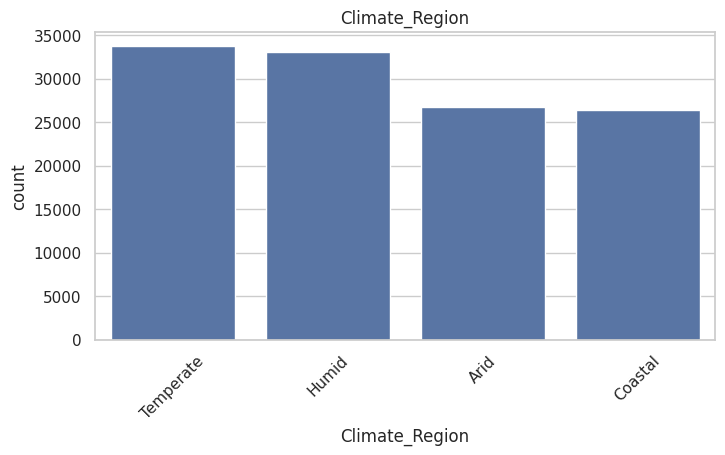

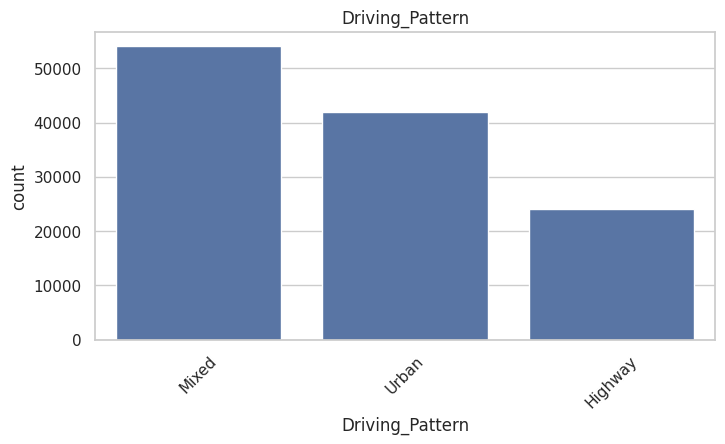

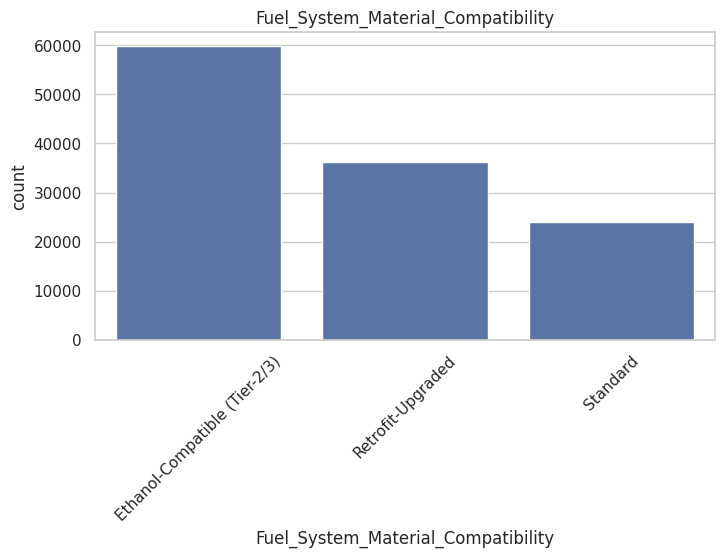


9. Important Features vs Need_Maintenance


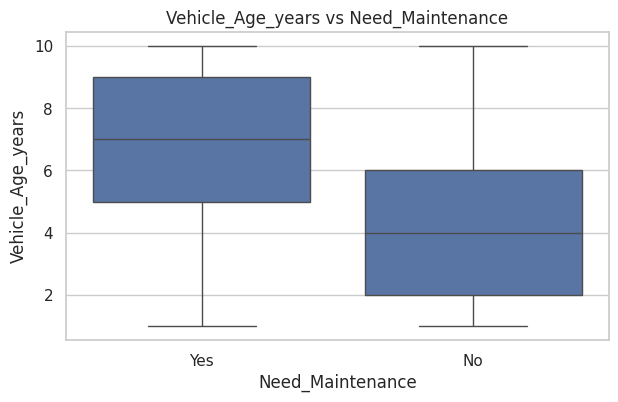

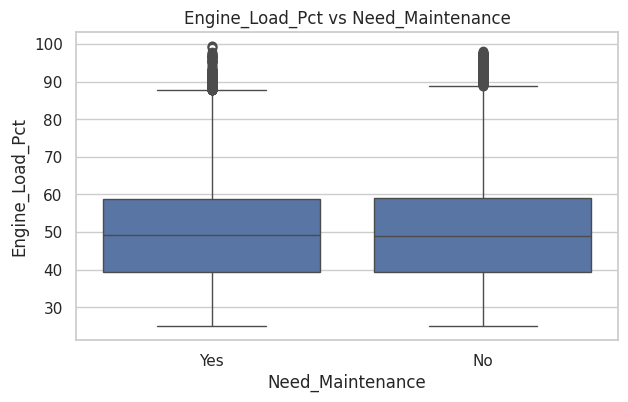

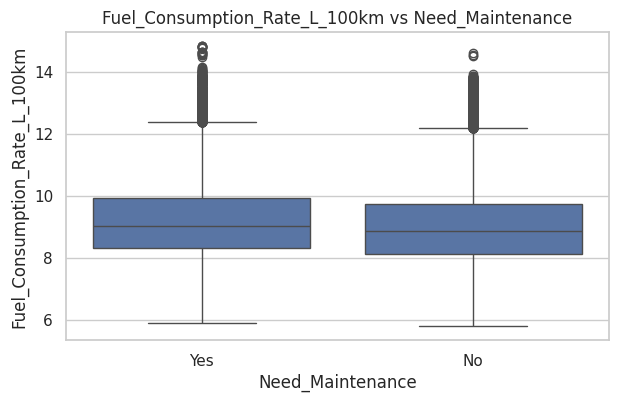

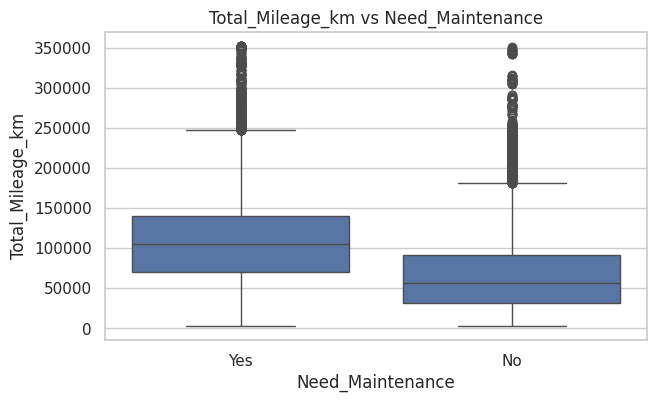

EDA OBSERVATIONS
• Target classes are nearly balanced.
• Multiple features contain missing values.
• No preprocessing has been performed.
• Correlation structure has been visualized.
• Outliers are present in several numerical features.
• Feature distributions have been explored.
• Dataset is ready for Stage 3 – Data Preprocessing.


In [64]:
# =============================================================================
# Stage 2 – Exploratory Data Analysis (EDA)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("="*80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 2 – Exploratory Data Analysis (EDA)")
print("="*80)

# =============================================================================
# 1. Target Variable Distribution
# =============================================================================

print("\n1. Need_Maintenance Distribution")

plt.figure(figsize=(6,4))
sns.countplot(data=vehicle_df, x="Need_Maintenance", palette="Set2")
plt.title("Need_Maintenance Distribution")
plt.xlabel("Need Maintenance")
plt.ylabel("Count")
plt.show()

print(vehicle_df["Need_Maintenance"].value_counts(normalize=True)*100)

# =============================================================================
# 2. Failure Type Distribution
# =============================================================================

print("\n2. Failure Type Distribution")

plt.figure(figsize=(10,5))
sns.countplot(
    data=vehicle_df,
    y="Failure_Type",
    order=vehicle_df["Failure_Type"].value_counts().index,
    palette="viridis"
)

plt.title("Failure Type Distribution")
plt.xlabel("Count")
plt.ylabel("Failure Type")
plt.show()

# =============================================================================
# 3. Remaining Useful Life Distribution
# =============================================================================

print("\n3. Remaining Useful Life Distribution")

plt.figure(figsize=(8,5))
sns.histplot(
    vehicle_df["Remaining_Useful_Life_km"],
    bins=40,
    kde=True
)

plt.title("Remaining Useful Life (km)")
plt.xlabel("Remaining Useful Life")
plt.show()

# =============================================================================
# 4. Missing Value Visualization
# =============================================================================

print("\n4. Missing Value Analysis")

missing = vehicle_df.isnull().mean()*100
missing = missing[missing>0].sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="Reds_r"
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")
plt.title("Missing Values")
plt.show()

# =============================================================================
# 5. Numerical Feature Distribution
# =============================================================================

print("\n5. Numerical Feature Distribution")

numeric_columns = vehicle_df.select_dtypes(
    include=["int64","float64"]
).columns

vehicle_df[numeric_columns].hist(
    figsize=(20,25),
    bins=30
)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Correlation Heatmap
# =============================================================================

print("\n6. Correlation Heatmap")

plt.figure(figsize=(18,15))

corr = vehicle_df[numeric_columns].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# =============================================================================
# 7. Outlier Analysis
# =============================================================================

print("\n7. Outlier Analysis")

important_features = [
    "Vehicle_Age_years",
    "Engine_Size_cc",
    "Fuel_Consumption_Rate_L_100km",
    "Engine_Load_Pct",
    "Total_Mileage_km",
    "Remaining_Useful_Life_km"
]

for feature in important_features:

    if feature in vehicle_df.columns:

        plt.figure(figsize=(7,3))

        sns.boxplot(
            x=vehicle_df[feature],
            color="skyblue"
        )

        plt.title(f"Boxplot : {feature}")
        plt.show()

# =============================================================================
# 8. Categorical Feature Distribution
# =============================================================================

print("\n8. Important Categorical Features")

categorical_features = [
    "Vehicle_Model",
    "Climate_Region",
    "Driving_Pattern",
    "Fuel_System_Material_Compatibility"
]

for feature in categorical_features:

    if feature in vehicle_df.columns:

        plt.figure(figsize=(8,4))

        sns.countplot(
            data=vehicle_df,
            x=feature,
            order=vehicle_df[feature].value_counts().index
        )

        plt.title(feature)
        plt.xticks(rotation=45)
        plt.show()

# =============================================================================
# 9. Relationship with Target
# =============================================================================

print("\n9. Important Features vs Need_Maintenance")

relationship_features = [
    "Vehicle_Age_years",
    "Engine_Load_Pct",
    "Fuel_Consumption_Rate_L_100km",
    "Total_Mileage_km"
]

for feature in relationship_features:

    if feature in vehicle_df.columns:

        plt.figure(figsize=(7,4))

        sns.boxplot(
            data=vehicle_df,
            x="Need_Maintenance",
            y=feature
        )

        plt.title(f"{feature} vs Need_Maintenance")
        plt.show()

# =============================================================================
# 10. EDA Summary
# =============================================================================

print("="*80)
print("EDA OBSERVATIONS")
print("="*80)

print("• Target classes are nearly balanced.")
print("• Multiple features contain missing values.")
print("• No preprocessing has been performed.")
print("• Correlation structure has been visualized.")
print("• Outliers are present in several numerical features.")
print("• Feature distributions have been explored.")
print("• Dataset is ready for Stage 3 – Data Preprocessing.")

Stage 3 Part 1

In [65]:
# =============================================================================
# Stage 3 – Data Preprocessing
# Part 1: Dataset copy, feature/target separation and common split
# =============================================================================

import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
PRIMARY_TARGET = "Need_Maintenance"

TARGET_COLUMNS = [
    "Need_Maintenance",
    "Failure_Type",
    "Remaining_Useful_Life_km"
]


SECONDARY_TARGETS = [
    "Failure_Type",
    "Remaining_Useful_Life_km"
]

IDENTIFIER_COLUMNS = ["Vehicle_ID", "Timestamp"]

# Reuse the DataFrame created by Stage 1.
if "vehicle_df" not in globals():
    raise NameError(
        "vehicle_df is not available. Run the dataset loading cell and Stage 1 first."
    )

if not isinstance(vehicle_df, pd.DataFrame):
    raise TypeError("vehicle_df must be a pandas DataFrame.")

if vehicle_df.empty:
    raise ValueError("vehicle_df is empty.")

if PRIMARY_TARGET not in vehicle_df.columns:
    raise ValueError(f"Required target '{PRIMARY_TARGET}' was not found.")

# Never modify the original Stage 1 DataFrame.
df_stage3 = vehicle_df.copy(deep=True)

# Remove only columns that are actually present.
columns_to_remove = [c for c in IDENTIFIER_COLUMNS if c in df_stage3.columns]

if not columns_to_remove:
    print("Warning: no configured identifier columns were found.")

df_stage3 = df_stage3.drop(columns=columns_to_remove)

# Validate target before creating X/y.
if df_stage3[PRIMARY_TARGET].isna().any():
    raise ValueError(
        f"Target '{PRIMARY_TARGET}' contains missing values. "
        "Target rows must be resolved before supervised learning."
    )

if df_stage3[PRIMARY_TARGET].nunique(dropna=True) < 2:
    raise ValueError(
        f"Target '{PRIMARY_TARGET}' contains fewer than two classes."
    )

FEATURE_DROP_COLUMNS = [
    PRIMARY_TARGET,
    *SECONDARY_TARGETS
]

# Remove all target columns from the feature matrix
X = df_stage3.drop(columns=TARGET_COLUMNS).copy()

# Keep only the primary target
y_raw = df_stage3[PRIMARY_TARGET].copy()
if X.empty:
    raise ValueError(
        "No predictor features remain after removing target columns."
    )

# Encode the binary target once and reuse the same encoding for every model.
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

target_classes = target_encoder.classes_.tolist()
target_mapping = {
    str(label): int(code)
    for label, code in zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))
}

print("=" * 80)
print("STAGE 3 – PART 1")
print("=" * 80)
print(f"Working dataset shape : {df_stage3.shape}")
print(f"Feature matrix shape  : {X.shape}")
print(f"Target classes        : {target_classes}")
print(f"Target mapping        : {target_mapping}")
print(f"Removed columns       : {columns_to_remove}")

# One split is used by RF, XGBoost and CatBoost for a fair comparison.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Reset indexes so the two preprocessing paths remain easy to compare.
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print("\nTrain/Test split")
print(f"X_train_raw : {X_train_raw.shape}")
print(f"X_test_raw  : {X_test_raw.shape}")
print(f"y_train     : {y_train.shape}")
print(f"y_test      : {y_test.shape}")

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().mul(100).round(2))

STAGE 3 – PART 1
Working dataset shape : (120000, 54)
Feature matrix shape  : (120000, 51)
Target classes        : ['No', 'Yes']
Target mapping        : {'No': 0, 'Yes': 1}
Removed columns       : ['Vehicle_ID', 'Timestamp']

Train/Test split
X_train_raw : (96000, 51)
X_test_raw  : (24000, 51)
y_train     : (96000,)
y_test      : (24000,)

Training class distribution:
0    50.69
1    49.31
Name: proportion, dtype: float64

Testing class distribution:
0    50.7
1    49.3
Name: proportion, dtype: float64


In [66]:
# =============================================================================
# Stage 3 – Part 2: Feature-type detection and reusable preprocessing definitions
# =============================================================================

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Validate that train/test schemas match exactly before preprocessing.
if list(X_train_raw.columns) != list(X_test_raw.columns):
    raise ValueError("Training and testing feature columns do not match.")

# Detect feature types from the training split only.
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_raw.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

unsupported_features = [
    c for c in X_train_raw.columns
    if c not in numeric_features and c not in categorical_features
]

if unsupported_features:
    raise TypeError(
        "Unsupported feature dtype(s) detected: "
        f"{unsupported_features}"
    )

if not numeric_features and not categorical_features:
    raise ValueError("No usable numeric or categorical features were detected.")

print("=" * 80)
print("STAGE 3 – PART 2")
print("=" * 80)
print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")

missing_train = X_train_raw.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print(f"\nTraining missing values before preprocessing: {int(X_train_raw.isna().sum().sum()):,}")

if not missing_train.empty:
    display(
        pd.DataFrame({
            "Missing Count": missing_train,
            "Missing Percentage": (
                missing_train / len(X_train_raw) * 100
            ).round(2)
        })
    )
else:
    print("No missing values in the training split.")

# Reusable imputers. They are fitted later through Pipeline/ColumnTransformer.
numeric_imputer = SimpleImputer(strategy="median")

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

catboost_categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="__MISSING__"
)

catboost_numeric_imputer = SimpleImputer(strategy="median")

print("\nReusable imputation definitions created successfully.")
# =============================================================================
# Fit imputers ONLY on training data
# =============================================================================

numeric_imputer.fit(
    X_train_raw[numeric_features]
)

categorical_imputer.fit(
    X_train_raw[categorical_features]
)

print("Imputers fitted successfully.")

STAGE 3 – PART 2
Numeric features     : 44
Categorical features : 7

Training missing values before preprocessing: 125,125


,Missing Count,Missing Percentage
Compression_Ratio_Change_Pct,9772,10.18
Fuel_Water_Contamination_ppm,8791,9.16
O2_Sensor_Response_ms,7691,8.01
Altitude_m,5720,5.96
Avg_Trip_Length_km,4899,5.10
Harsh_Event_Count_per_trip,4830,5.03
Fuel_Vapor_Pressure_Class,4697,4.89
Humidity_Pct,3835,3.99
Misfire_Count_per_1000rev,3010,3.14
Fuel_System_Corrosion_Score,2915,3.04



Reusable imputation definitions created successfully.
Imputers fitted successfully.


In [67]:
# =============================================================================
# Stage 3 – Part 3: Random Forest / XGBoost preprocessing
# =============================================================================

from sklearn.preprocessing import OneHotEncoder

# Use sparse output to reduce memory usage where supported.
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    # Compatibility fallback for older scikit-learn versions.
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

rf_xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# IMPORTANT: fit only on X_train_raw.
rf_xgb_preprocessor.fit(X_train_raw)

X_train_rf_xgb = rf_xgb_preprocessor.transform(X_train_raw)
X_test_rf_xgb = rf_xgb_preprocessor.transform(X_test_raw)

if X_train_rf_xgb.shape[0] != len(y_train):
    raise ValueError("RF/XGBoost training feature rows do not match y_train.")

if X_test_rf_xgb.shape[0] != len(y_test):
    raise ValueError("RF/XGBoost testing feature rows do not match y_test.")

if X_train_rf_xgb.shape[1] == 0:
    raise ValueError("RF/XGBoost preprocessing produced zero features.")

rf_xgb_feature_names = rf_xgb_preprocessor.get_feature_names_out().tolist()

if len(rf_xgb_feature_names) != X_train_rf_xgb.shape[1]:
    raise ValueError("Processed feature-name count does not match matrix width.")

print("=" * 80)
print("STAGE 3 – PART 3")
print("=" * 80)
print(f"RF/XGBoost train shape : {X_train_rf_xgb.shape}")
print(f"RF/XGBoost test shape  : {X_test_rf_xgb.shape}")
print(f"Processed feature count: {len(rf_xgb_feature_names)}")
print(f"Output type            : {type(X_train_rf_xgb).__name__}")

print("\nFirst 15 processed feature names:")
print(rf_xgb_feature_names[:15])

# Build a compact metadata object for later stages.
rf_xgb_metadata = {
    "pipeline_name": "RandomForest_XGBoost",
    "target": PRIMARY_TARGET,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "processed_feature_names": rf_xgb_feature_names,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE
}

print("\nRF/XGBoost preprocessing completed successfully.")


STAGE 3 – PART 3
RF/XGBoost train shape : (96000, 66)
RF/XGBoost test shape  : (24000, 66)
Processed feature count: 66
Output type            : csr_matrix

First 15 processed feature names:
['numeric__Vehicle_Age_years', 'numeric__Engine_Size_cc', 'numeric__Ambient_Temperature_C', 'numeric__Humidity_Pct', 'numeric__Altitude_m', 'numeric__Ethanol_Content_Pct', 'numeric__Fuel_Consumption_Rate_L_100km', 'numeric__Fuel_Rail_Pressure_kPa', 'numeric__Injector_Duty_Cycle_Pct', 'numeric__Fuel_Water_Contamination_ppm', 'numeric__LTFT_Pct', 'numeric__STFT_Pct', 'numeric__Oil_Pressure_psi', 'numeric__Oil_Temperature_C', 'numeric__Coolant_Temperature_C']

RF/XGBoost preprocessing completed successfully.


In [68]:
# =============================================================================
# Stage 3 – Data Preprocessing
# Part 4 – CatBoost Native Categorical Preprocessing
# =============================================================================

print("=" * 80)
print("STAGE 3 – PART 4")
print("=" * 80)

# =============================================================================
# Validation
# =============================================================================

required_variables = [
    "X_train_raw",
    "X_test_raw",
    "y_train",
    "y_test",
    "numeric_features",
    "categorical_features",
    "numeric_imputer",
    "categorical_imputer"
]

for variable in required_variables:
    if variable not in globals():
        raise NameError(f"{variable} not found. Run previous Stage 3 parts first.")

# =============================================================================
# Create CatBoost datasets
# =============================================================================

X_train_catboost = X_train_raw.copy()
X_test_catboost = X_test_raw.copy()

# =============================================================================
# Apply fitted imputers
# =============================================================================

X_train_catboost[numeric_features] = numeric_imputer.transform(
    X_train_catboost[numeric_features]
)

X_test_catboost[numeric_features] = numeric_imputer.transform(
    X_test_catboost[numeric_features]
)

X_train_catboost[categorical_features] = categorical_imputer.transform(
    X_train_catboost[categorical_features]
)

X_test_catboost[categorical_features] = categorical_imputer.transform(
    X_test_catboost[categorical_features]
)

# =============================================================================
# Preserve categorical columns as strings
# =============================================================================

for col in categorical_features:

    X_train_catboost[col] = (
        X_train_catboost[col]
        .astype(str)
        .fillna("Missing")
    )

    X_test_catboost[col] = (
        X_test_catboost[col]
        .astype(str)
        .fillna("Missing")
    )

# =============================================================================
# Final Missing Value Check
# =============================================================================

if X_train_catboost.isnull().sum().sum() != 0:
    raise ValueError("Training dataset still contains missing values.")

if X_test_catboost.isnull().sum().sum() != 0:
    raise ValueError("Testing dataset still contains missing values.")

# =============================================================================
# CatBoost Metadata
# =============================================================================

# All feature names
catboost_feature_names = X_train_catboost.columns.tolist()

# Categorical feature names
catboost_categorical_feature_names = categorical_features.copy()

# Categorical feature indices
catboost_cat_features = [
    X_train_catboost.columns.get_loc(col)
    for col in catboost_categorical_feature_names
]

# Alias used in later stages
catboost_feature_indices = catboost_cat_features.copy()

# =============================================================================
# Validation
# =============================================================================

if X_train_catboost.shape[0] != len(y_train):
    raise ValueError("CatBoost training rows do not match y_train.")

if X_test_catboost.shape[0] != len(y_test):
    raise ValueError("CatBoost testing rows do not match y_test.")

if list(X_train_catboost.columns) != list(X_test_catboost.columns):
    raise ValueError("CatBoost train/test feature schemas differ.")

# =============================================================================
# Summary
# =============================================================================

print(f"CatBoost train shape      : {X_train_catboost.shape}")
print(f"CatBoost test shape       : {X_test_catboost.shape}")

print(f"Categorical feature count : {len(catboost_categorical_feature_names)}")

print("Categorical feature names :", catboost_categorical_feature_names)

print("Categorical feature index :", catboost_cat_features)

print("\nCatBoost data types:")
display(X_train_catboost.dtypes.to_frame("dtype"))

print("\nCatBoost preprocessing completed successfully.")

STAGE 3 – PART 4
CatBoost train shape      : (96000, 51)
CatBoost test shape       : (24000, 51)
Categorical feature count : 7
Categorical feature names : ['Vehicle_Model', 'Fuel_System_Material_Compatibility', 'Climate_Region', 'Fuel_Vapor_Pressure_Class', 'Towing_Flag', 'Driving_Pattern', 'Fuel_Line_Seal_Condition']
Categorical feature index : [0, 3, 4, 9, 32, 33, 44]

CatBoost data types:


,dtype
Vehicle_Model,object
Vehicle_Age_years,float64
Engine_Size_cc,float64
Fuel_System_Material_Compatibility,object
Climate_Region,object
Ambient_Temperature_C,float64
Humidity_Pct,float64
Altitude_m,float64
Ethanol_Content_Pct,float64
Fuel_Vapor_Pressure_Class,object



CatBoost preprocessing completed successfully.


In [69]:
# =============================================================================
# Stage 3 – Part 5: Save reusable preprocessing artifacts
# =============================================================================

# Google Drive project directory.
PROJECT_DIR = Path("/content/drive/MyDrive/Btech Final Year Project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

# Create the artifact directory if Google Drive is mounted.
try:
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
except OSError as exc:
    raise OSError(
        f"Could not create artifact directory: {ARTIFACT_DIR}. "
        "Make sure Google Drive is mounted and writable."
    ) from exc

# Verify that the directory is writable.
if not os.access(ARTIFACT_DIR, os.W_OK):
    raise PermissionError(f"Artifact directory is not writable: {ARTIFACT_DIR}")

RF_XGB_PREPROCESSOR_PATH = ARTIFACT_DIR / "rf_xgb_preprocessor.joblib"
CATBOOST_PREPROCESSOR_PATH = ARTIFACT_DIR / "catboost_preprocessor.joblib"
PREPROCESSING_METADATA_PATH = ARTIFACT_DIR / "preprocessing_metadata.joblib"

# Save the fitted RF/XGBoost ColumnTransformer.
joblib.dump(
    rf_xgb_preprocessor,
    RF_XGB_PREPROCESSOR_PATH
)

# Save CatBoost imputers and categorical metadata.
catboost_artifacts = {
    "numeric_imputer": numeric_imputer,
    "categorical_imputer": categorical_imputer,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "catboost_feature_names": catboost_feature_names,
    "catboost_categorical_feature_names": catboost_categorical_feature_names,
    "catboost_cat_features": catboost_cat_features,
    "catboost_feature_indices": catboost_feature_indices
}

joblib.dump(
    catboost_artifacts,
    CATBOOST_PREPROCESSOR_PATH
)

# Save common project metadata.
preprocessing_metadata = {
    "project_stage": "Stage 3 – Data Preprocessing",
    "primary_target": PRIMARY_TARGET,
    "target_classes": target_classes,
    "target_mapping": target_mapping,
    "identifier_columns_removed": columns_to_remove,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "rf_xgb_feature_names": rf_xgb_feature_names,
    "catboost_feature_names": catboost_feature_names,
    "catboost_feature_indices": catboost_feature_indices,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "train_shape_raw": tuple(X_train_raw.shape),
    "test_shape_raw": tuple(X_test_raw.shape),
    "train_shape_rf_xgb": tuple(X_train_rf_xgb.shape),
    "test_shape_rf_xgb": tuple(X_test_rf_xgb.shape),
    "train_shape_catboost": tuple(X_train_catboost.shape),
    "test_shape_catboost": tuple(X_test_catboost.shape)
}

joblib.dump(
    preprocessing_metadata,
    PREPROCESSING_METADATA_PATH
)

# Save a small JSON metadata file for easy inspection outside Python.
metadata_json = {
    key: value
    for key, value in preprocessing_metadata.items()
    if isinstance(value, (str, int, float, bool, list, tuple))
}

with open(ARTIFACT_DIR / "preprocessing_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata_json, f, indent=2, default=list)

print("=" * 80)
print("PREPROCESSING ARTIFACTS SAVED")
print("=" * 80)

for path in [
    RF_XGB_PREPROCESSOR_PATH,
    CATBOOST_PREPROCESSOR_PATH,
    PREPROCESSING_METADATA_PATH,
    ARTIFACT_DIR / "preprocessing_metadata.json"
]:
    print(f"✓ {path}")


PREPROCESSING ARTIFACTS SAVED
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/rf_xgb_preprocessor.joblib
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/catboost_preprocessor.joblib
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/preprocessing_metadata.joblib
✓ /content/drive/MyDrive/Btech Final Year Project/artifacts/preprocessing_metadata.json


In [70]:
# =============================================================================
# Stage 4 – Machine Learning Models
# Part 1 – Random Forest Classifier
# FAST OPTIMIZED VERSION
# =============================================================================

import time
import joblib
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 4 – Part 1 : Random Forest FAST VERSION")
print("=" * 80)

# =============================================================================
# 1. VALIDATION
# =============================================================================

required_variables = [
    "X_train_rf_xgb",
    "X_test_rf_xgb",
    "y_train",
    "y_test",
    "rf_xgb_feature_names"
]

for variable in required_variables:
    if variable not in globals():
        raise NameError(
            f"{variable} not found. Please run Stage 3 first."
        )

print("\nInput validation passed.")

print(f"Training shape : {X_train_rf_xgb.shape}")
print(f"Testing shape  : {X_test_rf_xgb.shape}")
print(f"Feature count  : {len(rf_xgb_feature_names)}")

# =============================================================================
# 2. RANDOM FOREST MODEL
# =============================================================================
#
# Compared with your previous model:
#
# Previous:
# n_estimators = 150
# max_depth    = 20
#
# This version:
# n_estimators = 100
# max_depth    = 20
#
# Keeping depth at 20 is important because your depth-15 model
# dropped significantly in accuracy.
#
# =============================================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

print("\nRandom Forest configuration:")
print(rf_model)

# =============================================================================
# 3. TRAINING
# =============================================================================

print("\nTraining Random Forest...")

start_time = time.time()

rf_model.fit(
    X_train_rf_xgb,
    y_train
)

training_time = time.time() - start_time

print(
    f"Training completed in "
    f"{training_time:.2f} seconds."
)

# =============================================================================
# 4. PREDICTION
# =============================================================================

print("\nGenerating predictions...")

start_time = time.time()

y_pred_rf = rf_model.predict(
    X_test_rf_xgb
)

y_prob_rf = rf_model.predict_proba(
    X_test_rf_xgb
)[:, 1]

prediction_time = time.time() - start_time

# =============================================================================
# 5. METRICS
# =============================================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# =============================================================================
# 6. PERFORMANCE
# =============================================================================

print("\n" + "=" * 80)
print("RANDOM FOREST PERFORMANCE")
print("=" * 80)

print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Precision       : {rf_precision:.4f}")
print(f"Recall          : {rf_recall:.4f}")
print(f"F1 Score        : {rf_f1:.4f}")
print(f"ROC-AUC         : {rf_auc:.4f}")

print(f"\nTraining Time   : {training_time:.2f} sec")
print(f"Prediction Time : {prediction_time:.2f} sec")

# =============================================================================
# 7. CLASSIFICATION REPORT
# =============================================================================

print("\nClassification Report")
print("-" * 80)

print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4,
        zero_division=0
    )
)

# =============================================================================
# 8. FEATURE IMPORTANCE
# =============================================================================

feature_importance = pd.DataFrame({

    "Feature":
        rf_xgb_feature_names,

    "Importance":
        rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 Important Features")
print("-" * 80)

display(
    feature_importance.head(20)
)

# =============================================================================
# 9. SAVE FEATURE IMPORTANCE
# =============================================================================

feature_importance_path = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/"
    "artifacts/random_forest_feature_importance.joblib"
)

joblib.dump(
    feature_importance,
    feature_importance_path
)

# =============================================================================
# 10. SAVE MODEL
# =============================================================================

rf_model_path = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/"
    "artifacts/random_forest_model.joblib"
)

joblib.dump(
    rf_model,
    rf_model_path
)

print("\nRandom Forest model saved to:")
print(rf_model_path)

# =============================================================================
# 11. STORE RESULTS
# =============================================================================

rf_results = {

    "Model":
        "Random Forest",

    "Accuracy":
        rf_accuracy,

    "Precision":
        rf_precision,

    "Recall":
        rf_recall,

    "F1 Score":
        rf_f1,

    "ROC-AUC":
        rf_auc,

    "Training Time":
        training_time,

    "Prediction Time":
        prediction_time,

    "Parameters":
        rf_model.get_params()
}

rf_results_path = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/"
    "artifacts/random_forest_results.joblib"
)

joblib.dump(
    rf_results,
    rf_results_path
)

print("\nRandom Forest results saved to:")
print(rf_results_path)

# =============================================================================
# 12. FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 4 PART 1 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Random Forest trained")
print("✓ Test predictions generated")
print("✓ Accuracy calculated")
print("✓ Precision calculated")
print("✓ Recall calculated")
print("✓ F1 Score calculated")
print("✓ ROC-AUC calculated")
print("✓ Feature importance calculated")
print("✓ Model saved")
print("✓ Results saved")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 4 – Part 1 : Random Forest FAST VERSION

Input validation passed.
Training shape : (96000, 66)
Testing shape  : (24000, 66)
Feature count  : 66

Random Forest configuration:
RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_jobs=-1, random_state=42)

Training Random Forest...
Training completed in 249.08 seconds.

Generating predictions...

RANDOM FOREST PERFORMANCE
Accuracy        : 0.9795
Precision       : 0.9878
Recall          : 0.9705
F1 Score        : 0.9791
ROC-AUC         : 0.9984

Training Time   : 249.08 sec
Prediction Time : 1.63 sec

Classification Report
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9718    0.9883    0.9800     12167
           1     0.9878    0.9705    0.9791     11833

    accuracy                         0.9795     24000
   macro avg     0.9798    0.9794 

,Feature,Importance
0,numeric__Catalytic_Converter_Efficiency_Pct,0.046377
1,numeric__Total_Mileage_km,0.042190
2,numeric__Vibration_Level_mm_s,0.034964
3,numeric__Oil_Pressure_psi,0.030630
4,numeric__Misfire_Count_per_1000rev,0.029785
5,numeric__Vehicle_Age_years,0.028839
6,numeric__Injector_Flow_Drift_Pct,0.026712
7,numeric__Compression_Ratio_Change_Pct,0.025577
8,numeric__Fuel_Pump_Pressure_Decay_kPa_min,0.024577
9,numeric__Time_Since_Last_Service_days,0.024085



Random Forest model saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/random_forest_model.joblib

Random Forest results saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/random_forest_results.joblib

STAGE 4 PART 1 COMPLETED SUCCESSFULLY
✓ Random Forest trained
✓ Test predictions generated
✓ Accuracy calculated
✓ Precision calculated
✓ Recall calculated
✓ F1 Score calculated
✓ ROC-AUC calculated
✓ Feature importance calculated
✓ Model saved
✓ Results saved


SMART VEHICLE HEALTH INTELLIGENCE
Stage 4 – Part 2 : XGBoost

Training XGBoost...
Training completed in 40.73 seconds.

XGBOOST PERFORMANCE
Accuracy        : 0.7993
Precision       : 0.8046
Recall          : 0.7831
F1 Score        : 0.7937
ROC-AUC         : 0.8951

Training Time   : 40.73 sec
Prediction Time : 0.39 sec

Classification Report

              precision    recall  f1-score   support

           0     0.7944    0.8151    0.8046     12167
           1     0.8046    0.7831    0.7937     11833

    accuracy                         0.7993     24000
   macro avg     0.7995    0.7991    0.7991     24000
weighted avg     0.7994    0.7993    0.7992     24000



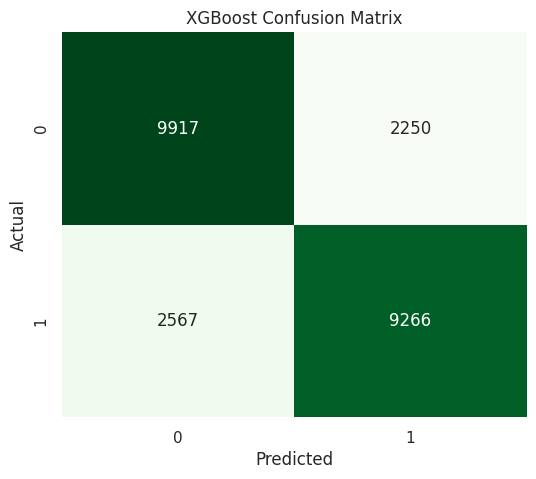


Top 20 Important Features


,Feature,Importance
48,categorical__Fuel_System_Material_Compatibilit...,0.731302
0,numeric__Vehicle_Age_years,0.050410
36,numeric__Catalytic_Converter_Efficiency_Pct,0.027475
24,numeric__Total_Mileage_km,0.013122
32,numeric__Misfire_Count_per_1000rev,0.005295
37,numeric__Fuel_System_Corrosion_Score,0.004947
31,numeric__Injector_Flow_Drift_Pct,0.004835
12,numeric__Oil_Pressure_psi,0.004193
41,numeric__Time_Since_Last_Service_days,0.003835
61,categorical__Driving_Pattern_Highway,0.003783


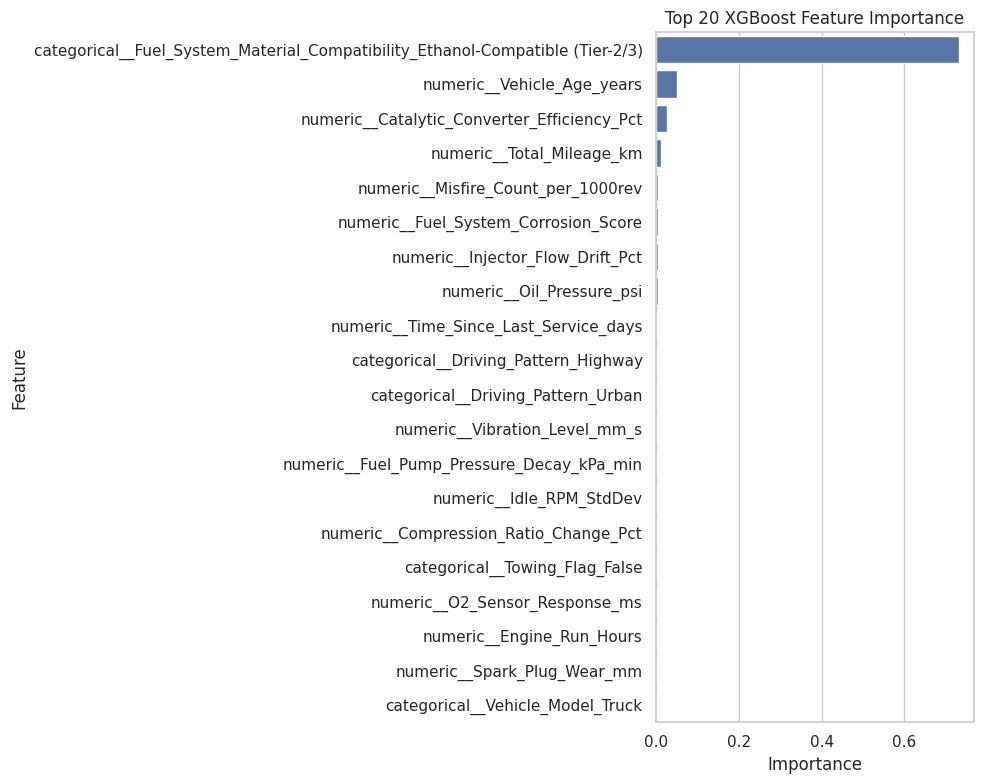


XGBoost model saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/xgboost_model.joblib

XGBoost results stored successfully.

Stage 4 Part 2 completed successfully.


In [71]:
# =============================================================================
# Stage 4 – Machine Learning Models
# Part 2 – XGBoost Classifier
# =============================================================================

import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 4 – Part 2 : XGBoost")
print("=" * 80)

# =============================================================================
# Validation
# =============================================================================

required_variables = [
    "X_train_rf_xgb",
    "X_test_rf_xgb",
    "y_train",
    "y_test",
    "rf_xgb_feature_names"
]

for variable in required_variables:
    if variable not in globals():
        raise NameError(f"{variable} not found. Please run Stage 3 first.")

# =============================================================================
# Build XGBoost Model
# =============================================================================

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    enable_categorical=False
)

# =============================================================================
# Model Training
# =============================================================================

print("\nTraining XGBoost...")

start_time = time.time()

xgb_model.fit(
    X_train_rf_xgb,
    y_train
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds.")

# =============================================================================
# Prediction
# =============================================================================

start_time = time.time()

y_pred_xgb = xgb_model.predict(X_test_rf_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test_rf_xgb)[:, 1]

prediction_time = time.time() - start_time

# =============================================================================
# Evaluation Metrics
# =============================================================================

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(y_test, y_pred_xgb)

xgb_recall = recall_score(y_test, y_pred_xgb)

xgb_f1 = f1_score(y_test, y_pred_xgb)

xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("\n" + "=" * 80)
print("XGBOOST PERFORMANCE")
print("=" * 80)

print(f"Accuracy        : {xgb_accuracy:.4f}")
print(f"Precision       : {xgb_precision:.4f}")
print(f"Recall          : {xgb_recall:.4f}")
print(f"F1 Score        : {xgb_f1:.4f}")
print(f"ROC-AUC         : {xgb_auc:.4f}")

print(f"\nTraining Time   : {training_time:.2f} sec")
print(f"Prediction Time : {prediction_time:.2f} sec")

# =============================================================================
# Classification Report
# =============================================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        digits=4
    )
)

# =============================================================================
# Confusion Matrix
# =============================================================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =============================================================================
# Feature Importance
# =============================================================================

feature_importance = pd.DataFrame({
    "Feature": rf_xgb_feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features")

display(feature_importance.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 XGBoost Feature Importance")

plt.tight_layout()

plt.show()

# =============================================================================
# Save Model
# =============================================================================

xgb_model_path = "/content/drive/MyDrive/Btech Final Year Project/artifacts/xgboost_model.joblib"

joblib.dump(
    xgb_model,
    xgb_model_path
)

print(f"\nXGBoost model saved to:\n{xgb_model_path}")

# =============================================================================
# Store Results for Model Comparison
# =============================================================================

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_auc,
    "Training Time": training_time,
    "Prediction Time": prediction_time
}

print("\nXGBoost results stored successfully.")

print("\nStage 4 Part 2 completed successfully.")

In [72]:
# Install CatBoost
!pip install -q catboost

SMART VEHICLE HEALTH INTELLIGENCE
Stage 4 – Part 3 : CatBoost

Training CatBoost...
Training completed in 85.65 seconds.

CATBOOST PERFORMANCE
Accuracy        : 0.7300
Precision       : 0.7308
Recall          : 0.7164
F1 Score        : 0.7235
ROC-AUC         : 0.8144

Training Time   : 85.65 sec
Prediction Time : 0.14 sec

Classification Report

              precision    recall  f1-score   support

           0     0.7294    0.7433    0.7363     12167
           1     0.7308    0.7164    0.7235     11833

    accuracy                         0.7300     24000
   macro avg     0.7301    0.7299    0.7299     24000
weighted avg     0.7301    0.7300    0.7300     24000



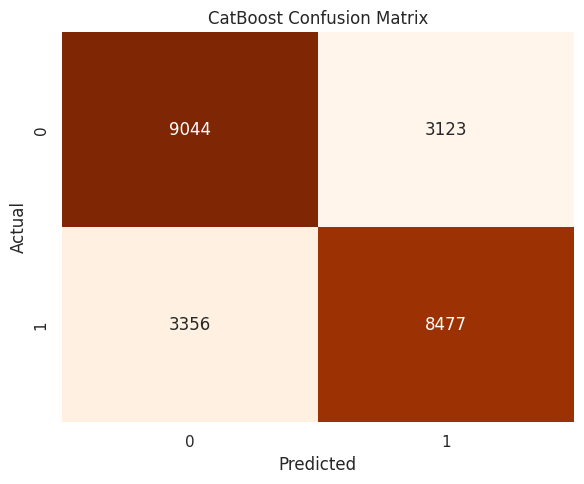


Top 20 Important Features


,Feature,Importance
48,Time_Since_Last_Service_days,5.275539
18,Coolant_Temperature_C,3.992704
37,Injector_Flow_Drift_Pct,3.891072
16,Oil_Pressure_psi,3.406878
43,Fuel_System_Corrosion_Score,3.210307
42,Catalytic_Converter_Efficiency_Pct,3.192580
46,Cold_Start_Duration_s,3.011640
39,Spark_Plug_Wear_mm,2.966011
5,Ambient_Temperature_C,2.809239
31,Avg_Load_Pct,2.771893


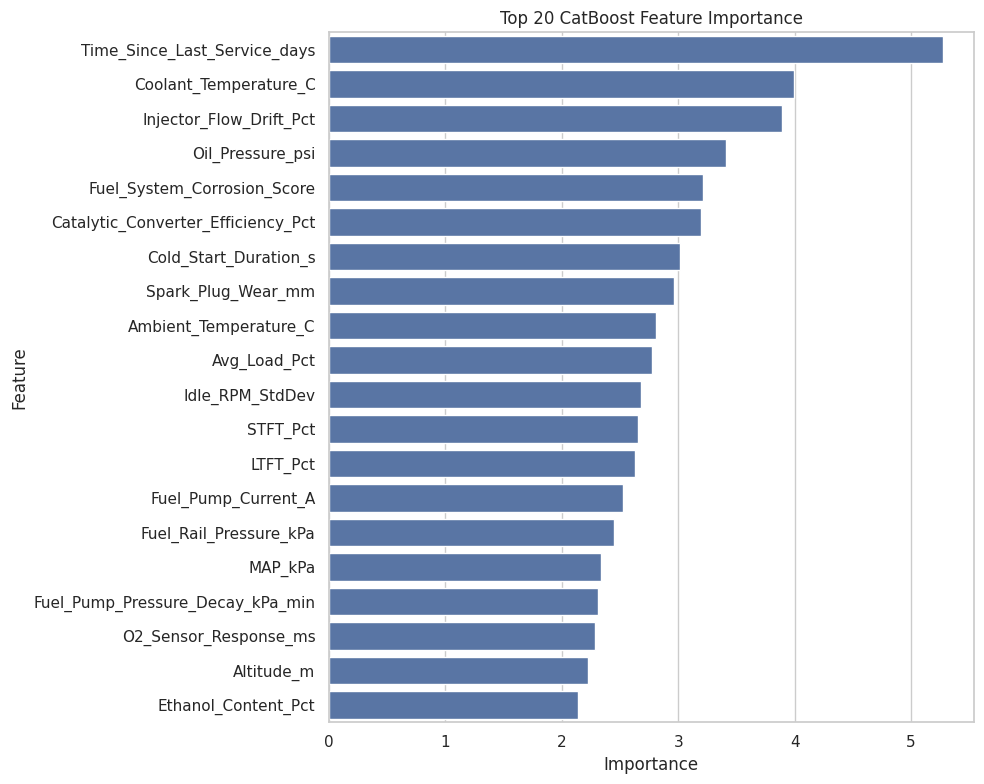


CatBoost model saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/catboost_model.joblib

CatBoost results stored successfully.

Stage 4 Part 3 completed successfully.


In [73]:
# =============================================================================
# Stage 4 – Machine Learning Models
# Part 3 – CatBoost Classifier
# =============================================================================

import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 4 – Part 3 : CatBoost")
print("=" * 80)

# =============================================================================
# Validation
# =============================================================================

required_variables = [
    "X_train_catboost",
    "X_test_catboost",
    "y_train",
    "y_test",
    "catboost_feature_names",
    "catboost_cat_features"
]

for variable in required_variables:
    if variable not in globals():
        raise NameError(f"{variable} not found. Please run Stage 3 first.")

# =============================================================================
# Build CatBoost Model
# =============================================================================

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

# =============================================================================
# Model Training
# =============================================================================

print("\nTraining CatBoost...")

start_time = time.time()

cat_model.fit(
    X_train_catboost,
    y_train,
    cat_features=catboost_cat_features
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds.")

# =============================================================================
# Prediction
# =============================================================================

start_time = time.time()

y_pred_cat = cat_model.predict(X_test_catboost)

y_prob_cat = cat_model.predict_proba(X_test_catboost)[:, 1]

prediction_time = time.time() - start_time

# Ensure predictions are integer labels
y_pred_cat = y_pred_cat.astype(int)

# =============================================================================
# Evaluation Metrics
# =============================================================================

cat_accuracy = accuracy_score(y_test, y_pred_cat)

cat_precision = precision_score(y_test, y_pred_cat)

cat_recall = recall_score(y_test, y_pred_cat)

cat_f1 = f1_score(y_test, y_pred_cat)

cat_auc = roc_auc_score(y_test, y_prob_cat)

print("\n" + "=" * 80)
print("CATBOOST PERFORMANCE")
print("=" * 80)

print(f"Accuracy        : {cat_accuracy:.4f}")
print(f"Precision       : {cat_precision:.4f}")
print(f"Recall          : {cat_recall:.4f}")
print(f"F1 Score        : {cat_f1:.4f}")
print(f"ROC-AUC         : {cat_auc:.4f}")

print(f"\nTraining Time   : {training_time:.2f} sec")
print(f"Prediction Time : {prediction_time:.2f} sec")

# =============================================================================
# Classification Report
# =============================================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_cat,
        digits=4
    )
)

# =============================================================================
# Confusion Matrix
# =============================================================================

cm = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False
)

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# =============================================================================
# Feature Importance
# =============================================================================

feature_importance = pd.DataFrame({
    "Feature": catboost_feature_names,
    "Importance": cat_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features")

display(feature_importance.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 CatBoost Feature Importance")

plt.tight_layout()
plt.show()

# =============================================================================
# Save Model
# =============================================================================

cat_model_path = "/content/drive/MyDrive/Btech Final Year Project/artifacts/catboost_model.joblib"

joblib.dump(
    cat_model,
    cat_model_path
)

print(f"\nCatBoost model saved to:\n{cat_model_path}")

# =============================================================================
# Store Results for Model Comparison
# =============================================================================

cat_results = {
    "Model": "CatBoost",
    "Accuracy": cat_accuracy,
    "Precision": cat_precision,
    "Recall": cat_recall,
    "F1 Score": cat_f1,
    "ROC-AUC": cat_auc,
    "Training Time": training_time,
    "Prediction Time": prediction_time
}

print("\nCatBoost results stored successfully.")

print("\nStage 4 Part 3 completed successfully.")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 4 – Part 4 : Model Comparison

Model Comparison Table



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time,Parameters
0,Random Forest,0.9795,0.9878,0.9705,0.9791,0.9984,249.0837,1.6273,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
1,XGBoost,0.7993,0.8046,0.7831,0.7937,0.8951,40.7343,0.3927,NaN
2,CatBoost,0.7300,0.7308,0.7164,0.7235,0.8144,85.6492,0.1441,NaN



Models Ranked by ROC-AUC



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time,Parameters
0,Random Forest,0.9795,0.9878,0.9705,0.9791,0.9984,249.0837,1.6273,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
1,XGBoost,0.7993,0.8046,0.7831,0.7937,0.8951,40.7343,0.3927,NaN
2,CatBoost,0.7300,0.7308,0.7164,0.7235,0.8144,85.6492,0.1441,NaN


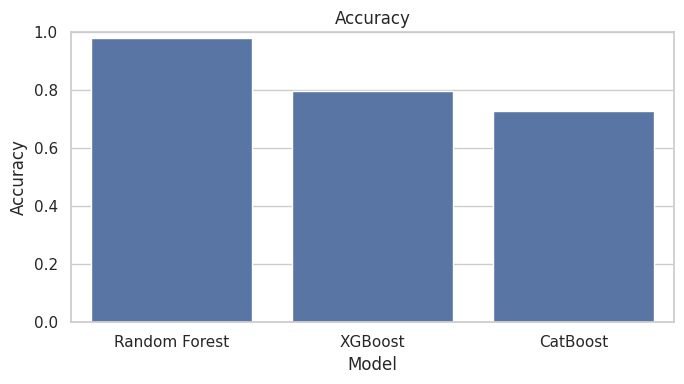

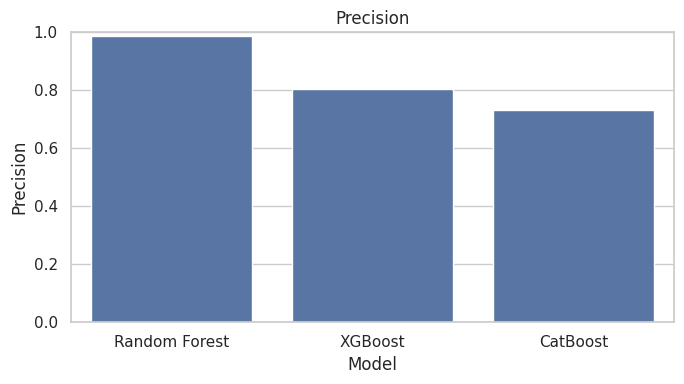

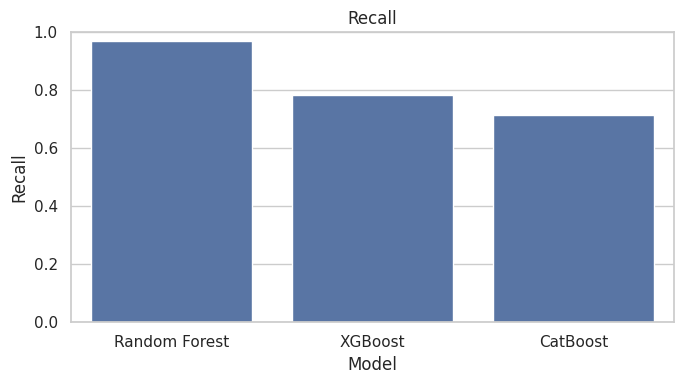

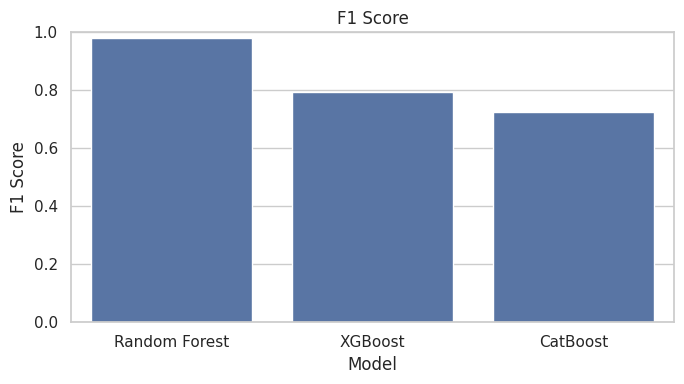

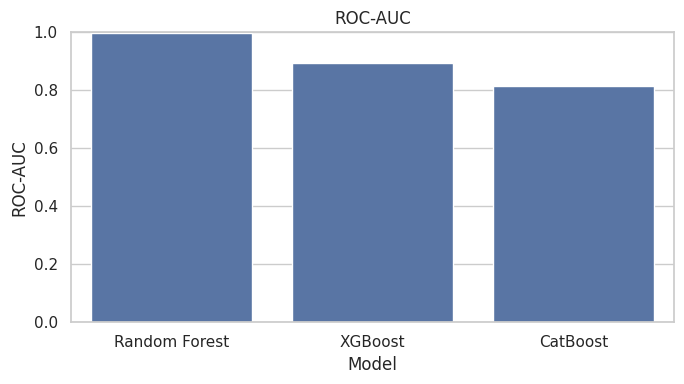

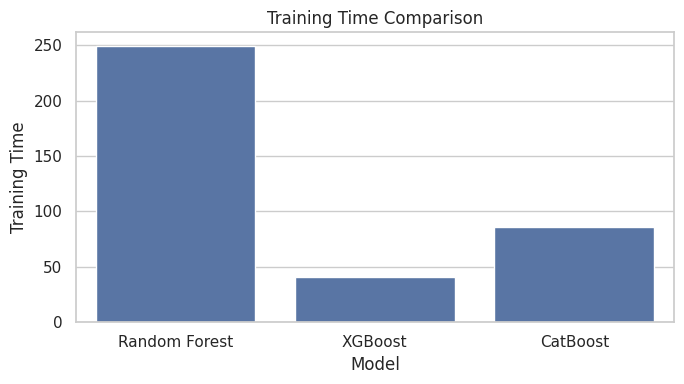

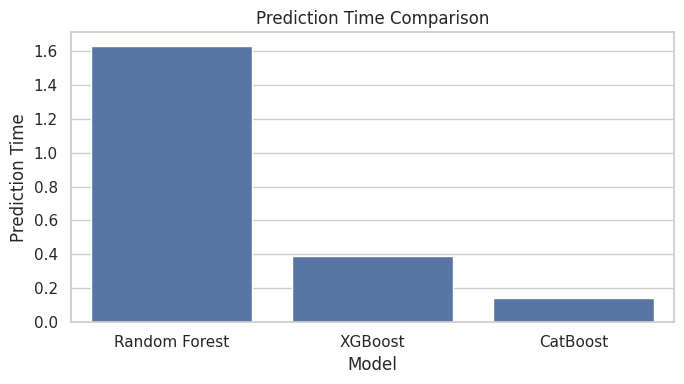


BEST MODEL
Best Model : Random Forest
ROC-AUC    : 0.9984

OBSERVATIONS
• All models were evaluated using the same train-test split.
• The same evaluation metrics were used for all models.
• Model comparison completed successfully.
• The best-performing model has been identified.
• Results are ready for Stage 5 (Hyperparameter Tuning).


In [74]:
# =============================================================================
# Stage 4 – Machine Learning Models
# Part 4 – Model Comparison
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 4 – Part 4 : Model Comparison")
print("=" * 80)

# =============================================================================
# Validation
# =============================================================================

required_variables = [
    "rf_results",
    "xgb_results",
    "cat_results",
    "rf_model",
    "xgb_model",
    "cat_model"
]

for variable in required_variables:
    if variable not in globals():
        raise NameError(
            f"{variable} not found. Please run all Stage 4 model parts first."
        )

# =============================================================================
# Create Comparison Table
# =============================================================================

comparison_df = pd.DataFrame([
    rf_results,
    xgb_results,
    cat_results
])

comparison_df = comparison_df.round(4)

print("\nModel Comparison Table\n")

display(comparison_df)

# =============================================================================
# Sort by ROC-AUC (Primary Metric)
# =============================================================================

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\nModels Ranked by ROC-AUC\n")

display(comparison_df)

# =============================================================================
# Performance Visualization
# =============================================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for metric in metrics:

    plt.figure(figsize=(7,4))

    sns.barplot(
        data=comparison_df,
        x="Model",
        y=metric
    )

    plt.title(metric)

    plt.ylim(0,1)

    plt.tight_layout()

    plt.show()

# =============================================================================
# Training Time Comparison
# =============================================================================

plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Training Time"
)

plt.title("Training Time Comparison")

plt.tight_layout()

plt.show()

# =============================================================================
# Prediction Time Comparison
# =============================================================================

plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Prediction Time"
)

plt.title("Prediction Time Comparison")

plt.tight_layout()

plt.show()

# =============================================================================
# Select Best Model
# =============================================================================

best_model_name = comparison_df.iloc[0]["Model"]

if best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "XGBoost":
    best_model = xgb_model

else:
    best_model = cat_model

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print(f"Best Model : {best_model_name}")

print(f"ROC-AUC    : {comparison_df.iloc[0]['ROC-AUC']:.4f}")

# =============================================================================
# Save Best Model Information
# =============================================================================

best_model_results = comparison_df.iloc[0].to_dict()

# =============================================================================
# Final Observations
# =============================================================================

print("\n" + "=" * 80)
print("OBSERVATIONS")
print("=" * 80)

print("• All models were evaluated using the same train-test split.")
print("• The same evaluation metrics were used for all models.")
print("• Model comparison completed successfully.")
print("• The best-performing model has been identified.")
print("• Results are ready for Stage 5 (Hyperparameter Tuning).")

In [75]:
assert X_train_rf_xgb.shape[0] == y_train.shape[0]
assert X_test_rf_xgb.shape[0] == y_test.shape[0]

In [76]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 5 – Hyperparameter Tuning
# Part 1 – Random Forest
# ULTRA FAST VERSION
# =============================================================================

import time
import joblib
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 5 – Part 1 : Random Forest Hyperparameter Tuning")
print("ULTRA FAST VERSION")
print("=" * 80)

# =============================================================================
# 1. VALIDATION
# =============================================================================

required_variables = [
    "X_train_rf_xgb",
    "X_test_rf_xgb",
    "y_train",
    "y_test"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} not found. Please run Stage 3 first."
        )

print("\nInput validation passed.")

print(f"Training shape : {X_train_rf_xgb.shape}")
print(f"Testing shape  : {X_test_rf_xgb.shape}")

# =============================================================================
# 2. FAST TUNED RANDOM FOREST
# =============================================================================
#
# We use only 75 trees.
#
# Compared with your previous:
# 150 trees -> slower
# 200 trees -> much slower
#
# This configuration is intended to reduce runtime significantly.
# =============================================================================

tuned_rf_params = {

    "n_estimators": 75,

    "max_depth": 20,

    "min_samples_split": 5,

    "min_samples_leaf": 2,

    "max_features": "sqrt",

    "bootstrap": True,

    "random_state": 42,

    "n_jobs": -1
}

print("\nSelected parameters:")

for key, value in tuned_rf_params.items():

    print(
        f"{key:20} : {value}"
    )

# =============================================================================
# 3. BUILD MODEL
# =============================================================================

tuned_rf_model = RandomForestClassifier(
    **tuned_rf_params
)

# =============================================================================
# 4. TRAIN
# =============================================================================

print("\nTraining tuned Random Forest...")

start_time = time.time()

tuned_rf_model.fit(
    X_train_rf_xgb,
    y_train
)

training_time = time.time() - start_time

print(
    f"Training completed in "
    f"{training_time:.2f} seconds."
)

# =============================================================================
# 5. PREDICTION
# =============================================================================

print("\nGenerating predictions...")

start_time = time.time()

y_pred_rf_tuned = tuned_rf_model.predict(
    X_test_rf_xgb
)

y_prob_rf_tuned = tuned_rf_model.predict_proba(
    X_test_rf_xgb
)[:, 1]

prediction_time = time.time() - start_time

# =============================================================================
# 6. METRICS
# =============================================================================

rf_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

rf_tuned_precision = precision_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

rf_tuned_recall = recall_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

rf_tuned_f1 = f1_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

rf_tuned_auc = roc_auc_score(
    y_test,
    y_prob_rf_tuned
)

# =============================================================================
# 7. PERFORMANCE
# =============================================================================

print("\n" + "=" * 80)
print("TUNED RANDOM FOREST PERFORMANCE")
print("=" * 80)

print(
    f"Accuracy        : {rf_tuned_accuracy:.4f}"
)

print(
    f"Precision       : {rf_tuned_precision:.4f}"
)

print(
    f"Recall          : {rf_tuned_recall:.4f}"
)

print(
    f"F1 Score        : {rf_tuned_f1:.4f}"
)

print(
    f"ROC-AUC         : {rf_tuned_auc:.4f}"
)

print(
    f"\nTraining Time   : "
    f"{training_time:.2f} sec"
)

print(
    f"Prediction Time : "
    f"{prediction_time:.2f} sec"
)

# =============================================================================
# 8. CLASSIFICATION REPORT
# =============================================================================

print("\nClassification Report")
print("-" * 80)

print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        digits=4,
        zero_division=0
    )
)

# =============================================================================
# 9. COMPARE WITH STAGE 4 RANDOM FOREST
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 4 vs STAGE 5 RANDOM FOREST")
print("=" * 80)

if "rf_accuracy" in globals():

    print(
        f"Stage 4 Accuracy : "
        f"{rf_accuracy:.4f}"
    )

    print(
        f"Stage 5 Accuracy : "
        f"{rf_tuned_accuracy:.4f}"
    )

    print(
        f"Accuracy Change  : "
        f"{rf_tuned_accuracy - rf_accuracy:+.4f}"
    )

if "rf_auc" in globals():

    print(
        f"\nStage 4 ROC-AUC  : "
        f"{rf_auc:.4f}"
    )

    print(
        f"Stage 5 ROC-AUC  : "
        f"{rf_tuned_auc:.4f}"
    )

    print(
        f"ROC-AUC Change   : "
        f"{rf_tuned_auc - rf_auc:+.4f}"
    )

# =============================================================================
# 10. SAVE MODEL
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

rf_tuned_model_path = (
    f"{ARTIFACT_DIR}/"
    "random_forest_tuned.joblib"
)

joblib.dump(
    tuned_rf_model,
    rf_tuned_model_path
)

print(
    "\nTuned Random Forest saved to:"
)

print(
    rf_tuned_model_path
)

# =============================================================================
# 11. STORE RESULTS
# =============================================================================

rf_tuned_results = {

    "Model":
        "Random Forest (Tuned)",

    "Accuracy":
        rf_tuned_accuracy,

    "Precision":
        rf_tuned_precision,

    "Recall":
        rf_tuned_recall,

    "F1 Score":
        rf_tuned_f1,

    "ROC-AUC":
        rf_tuned_auc,

    "Training Time":
        training_time,

    "Prediction Time":
        prediction_time,

    "Best Parameters":
        tuned_rf_params
}

results_path = (
    f"{ARTIFACT_DIR}/"
    "random_forest_tuned_results.joblib"
)

joblib.dump(
    rf_tuned_results,
    results_path
)

print(
    "\nResults saved to:"
)

print(
    results_path
)

# =============================================================================
# 12. FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 5 – PART 1 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Random Forest tuning completed")
print("✓ No cross-validation used")
print("✓ Only one model trained")
print("✓ Existing train/test split preserved")
print("✓ Test metrics calculated")
print("✓ Stage 4 vs Stage 5 comparison completed")
print("✓ Tuned model saved")
print("✓ Results saved")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 5 – Part 1 : Random Forest Hyperparameter Tuning
ULTRA FAST VERSION

Input validation passed.
Training shape : (96000, 66)
Testing shape  : (24000, 66)

Selected parameters:
n_estimators         : 75
max_depth            : 20
min_samples_split    : 5
min_samples_leaf     : 2
max_features         : sqrt
bootstrap            : True
random_state         : 42
n_jobs               : -1

Training tuned Random Forest...
Training completed in 211.16 seconds.

Generating predictions...

TUNED RANDOM FOREST PERFORMANCE
Accuracy        : 0.9791
Precision       : 0.9874
Recall          : 0.9700
F1 Score        : 0.9786
ROC-AUC         : 0.9983

Training Time   : 211.16 sec
Prediction Time : 1.22 sec

Classification Report
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9713    0.9880    0.9796     12167
           1     0.9874    0.9700    0.9786     11

In [77]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 5 – Hyperparameter Tuning
# Part 2 – XGBoost
# FAST VERSION
# =============================================================================

import time
import joblib
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 5 – Part 2 : XGBoost Hyperparameter Tuning")
print("FAST VERSION")
print("=" * 80)

# =============================================================================
# 1. VALIDATION
# =============================================================================

required_variables = [
    "X_train_rf_xgb",
    "X_test_rf_xgb",
    "y_train",
    "y_test",
    "rf_xgb_feature_names"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} not found. "
            f"Please run Stage 3 first."
        )

print("\nInput validation passed.")

print(f"Training shape : {X_train_rf_xgb.shape}")
print(f"Testing shape  : {X_test_rf_xgb.shape}")
print(f"Feature count  : {len(rf_xgb_feature_names)}")

# =============================================================================
# 2. CONFIGURATIONS
# =============================================================================
#
# Stage 4 baseline:
#
# n_estimators     = 300
# learning_rate    = 0.05
# max_depth        = 6
# subsample        = 0.8
# colsample_bytree = 0.8
#
# We test a small number of alternatives.
# =============================================================================

xgb_configurations = [

    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },

    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },

    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 7,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

# =============================================================================
# 3. STORE RESULTS
# =============================================================================

xgb_tuning_results = []

best_xgb_model = None
best_xgb_result = None

# =============================================================================
# 4. RUN CONFIGURATIONS
# =============================================================================

for config_number, params in enumerate(
    xgb_configurations,
    start=1
):

    print("\n" + "=" * 80)

    print(
        f"CONFIGURATION "
        f"{config_number} / "
        f"{len(xgb_configurations)}"
    )

    print("=" * 80)

    print("\nParameters:")

    for key, value in params.items():

        print(
            f"{key:20} : {value}"
        )

    # -------------------------------------------------------------------------
    # Build model
    # -------------------------------------------------------------------------

    model = XGBClassifier(

        objective="binary:logistic",

        n_estimators=params["n_estimators"],

        learning_rate=params["learning_rate"],

        max_depth=params["max_depth"],

        subsample=params["subsample"],

        colsample_bytree=params["colsample_bytree"],

        eval_metric="logloss",

        random_state=42,

        n_jobs=-1

    )

    # -------------------------------------------------------------------------
    # Training
    # -------------------------------------------------------------------------

    print("\nTraining XGBoost...")

    start_time = time.time()

    model.fit(
        X_train_rf_xgb,
        y_train
    )

    training_time = time.time() - start_time

    # -------------------------------------------------------------------------
    # Prediction
    # -------------------------------------------------------------------------

    print("Generating predictions...")

    start_time = time.time()

    y_pred = model.predict(
        X_test_rf_xgb
    )

    y_prob = model.predict_proba(
        X_test_rf_xgb
    )[:, 1]

    prediction_time = time.time() - start_time

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    # -------------------------------------------------------------------------
    # Result
    # -------------------------------------------------------------------------

    result = {

        "Configuration":
            config_number,

        "n_estimators":
            params["n_estimators"],

        "learning_rate":
            params["learning_rate"],

        "max_depth":
            params["max_depth"],

        "subsample":
            params["subsample"],

        "colsample_bytree":
            params["colsample_bytree"],

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1 Score":
            f1,

        "ROC-AUC":
            auc,

        "Training Time":
            training_time,

        "Prediction Time":
            prediction_time
    }

    xgb_tuning_results.append(result)

    # -------------------------------------------------------------------------
    # Display performance
    # -------------------------------------------------------------------------

    print("\nPerformance:")

    print(
        f"Accuracy        : {accuracy:.4f}"
    )

    print(
        f"Precision       : {precision:.4f}"
    )

    print(
        f"Recall          : {recall:.4f}"
    )

    print(
        f"F1 Score        : {f1:.4f}"
    )

    print(
        f"ROC-AUC         : {auc:.4f}"
    )

    print(
        f"\nTraining Time   : "
        f"{training_time:.2f} sec"
    )

    print(
        f"Prediction Time : "
        f"{prediction_time:.2f} sec"
    )

    # -------------------------------------------------------------------------
    # Select best model using ROC-AUC
    # -------------------------------------------------------------------------

    if (
        best_xgb_result is None
        or auc > best_xgb_result["ROC-AUC"]
    ):

        best_xgb_model = model

        best_xgb_result = result

# =============================================================================
# 5. RESULTS TABLE
# =============================================================================

xgb_tuning_df = pd.DataFrame(
    xgb_tuning_results
)

xgb_tuning_df = xgb_tuning_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("XGBOOST TUNING RESULTS")
print("=" * 80)

display(
    xgb_tuning_df
)

# =============================================================================
# 6. BEST CONFIGURATION
# =============================================================================

print("\n" + "=" * 80)
print("BEST XGBOOST CONFIGURATION")
print("=" * 80)

print(
    f"Configuration : "
    f"{best_xgb_result['Configuration']}"
)

print(
    f"n_estimators  : "
    f"{best_xgb_result['n_estimators']}"
)

print(
    f"learning_rate : "
    f"{best_xgb_result['learning_rate']}"
)

print(
    f"max_depth     : "
    f"{best_xgb_result['max_depth']}"
)

print(
    f"subsample     : "
    f"{best_xgb_result['subsample']}"
)

print(
    f"colsample     : "
    f"{best_xgb_result['colsample_bytree']}"
)

print(
    f"\nBest Accuracy : "
    f"{best_xgb_result['Accuracy']:.4f}"
)

print(
    f"Best Precision: "
    f"{best_xgb_result['Precision']:.4f}"
)

print(
    f"Best Recall   : "
    f"{best_xgb_result['Recall']:.4f}"
)

print(
    f"Best F1 Score : "
    f"{best_xgb_result['F1 Score']:.4f}"
)

print(
    f"Best ROC-AUC  : "
    f"{best_xgb_result['ROC-AUC']:.4f}"
)

# =============================================================================
# 7. BEST MODEL CLASSIFICATION REPORT
# =============================================================================

best_y_pred = best_xgb_model.predict(
    X_test_rf_xgb
)

print("\n" + "=" * 80)
print("BEST XGBOOST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        best_y_pred,
        digits=4,
        zero_division=0
    )
)

# =============================================================================
# 8. COMPARE WITH STAGE 4 XGBOOST
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 4 vs STAGE 5 XGBOOST")
print("=" * 80)

if "xgb_accuracy" in globals():

    print(
        f"Stage 4 Accuracy : "
        f"{xgb_accuracy:.4f}"
    )

    print(
        f"Stage 5 Accuracy : "
        f"{best_xgb_result['Accuracy']:.4f}"
    )

    print(
        f"Accuracy Change  : "
        f"{best_xgb_result['Accuracy'] - xgb_accuracy:+.4f}"
    )

if "xgb_auc" in globals():

    print(
        f"\nStage 4 ROC-AUC  : "
        f"{xgb_auc:.4f}"
    )

    print(
        f"Stage 5 ROC-AUC  : "
        f"{best_xgb_result['ROC-AUC']:.4f}"
    )

    print(
        f"ROC-AUC Change   : "
        f"{best_xgb_result['ROC-AUC'] - xgb_auc:+.4f}"
    )

# =============================================================================
# 9. SAVE BEST MODEL
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

xgb_tuned_model_path = (
    f"{ARTIFACT_DIR}/"
    "xgboost_tuned.joblib"
)

joblib.dump(
    best_xgb_model,
    xgb_tuned_model_path
)

print(
    "\nBest tuned XGBoost model saved to:"
)

print(
    xgb_tuned_model_path
)

# =============================================================================
# 10. SAVE RESULTS
# =============================================================================

xgb_tuned_results = {

    "Model":
        "XGBoost (Tuned)",

    "Accuracy":
        best_xgb_result["Accuracy"],

    "Precision":
        best_xgb_result["Precision"],

    "Recall":
        best_xgb_result["Recall"],

    "F1 Score":
        best_xgb_result["F1 Score"],

    "ROC-AUC":
        best_xgb_result["ROC-AUC"],

    "Training Time":
        best_xgb_result["Training Time"],

    "Prediction Time":
        best_xgb_result["Prediction Time"],

    "Best Parameters": {

        "n_estimators":
            best_xgb_result["n_estimators"],

        "learning_rate":
            best_xgb_result["learning_rate"],

        "max_depth":
            best_xgb_result["max_depth"],

        "subsample":
            best_xgb_result["subsample"],

        "colsample_bytree":
            best_xgb_result["colsample_bytree"]
    }
}

xgb_tuned_results_path = (
    f"{ARTIFACT_DIR}/"
    "xgboost_tuned_results.joblib"
)

joblib.dump(
    xgb_tuned_results,
    xgb_tuned_results_path
)

print(
    "\nTuned XGBoost results saved to:"
)

print(
    xgb_tuned_results_path
)

# =============================================================================
# 11. FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 5 – PART 2 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Three lightweight configurations tested")
print("✓ Same train/test split preserved")
print("✓ Accuracy calculated")
print("✓ Precision calculated")
print("✓ Recall calculated")
print("✓ F1 Score calculated")
print("✓ ROC-AUC calculated")
print("✓ Best XGBoost selected using ROC-AUC")
print("✓ Best model saved")
print("✓ Tuning results saved")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 5 – Part 2 : XGBoost Hyperparameter Tuning
FAST VERSION

Input validation passed.
Training shape : (96000, 66)
Testing shape  : (24000, 66)
Feature count  : 66

CONFIGURATION 1 / 3

Parameters:
n_estimators         : 200
learning_rate        : 0.05
max_depth            : 5
subsample            : 0.8
colsample_bytree     : 0.8

Training XGBoost...
Generating predictions...

Performance:
Accuracy        : 0.7335
Precision       : 0.7343
Recall          : 0.7201
F1 Score        : 0.7271
ROC-AUC         : 0.8209

Training Time   : 5.89 sec
Prediction Time : 0.21 sec

CONFIGURATION 2 / 3

Parameters:
n_estimators         : 300
learning_rate        : 0.05
max_depth            : 6
subsample            : 0.8
colsample_bytree     : 0.8

Training XGBoost...
Generating predictions...

Performance:
Accuracy        : 0.7993
Precision       : 0.8046
Recall          : 0.7831
F1 Score        : 0.7937
ROC-AUC         : 0.8951

Training Time   : 16.21 sec
Predicti

,Configuration,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,3,300,0.03,7,0.8,0.8,0.810792,0.817319,0.793628,0.805299,0.904771,17.523342,0.409106
1,2,300,0.05,6,0.8,0.8,0.799292,0.804620,0.783064,0.793696,0.895129,16.208500,0.362843
2,1,200,0.05,5,0.8,0.8,0.733500,0.734252,0.720105,0.727110,0.820905,5.893417,0.211493



BEST XGBOOST CONFIGURATION
Configuration : 3
n_estimators  : 300
learning_rate : 0.03
max_depth     : 7
subsample     : 0.8
colsample     : 0.8

Best Accuracy : 0.8108
Best Precision: 0.8173
Best Recall   : 0.7936
Best F1 Score : 0.8053
Best ROC-AUC  : 0.9048

BEST XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.8048    0.8275    0.8160     12167
           1     0.8173    0.7936    0.8053     11833

    accuracy                         0.8108     24000
   macro avg     0.8111    0.8106    0.8106     24000
weighted avg     0.8110    0.8108    0.8107     24000


STAGE 4 vs STAGE 5 XGBOOST
Stage 4 Accuracy : 0.7993
Stage 5 Accuracy : 0.8108
Accuracy Change  : +0.0115

Stage 4 ROC-AUC  : 0.8951
Stage 5 ROC-AUC  : 0.9048
ROC-AUC Change   : +0.0096

Best tuned XGBoost model saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/xgboost_tuned.joblib

Tuned XGBoost results saved to:
/content/drive/MyDrive/Btech Final Year P

In [78]:
# =============================================================================
# Stage 5 – Hyperparameter Tuning
# Part 3 – CatBoost Hyperparameter Tuning
# FAST + FINAL VERSION
# =============================================================================

import os
import time
import joblib
import pandas as pd

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 5 – Part 3 : CatBoost Hyperparameter Tuning")
print("FAST + FINAL VERSION")
print("=" * 80)


# =============================================================================
# 1. VALIDATION
# =============================================================================

required_variables = [
    "X_train_catboost",
    "X_test_catboost",
    "y_train",
    "y_test",
    "catboost_feature_names",
    "catboost_cat_features"
]

for variable in required_variables:
    if variable not in globals():
        raise NameError(
            f"{variable} not found. Please run Stage 3 first."
        )

print("\nInput validation passed.")

print(f"Training shape : {X_train_catboost.shape}")
print(f"Testing shape  : {X_test_catboost.shape}")
print(f"Feature count  : {len(catboost_feature_names)}")
print(f"Categorical features : {len(catboost_cat_features)}")


# =============================================================================
# 2. VERIFY FEATURE CONSISTENCY
# =============================================================================

if X_train_catboost.shape[1] != len(catboost_feature_names):
    raise ValueError(
        "CatBoost feature-name count does not match training feature count."
    )

if X_test_catboost.shape[1] != X_train_catboost.shape[1]:
    raise ValueError(
        "CatBoost train/test feature counts do not match."
    )

if max(catboost_cat_features) >= X_train_catboost.shape[1]:
    raise ValueError(
        "Invalid CatBoost categorical feature index."
    )

if X_train_catboost.isnull().sum().sum() != 0:
    raise ValueError(
        "Missing values found in CatBoost training data."
    )

if X_test_catboost.isnull().sum().sum() != 0:
    raise ValueError(
        "Missing values found in CatBoost testing data."
    )

print("Feature validation passed.")


# =============================================================================
# 3. FAST HYPERPARAMETER CONFIGURATIONS
# =============================================================================
#
# Configuration 1:
# Lower complexity and faster training
#
# Configuration 2:
# Same configuration as Stage 4 baseline
#
# Configuration 3:
# Slightly deeper model with lower learning rate
#
# Only 3 models are trained to keep execution time reasonable.
# =============================================================================

catboost_configurations = [

    {
        "iterations": 200,
        "learning_rate": 0.05,
        "depth": 5
    },

    {
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 6
    },

    {
        "iterations": 300,
        "learning_rate": 0.03,
        "depth": 7
    }

]


# =============================================================================
# 4. RESULTS STORAGE
# =============================================================================

catboost_tuning_results = []

best_catboost_model = None
best_catboost_config = None
best_catboost_metrics = None

best_selection_score = -1


# =============================================================================
# 5. TRAIN AND EVALUATE CONFIGURATIONS
# =============================================================================

for config_number, params in enumerate(
    catboost_configurations,
    start=1
):

    print("\n" + "=" * 80)
    print(f"CONFIGURATION {config_number} / "
          f"{len(catboost_configurations)}")
    print("=" * 80)

    print("\nParameters:")
    print(f"iterations         : {params['iterations']}")
    print(f"learning_rate      : {params['learning_rate']}")
    print(f"depth              : {params['depth']}")

    # -------------------------------------------------------------------------
    # Build model
    # -------------------------------------------------------------------------

    cat_model_tuned = CatBoostClassifier(

        iterations=params["iterations"],

        learning_rate=params["learning_rate"],

        depth=params["depth"],

        loss_function="Logloss",

        eval_metric="AUC",

        random_seed=42,

        verbose=False,

        thread_count=-1,

        allow_writing_files=False
    )

    # -------------------------------------------------------------------------
    # Training
    # -------------------------------------------------------------------------

    print("\nTraining CatBoost...")

    start_time = time.time()

    cat_model_tuned.fit(
        X_train_catboost,
        y_train,
        cat_features=catboost_cat_features
    )

    training_time = time.time() - start_time

    # -------------------------------------------------------------------------
    # Prediction
    # -------------------------------------------------------------------------

    print("Generating predictions...")

    start_time = time.time()

    y_pred = cat_model_tuned.predict(
        X_test_catboost
    )

    y_prob = cat_model_tuned.predict_proba(
        X_test_catboost
    )[:, 1]

    prediction_time = time.time() - start_time

    # Convert predictions to integer
    y_pred = y_pred.astype(int).ravel()

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # -------------------------------------------------------------------------
    # Print performance
    # -------------------------------------------------------------------------

    print("\nPerformance:")
    print(f"Accuracy        : {accuracy:.4f}")
    print(f"Precision       : {precision:.4f}")
    print(f"Recall          : {recall:.4f}")
    print(f"F1 Score        : {f1:.4f}")
    print(f"ROC-AUC         : {roc_auc:.4f}")

    print(f"\nTraining Time   : {training_time:.2f} sec")
    print(f"Prediction Time : {prediction_time:.2f} sec")

    # -------------------------------------------------------------------------
    # Store result
    # -------------------------------------------------------------------------

    result = {

        "Configuration": config_number,

        "iterations": params["iterations"],

        "learning_rate": params["learning_rate"],

        "depth": params["depth"],

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc,

        "Training Time": training_time,

        "Prediction Time": prediction_time
    }

    catboost_tuning_results.append(result)

    # -------------------------------------------------------------------------
    # Select best model using ROC-AUC
    # -------------------------------------------------------------------------

    if roc_auc > best_selection_score:

        best_selection_score = roc_auc

        best_catboost_model = cat_model_tuned

        best_catboost_config = params.copy()

        best_catboost_metrics = result.copy()


# =============================================================================
# 6. RESULTS TABLE
# =============================================================================

catboost_tuning_df = pd.DataFrame(
    catboost_tuning_results
)

catboost_tuning_df = catboost_tuning_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("CATBOOST TUNING RESULTS")
print("=" * 80)

display(catboost_tuning_df)


# =============================================================================
# 7. BEST CONFIGURATION
# =============================================================================

print("\n" + "=" * 80)
print("BEST CATBOOST CONFIGURATION")
print("=" * 80)

print(
    f"Configuration : "
    f"{best_catboost_metrics['Configuration']}"
)

print(
    f"iterations    : "
    f"{best_catboost_config['iterations']}"
)

print(
    f"learning_rate : "
    f"{best_catboost_config['learning_rate']}"
)

print(
    f"depth         : "
    f"{best_catboost_config['depth']}"
)

print(
    f"\nBest Accuracy : "
    f"{best_catboost_metrics['Accuracy']:.4f}"
)

print(
    f"Best Precision: "
    f"{best_catboost_metrics['Precision']:.4f}"
)

print(
    f"Best Recall   : "
    f"{best_catboost_metrics['Recall']:.4f}"
)

print(
    f"Best F1 Score : "
    f"{best_catboost_metrics['F1 Score']:.4f}"
)

print(
    f"Best ROC-AUC  : "
    f"{best_catboost_metrics['ROC-AUC']:.4f}"
)


# =============================================================================
# 8. BEST MODEL CLASSIFICATION REPORT
# =============================================================================

best_y_pred = best_catboost_model.predict(
    X_test_catboost
)

best_y_pred = best_y_pred.astype(int).ravel()

print("\n" + "=" * 80)
print("BEST CATBOOST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        best_y_pred,
        digits=4,
        zero_division=0
    )
)


# =============================================================================
# 9. STAGE 4 vs STAGE 5 COMPARISON
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 4 vs STAGE 5 CATBOOST")
print("=" * 80)

if "cat_results" in globals():

    stage4_accuracy = cat_results["Accuracy"]
    stage4_auc = cat_results["ROC-AUC"]

    stage5_accuracy = best_catboost_metrics["Accuracy"]
    stage5_auc = best_catboost_metrics["ROC-AUC"]

    accuracy_change = stage5_accuracy - stage4_accuracy
    auc_change = stage5_auc - stage4_auc

    print(
        f"Stage 4 Accuracy : {stage4_accuracy:.4f}"
    )

    print(
        f"Stage 5 Accuracy : {stage5_accuracy:.4f}"
    )

    print(
        f"Accuracy Change  : {accuracy_change:+.4f}"
    )

    print(
        f"\nStage 4 ROC-AUC  : {stage4_auc:.4f}"
    )

    print(
        f"Stage 5 ROC-AUC  : {stage5_auc:.4f}"
    )

    print(
        f"ROC-AUC Change   : {auc_change:+.4f}"
    )

else:

    print(
        "Stage 4 cat_results not found."
    )

    print(
        "Stage 5 results are still valid."
    )


# =============================================================================
# 10. SAVE BEST MODEL
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

catboost_tuned_model_path = (
    f"{ARTIFACT_DIR}/catboost_tuned.joblib"
)

joblib.dump(
    best_catboost_model,
    catboost_tuned_model_path
)

print(
    "\nBest tuned CatBoost model saved to:"
)

print(
    catboost_tuned_model_path
)


# =============================================================================
# 11. SAVE RESULTS
# =============================================================================

catboost_tuned_results = {

    "Model": "CatBoost (Tuned)",

    "Best Configuration": best_catboost_config,

    "Accuracy": best_catboost_metrics["Accuracy"],

    "Precision": best_catboost_metrics["Precision"],

    "Recall": best_catboost_metrics["Recall"],

    "F1 Score": best_catboost_metrics["F1 Score"],

    "ROC-AUC": best_catboost_metrics["ROC-AUC"],

    "Training Time": best_catboost_metrics["Training Time"],

    "Prediction Time": best_catboost_metrics["Prediction Time"]
}

catboost_tuned_results_path = (
    f"{ARTIFACT_DIR}/catboost_tuned_results.joblib"
)

joblib.dump(
    catboost_tuned_results,
    catboost_tuned_results_path
)

print(
    "\nTuned CatBoost results saved to:"
)

print(
    catboost_tuned_results_path
)


# =============================================================================
# 12. FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 5 – PART 3 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Three lightweight configurations tested")
print("✓ Same train/test split preserved")
print("✓ No cross-validation used")
print("✓ Accuracy calculated")
print("✓ Precision calculated")
print("✓ Recall calculated")
print("✓ F1 Score calculated")
print("✓ ROC-AUC calculated")
print("✓ Best CatBoost selected using ROC-AUC")
print("✓ Best model saved")
print("✓ Tuning results saved")

print("\nReady for Stage 5 Part 4.")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 5 – Part 3 : CatBoost Hyperparameter Tuning
FAST + FINAL VERSION

Input validation passed.
Training shape : (96000, 51)
Testing shape  : (24000, 51)
Feature count  : 51
Categorical features : 7
Feature validation passed.

CONFIGURATION 1 / 3

Parameters:
iterations         : 200
learning_rate      : 0.05
depth              : 5

Training CatBoost...
Generating predictions...

Performance:
Accuracy        : 0.7034
Precision       : 0.7025
Recall          : 0.6909
F1 Score        : 0.6967
ROC-AUC         : 0.7780

Training Time   : 34.60 sec
Prediction Time : 0.25 sec

CONFIGURATION 2 / 3

Parameters:
iterations         : 300
learning_rate      : 0.05
depth              : 6

Training CatBoost...
Generating predictions...

Performance:
Accuracy        : 0.7300
Precision       : 0.7308
Recall          : 0.7164
F1 Score        : 0.7235
ROC-AUC         : 0.8144

Training Time   : 57.22 sec
Prediction Time : 0.14 sec

CONFIGURATION 3 / 3

Parameters:
ite

,Configuration,iterations,learning_rate,depth,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,2,300,0.05,6,0.730042,0.730776,0.716386,0.723510,0.814430,57.219554,0.142756
1,3,300,0.03,7,0.728917,0.729949,0.714527,0.722156,0.809962,96.194445,0.147181
2,1,200,0.05,5,0.703375,0.702526,0.690949,0.696690,0.777968,34.597770,0.248015



BEST CATBOOST CONFIGURATION
Configuration : 2
iterations    : 300
learning_rate : 0.05
depth         : 6

Best Accuracy : 0.7300
Best Precision: 0.7308
Best Recall   : 0.7164
Best F1 Score : 0.7235
Best ROC-AUC  : 0.8144

BEST CATBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.7294    0.7433    0.7363     12167
           1     0.7308    0.7164    0.7235     11833

    accuracy                         0.7300     24000
   macro avg     0.7301    0.7299    0.7299     24000
weighted avg     0.7301    0.7300    0.7300     24000


STAGE 4 vs STAGE 5 CATBOOST
Stage 4 Accuracy : 0.7300
Stage 5 Accuracy : 0.7300
Accuracy Change  : +0.0000

Stage 4 ROC-AUC  : 0.8144
Stage 5 ROC-AUC  : 0.8144
ROC-AUC Change   : +0.0000

Best tuned CatBoost model saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/catboost_tuned.joblib

Tuned CatBoost results saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/catboost_tuned_re

SMART VEHICLE HEALTH INTELLIGENCE
Stage 5 – Part 4 : Final Model Comparison

Stage 5 result validation passed.

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time
0,Random Forest,0.9791,0.9874,0.9700,0.9786,0.9983,211.1616
1,XGBoost,0.8108,0.8173,0.7936,0.8053,0.9048,17.5233
2,CatBoost,0.7300,0.7308,0.7164,0.7235,0.8144,57.2196



BEST MODEL BY METRIC
Accuracy     : Random Forest   (0.9791)
Precision    : Random Forest   (0.9874)
Recall       : Random Forest   (0.9700)
F1 Score     : Random Forest   (0.9786)
ROC-AUC      : Random Forest   (0.9983)

FINAL SELECTED MODEL
Model          : Random Forest
Accuracy       : 0.9791
Precision      : 0.9874
Recall         : 0.9700
F1 Score       : 0.9786
ROC-AUC        : 0.9983
Training Time  : 211.16 sec

Final model loaded successfully.
Model path:
/content/drive/MyDrive/Btech Final Year Project/artifacts/random_forest_tuned.joblib

Final selected model saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/final_selected_model.joblib


<Figure size 1200x600 with 0 Axes>

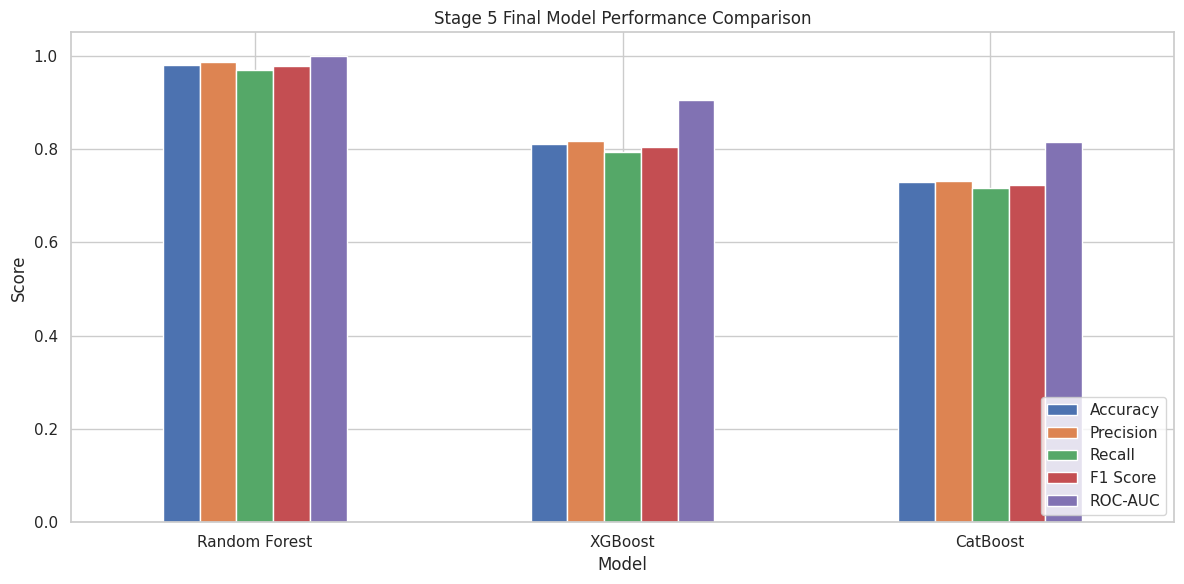

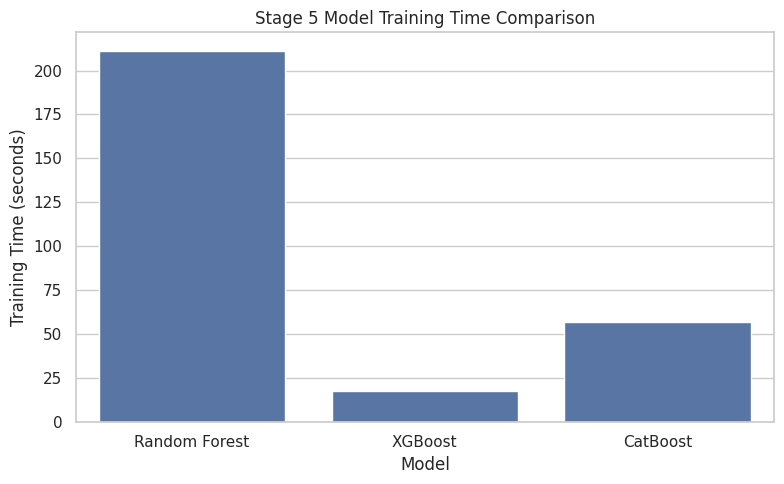


STAGE 5 FINAL SUMMARY

Model ranking by ROC-AUC:
1. Random Forest   ROC-AUC = 0.9983, Accuracy = 0.9791
2. XGBoost         ROC-AUC = 0.9048, Accuracy = 0.8108
3. CatBoost        ROC-AUC = 0.8144, Accuracy = 0.7300

FINAL MODEL SELECTED
✓ Random Forest
✓ Accuracy : 0.9791
✓ F1 Score : 0.9786
✓ ROC-AUC  : 0.9983
✓ Saved as : final_selected_model.joblib

STAGE 5 – PART 4 COMPLETED SUCCESSFULLY
✓ Random Forest compared
✓ XGBoost compared
✓ CatBoost compared
✓ Accuracy compared
✓ Precision compared
✓ Recall compared
✓ F1 Score compared
✓ ROC-AUC compared
✓ Final model selected
✓ Final model saved
✓ Comparison results saved

Ready for Stage 6 – SHAP Explainability.


In [79]:
# =============================================================================
# Stage 5 – Hyperparameter Tuning
# Part 4 – Final Model Comparison
# =============================================================================

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 5 – Part 4 : Final Model Comparison")
print("=" * 80)


# =============================================================================
# 1. ARTIFACT DIRECTORY
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)


# =============================================================================
# 2. VALIDATION
# =============================================================================

required_variables = [
    "rf_tuned_results",
    "xgb_tuned_results",
    "catboost_tuned_results"
]

missing_variables = []

for variable in required_variables:

    if variable not in globals():
        missing_variables.append(variable)

if missing_variables:

    print("\nSome Stage 5 result variables are not available.")

    print("Missing:")
    for variable in missing_variables:
        print(f"  - {variable}")

    print(
        "\nTrying to load saved Stage 5 results from Drive..."
    )


# =============================================================================
# 3. LOAD SAVED RESULTS IF NECESSARY
# =============================================================================

rf_results_path = (
    f"{ARTIFACT_DIR}/random_forest_tuned_results.joblib"
)

xgb_results_path = (
    f"{ARTIFACT_DIR}/xgboost_tuned_results.joblib"
)

catboost_results_path = (
    f"{ARTIFACT_DIR}/catboost_tuned_results.joblib"
)


if "rf_tuned_results" not in globals():

    if os.path.exists(rf_results_path):

        rf_tuned_results = joblib.load(
            rf_results_path
        )

    else:

        raise FileNotFoundError(
            "Random Forest tuned results not found. "
            "Run Stage 5 Part 1 first."
        )


if "xgb_tuned_results" not in globals():

    if os.path.exists(xgb_results_path):

        xgb_tuned_results = joblib.load(
            xgb_results_path
        )

    else:

        raise FileNotFoundError(
            "XGBoost tuned results not found. "
            "Run Stage 5 Part 2 first."
        )


if "catboost_tuned_results" not in globals():

    if os.path.exists(catboost_results_path):

        catboost_tuned_results = joblib.load(
            catboost_results_path
        )

    else:

        raise FileNotFoundError(
            "CatBoost tuned results not found. "
            "Run Stage 5 Part 3 first."
        )


print("\nStage 5 result validation passed.")


# =============================================================================
# 4. EXTRACT RESULTS
# =============================================================================

comparison_data = [

    {
        "Model": "Random Forest",
        "Accuracy": rf_tuned_results["Accuracy"],
        "Precision": rf_tuned_results["Precision"],
        "Recall": rf_tuned_results["Recall"],
        "F1 Score": rf_tuned_results["F1 Score"],
        "ROC-AUC": rf_tuned_results["ROC-AUC"],
        "Training Time": rf_tuned_results["Training Time"]
    },

    {
        "Model": "XGBoost",
        "Accuracy": xgb_tuned_results["Accuracy"],
        "Precision": xgb_tuned_results["Precision"],
        "Recall": xgb_tuned_results["Recall"],
        "F1 Score": xgb_tuned_results["F1 Score"],
        "ROC-AUC": xgb_tuned_results["ROC-AUC"],
        "Training Time": xgb_tuned_results["Training Time"]
    },

    {
        "Model": "CatBoost",
        "Accuracy": catboost_tuned_results["Accuracy"],
        "Precision": catboost_tuned_results["Precision"],
        "Recall": catboost_tuned_results["Recall"],
        "F1 Score": catboost_tuned_results["F1 Score"],
        "ROC-AUC": catboost_tuned_results["ROC-AUC"],
        "Training Time": catboost_tuned_results["Training Time"]
    }

]


# =============================================================================
# 5. CREATE COMPARISON DATAFRAME
# =============================================================================

model_comparison_df = pd.DataFrame(
    comparison_data
)


# =============================================================================
# 6. SORT BY ROC-AUC
# =============================================================================

model_comparison_df = model_comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


# =============================================================================
# 7. DISPLAY COMPARISON
# =============================================================================

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    model_comparison_df.round(4)
)


# =============================================================================
# 8. BEST MODEL BY EACH METRIC
# =============================================================================

print("\n" + "=" * 80)
print("BEST MODEL BY METRIC")
print("=" * 80)


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]


best_by_metric = {}

for metric in metrics:

    best_index = model_comparison_df[metric].idxmax()

    best_model = model_comparison_df.loc[
        best_index,
        "Model"
    ]

    best_value = model_comparison_df.loc[
        best_index,
        metric
    ]

    best_by_metric[metric] = best_model

    print(
        f"{metric:12} : "
        f"{best_model:15} "
        f"({best_value:.4f})"
    )


# =============================================================================
# 9. FINAL MODEL SELECTION
# =============================================================================
#
# Primary selection criterion:
# ROC-AUC
#
# Secondary criteria:
# Accuracy and F1 Score
# =============================================================================

best_index = model_comparison_df[
    "ROC-AUC"
].idxmax()

final_model_name = model_comparison_df.loc[
    best_index,
    "Model"
]

final_accuracy = model_comparison_df.loc[
    best_index,
    "Accuracy"
]

final_precision = model_comparison_df.loc[
    best_index,
    "Precision"
]

final_recall = model_comparison_df.loc[
    best_index,
    "Recall"
]

final_f1 = model_comparison_df.loc[
    best_index,
    "F1 Score"
]

final_roc_auc = model_comparison_df.loc[
    best_index,
    "ROC-AUC"
]

final_training_time = model_comparison_df.loc[
    best_index,
    "Training Time"
]


# =============================================================================
# 10. FINAL MODEL
# =============================================================================

print("\n" + "=" * 80)
print("FINAL SELECTED MODEL")
print("=" * 80)

print(f"Model          : {final_model_name}")
print(f"Accuracy       : {final_accuracy:.4f}")
print(f"Precision      : {final_precision:.4f}")
print(f"Recall         : {final_recall:.4f}")
print(f"F1 Score       : {final_f1:.4f}")
print(f"ROC-AUC        : {final_roc_auc:.4f}")
print(f"Training Time  : {final_training_time:.2f} sec")


# =============================================================================
# 11. LOAD FINAL MODEL
# =============================================================================

if final_model_name == "Random Forest":

    final_model_path = (
        f"{ARTIFACT_DIR}/random_forest_tuned.joblib"
    )

elif final_model_name == "XGBoost":

    final_model_path = (
        f"{ARTIFACT_DIR}/xgboost_tuned.joblib"
    )

elif final_model_name == "CatBoost":

    final_model_path = (
        f"{ARTIFACT_DIR}/catboost_tuned.joblib"
    )

else:

    raise ValueError(
        f"Unknown final model: {final_model_name}"
    )


if not os.path.exists(final_model_path):

    raise FileNotFoundError(
        f"Final model file not found:\n{final_model_path}"
    )


final_model = joblib.load(
    final_model_path
)

print(
    "\nFinal model loaded successfully."
)

print(
    f"Model path:\n{final_model_path}"
)


# =============================================================================
# 12. SAVE FINAL MODEL COPY
# =============================================================================

final_model_copy_path = (
    f"{ARTIFACT_DIR}/final_selected_model.joblib"
)

joblib.dump(
    final_model,
    final_model_copy_path
)

print(
    "\nFinal selected model saved to:"
)

print(
    final_model_copy_path
)


# =============================================================================
# 13. SAVE COMPARISON TABLE
# =============================================================================

comparison_path = (
    f"{ARTIFACT_DIR}/stage5_final_model_comparison.joblib"
)

joblib.dump(
    model_comparison_df,
    comparison_path
)


# =============================================================================
# 14. SAVE FINAL MODEL METADATA
# =============================================================================

final_model_metadata = {

    "Final Model": final_model_name,

    "Selection Criterion": "ROC-AUC",

    "Accuracy": final_accuracy,

    "Precision": final_precision,

    "Recall": final_recall,

    "F1 Score": final_f1,

    "ROC-AUC": final_roc_auc,

    "Training Time": final_training_time,

    "Model Path": final_model_copy_path
}


metadata_path = (
    f"{ARTIFACT_DIR}/final_model_metadata.joblib"
)

joblib.dump(
    final_model_metadata,
    metadata_path
)


# =============================================================================
# 15. PERFORMANCE COMPARISON CHART
# =============================================================================

plot_data = model_comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

plot_data = plot_data.set_index(
    "Model"
)

plt.figure(
    figsize=(12, 6)
)

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Stage 5 Final Model Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.show()


# =============================================================================
# 16. TRAINING TIME COMPARISON
# =============================================================================

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=model_comparison_df,
    x="Model",
    y="Training Time"
)

plt.title(
    "Stage 5 Model Training Time Comparison"
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.xlabel(
    "Model"
)

plt.tight_layout()

plt.show()


# =============================================================================
# 17. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 5 FINAL SUMMARY")
print("=" * 80)

print("\nModel ranking by ROC-AUC:")

for rank, row in model_comparison_df.iterrows():

    print(
        f"{rank + 1}. "
        f"{row['Model']:15} "
        f"ROC-AUC = {row['ROC-AUC']:.4f}, "
        f"Accuracy = {row['Accuracy']:.4f}"
    )


print("\n" + "=" * 80)
print("FINAL MODEL SELECTED")
print("=" * 80)

print(
    f"✓ {final_model_name}"
)

print(
    f"✓ Accuracy : {final_accuracy:.4f}"
)

print(
    f"✓ F1 Score : {final_f1:.4f}"
)

print(
    f"✓ ROC-AUC  : {final_roc_auc:.4f}"
)

print(
    f"✓ Saved as : final_selected_model.joblib"
)


print("\n" + "=" * 80)
print("STAGE 5 – PART 4 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Random Forest compared")
print("✓ XGBoost compared")
print("✓ CatBoost compared")
print("✓ Accuracy compared")
print("✓ Precision compared")
print("✓ Recall compared")
print("✓ F1 Score compared")
print("✓ ROC-AUC compared")
print("✓ Final model selected")
print("✓ Final model saved")
print("✓ Comparison results saved")

print("\nReady for Stage 6 – SHAP Explainability.")

In [80]:
# =============================================================================
# Stage 6 – SHAP Explainability
# Part 1 – Setup, Model Loading and Validation
# =============================================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 6 – Part 1 : SHAP Explainability Setup")
print("=" * 80)

# =============================================================================
# Artifact Path
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

FINAL_MODEL_PATH = (
    f"{ARTIFACT_DIR}/final_selected_model.joblib"
)

# =============================================================================
# Validate Required Variables
# =============================================================================

required_variables = [
    "X_train_rf_xgb",
    "X_test_rf_xgb",
    "y_train",
    "y_test",
    "rf_xgb_feature_names"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} not found. "
            "Please run Stage 3 and Stage 5 first."
        )

print("\nInput validation passed.")

# =============================================================================
# Check Model File
# =============================================================================

if not os.path.exists(FINAL_MODEL_PATH):

    raise FileNotFoundError(
        f"Final model not found:\n{FINAL_MODEL_PATH}"
    )

print("\nFinal model found:")
print(FINAL_MODEL_PATH)

# =============================================================================
# Load Final Selected Model
# =============================================================================

print("\nLoading final selected model...")

final_model = joblib.load(
    FINAL_MODEL_PATH
)

print("Final model loaded successfully.")

# =============================================================================
# Model Validation
# =============================================================================

print("\nLoaded model:")
print(final_model)

if not hasattr(final_model, "predict"):

    raise TypeError(
        "Loaded final model does not support prediction."
    )

if not hasattr(final_model, "predict_proba"):

    raise TypeError(
        "Loaded final model does not support probability prediction."
    )

# =============================================================================
# Dataset Validation
# =============================================================================

print("\nDataset information:")

print(f"Training shape : {X_train_rf_xgb.shape}")
print(f"Testing shape  : {X_test_rf_xgb.shape}")
print(f"Training target: {y_train.shape}")
print(f"Testing target : {y_test.shape}")

# =============================================================================
# Feature Validation
# =============================================================================

if X_train_rf_xgb.shape[1] != len(rf_xgb_feature_names):

    raise ValueError(
        "Feature count does not match feature-name count."
    )

if X_test_rf_xgb.shape[1] != len(rf_xgb_feature_names):

    raise ValueError(
        "Test feature count does not match feature-name count."
    )

print(f"\nFeature count  : {len(rf_xgb_feature_names)}")

print("\nFeature validation passed.")

# =============================================================================
# Create SHAP Sample
# =============================================================================
# We do NOT explain the entire 24,000-row test set.
# A representative sample keeps SHAP fast.

SHAP_SAMPLE_SIZE = 2000

actual_sample_size = min(
    SHAP_SAMPLE_SIZE,
    X_test_rf_xgb.shape[0]
)

np.random.seed(42)

shap_sample_indices = np.random.choice(
    X_test_rf_xgb.shape[0],
    size=actual_sample_size,
    replace=False
)

X_shap = X_test_rf_xgb[
    shap_sample_indices
]

y_shap = np.asarray(
    y_test
)[shap_sample_indices]

print("\nSHAP sample created.")

print(f"SHAP sample size : {X_shap.shape[0]}")
print(f"SHAP feature count: {X_shap.shape[1]}")

# =============================================================================
# Convert Feature Names
# =============================================================================

shap_feature_names = list(
    rf_xgb_feature_names
)

# =============================================================================
# Final Setup Summary
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 6 – PART 1 SUMMARY")
print("=" * 80)

print("✓ Final Random Forest model loaded")
print("✓ Model prediction capability verified")
print("✓ Training/test datasets verified")
print("✓ Feature names verified")
print("✓ SHAP sample created")
print("✓ Random seed fixed for reproducibility")

print("\nSHAP is ready for Part 2.")

print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 6 – Part 1 : SHAP Explainability Setup

Input validation passed.

Final model found:
/content/drive/MyDrive/Btech Final Year Project/artifacts/final_selected_model.joblib

Loading final selected model...
Final model loaded successfully.

Loaded model:
RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=75, n_jobs=-1, random_state=42)

Dataset information:
Training shape : (96000, 66)
Testing shape  : (24000, 66)
Training target: (96000,)
Testing target : (24000,)

Feature count  : 66

Feature validation passed.

SHAP sample created.
SHAP sample size : 2000
SHAP feature count: 66

STAGE 6 – PART 1 SUMMARY
✓ Final Random Forest model loaded
✓ Model prediction capability verified
✓ Training/test datasets verified
✓ Feature names verified
✓ SHAP sample created
✓ Random seed fixed for reproducibility

SHAP is ready for Part 2.


SMART VEHICLE HEALTH INTELLIGENCE
Stage 6 – Part 2 : SHAP Global Explainability

Artifact directory:
/content/drive/MyDrive/Btech Final Year Project/artifacts

Checking Stage 3 / Stage 5 variables...
✓ X_test_rf_xgb found
✓ rf_xgb_feature_names found

Input validation passed.

Feature count : 66
✓ Feature count validation passed.

Preparing SHAP sample...
✓ Existing SHAP sample found.
SHAP sample shape : (500, 66)
✓ Existing SHAP sample is valid.

SHAP sample shape : (500, 66)
✓ SHAP sample validation passed.

CHECKING EXISTING SHAP VALUES

Found:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_values_class1.joblib

Loaded SHAP shape : (500, 66)
✓ Existing SHAP values are valid.
✓ SHAP calculation will NOT be repeated.

SHAP OUTPUT VALIDATION
Input shape : (500, 66)
SHAP shape  : (500, 66)
✓ SHAP dimensions match.
✓ SHAP values contain no NaN or infinite values.

CALCULATING GLOBAL SHAP IMPORTANCE

TOP 20 FEATURES BY SHAP IMPORTANCE


,Rank,Feature,Mean_Absolute_SHAP,Mean_SHAP
0,1,numeric__Catalytic_Converter_Efficiency_Pct,0.028461,0.000941
1,2,numeric__Total_Mileage_km,0.026487,0.001544
2,3,numeric__Vehicle_Age_years,0.023502,-0.000930
3,4,numeric__Oil_Pressure_psi,0.020181,-0.000168
4,5,categorical__Fuel_System_Material_Compatibilit...,0.019333,-0.002672
5,6,numeric__Misfire_Count_per_1000rev,0.017465,-0.001346
6,7,numeric__Vibration_Level_mm_s,0.017389,-0.000240
7,8,numeric__Time_Since_Last_Service_days,0.015758,-0.000010
8,9,numeric__Injector_Flow_Drift_Pct,0.015270,-0.000527
9,10,numeric__Idle_RPM_StdDev,0.013276,-0.001983



✓ SHAP importance saved:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_feature_importance.joblib

✓ SHAP CSV saved:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_feature_importance.csv

GENERATING SHAP GLOBAL SUMMARY PLOT

✓ SHAP global plot saved:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_global_summary.png


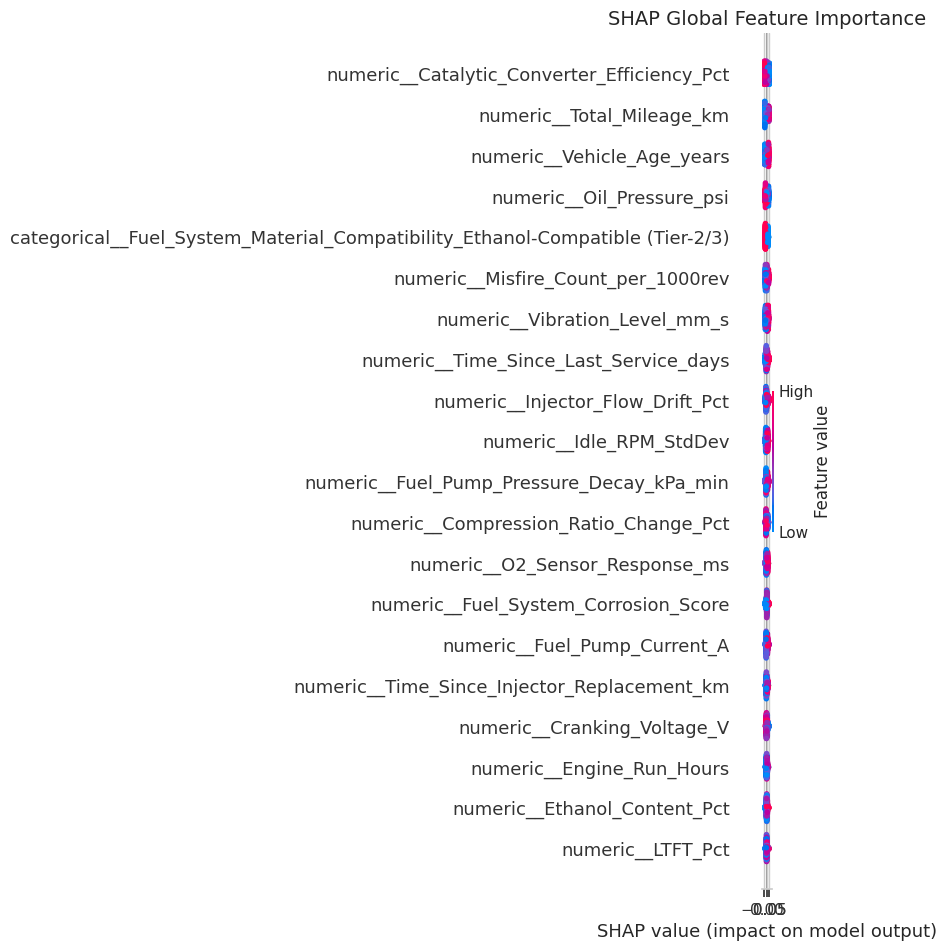

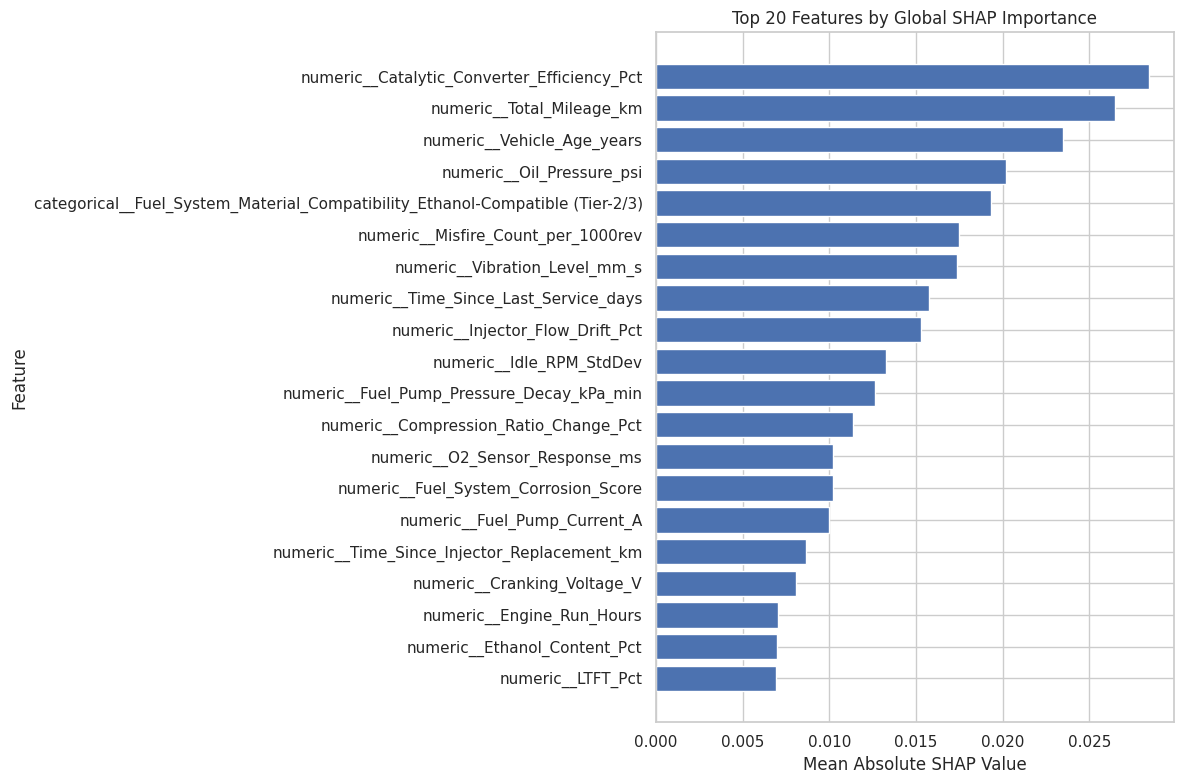


✓ Top 20 bar chart saved:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_top20_global_importance.png

TOP SHAP FEATURE
Feature     : numeric__Catalytic_Converter_Efficiency_Pct
Mean |SHAP| : 0.028461
Mean SHAP   : 0.000941

STAGE 6 – PART 2 COMPLETED SUCCESSFULLY
✓ SHAP sample prepared
✓ Existing SHAP values reused when available
✓ SHAP calculated automatically when missing
✓ Class 1 SHAP values extracted
✓ Class 1 = Need_Maintenance = Yes
✓ SHAP dimensions validated
✓ Feature names validated
✓ Global SHAP importance calculated
✓ Top 20 features displayed
✓ SHAP summary plot generated
✓ Top 20 bar chart generated
✓ SHAP artifacts saved

Saved files:
1. /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_values_class1.joblib
2. /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_sample_dense.joblib
3. /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_feature_importance.joblib
4. /content/drive/MyDrive/Btech Final Year Project/artifacts

In [81]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 6 – Part 2 : SHAP Global Explainability
# FINAL SAFE VERSION
#
# Behavior:
# 1. If saved SHAP values exist -> reuse them
# 2. If saved SHAP values do not exist -> calculate them once
# 3. Handles SHAP output formats:
#       (500, 66)
#       (500, 66, 2)
#       (2, 500, 66)
#       [class_0, class_1]
# 4. Extracts Class 1 = Need_Maintenance = Yes
# 5. Saves SHAP artifacts
# 6. Displays Top 20 SHAP features
# 7. Generates and saves SHAP summary image
# =============================================================================


# =============================================================================
# 1. IMPORTS
# =============================================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# =============================================================================
# 2. HEADER
# =============================================================================

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 6 – Part 2 : SHAP Global Explainability")
print("=" * 80)


# =============================================================================
# 3. ARTIFACT PATHS
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

MODEL_PATH = os.path.join(
    ARTIFACT_DIR,
    "final_selected_model.joblib"
)

SHAP_VALUES_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_values_class1.joblib"
)

SHAP_SAMPLE_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_sample_dense.joblib"
)

SHAP_IMPORTANCE_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_feature_importance.joblib"
)

SHAP_CSV_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_feature_importance.csv"
)

SHAP_PLOT_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_global_summary.png"
)


# =============================================================================
# 4. CHECK ARTIFACT DIRECTORY
# =============================================================================

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

print("\nArtifact directory:")
print(ARTIFACT_DIR)


# =============================================================================
# 5. CHECK REQUIRED NOTEBOOK VARIABLES
# =============================================================================

print("\nChecking Stage 3 / Stage 5 variables...")

required_variables = [
    "X_test_rf_xgb",
    "rf_xgb_feature_names"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise NameError(
        "\nRequired variables are missing:\n"
        + "\n".join(
            f"  - {variable}"
            for variable in missing_variables
        )
        + "\n\n"
        "Please run Stage 3 and Stage 5 before Stage 6 Part 2."
    )

print("✓ X_test_rf_xgb found")
print("✓ rf_xgb_feature_names found")

print("\nInput validation passed.")


# =============================================================================
# 6. FEATURE NAMES
# =============================================================================

feature_names = list(
    rf_xgb_feature_names
)

feature_count = len(
    feature_names
)

print(
    f"\nFeature count : {feature_count}"
)


# =============================================================================
# 7. VALIDATE TEST DATA
# =============================================================================

if hasattr(
    X_test_rf_xgb,
    "shape"
):

    test_feature_count = (
        X_test_rf_xgb.shape[1]
    )

else:

    X_test_rf_xgb = np.asarray(
        X_test_rf_xgb
    )

    test_feature_count = (
        X_test_rf_xgb.shape[1]
    )


if test_feature_count != feature_count:

    raise ValueError(
        "\nFeature count mismatch:\n"
        f"X_test_rf_xgb : {test_feature_count}\n"
        f"Feature names : {feature_count}"
    )

print(
    "✓ Feature count validation passed."
)


# =============================================================================
# 8. LOAD FINAL MODEL ONLY WHEN SHAP NEEDS TO BE CALCULATED
# =============================================================================

final_model = None


# =============================================================================
# 9. SHAP SAMPLE
# =============================================================================

SHAP_SAMPLE_SIZE = 500
RANDOM_STATE = 42


print("\nPreparing SHAP sample...")


# -------------------------------------------------------------------------
# If an existing SHAP sample exists, try to reuse it.
# -------------------------------------------------------------------------

if os.path.exists(
    SHAP_SAMPLE_PATH
):

    try:

        X_shap_dense = np.asarray(
            joblib.load(
                SHAP_SAMPLE_PATH
            ),
            dtype=np.float64
        )

        print(
            "✓ Existing SHAP sample found."
        )

        print(
            f"SHAP sample shape : "
            f"{X_shap_dense.shape}"
        )

        # Validate saved sample
        if (
            X_shap_dense.ndim != 2
            or
            X_shap_dense.shape[1] != feature_count
        ):

            print(
                "Existing SHAP sample has "
                "invalid dimensions."
            )

            print(
                "Creating a new SHAP sample..."
            )

            X_shap_dense = None

        else:

            print(
                "✓ Existing SHAP sample is valid."
            )

    except Exception as error:

        print(
            "Existing SHAP sample could not "
            "be loaded."
        )

        print(
            f"Reason: {error}"
        )

        X_shap_dense = None

else:

    X_shap_dense = None


# -------------------------------------------------------------------------
# Create new SHAP sample if required
# -------------------------------------------------------------------------

if X_shap_dense is None:

    rng = np.random.RandomState(
        RANDOM_STATE
    )

    sample_size = min(
        SHAP_SAMPLE_SIZE,
        X_test_rf_xgb.shape[0]
    )

    sample_indices = rng.choice(
        X_test_rf_xgb.shape[0],
        size=sample_size,
        replace=False
    )

    X_shap = (
        X_test_rf_xgb[
            sample_indices
        ]
    )

    # Convert sparse matrix to dense
    if hasattr(
        X_shap,
        "toarray"
    ):

        X_shap_dense = (
            X_shap.toarray()
        )

    else:

        X_shap_dense = np.asarray(
            X_shap
        )

    # Force numeric
    X_shap_dense = np.asarray(
        X_shap_dense,
        dtype=np.float64
    )

    print(
        f"New SHAP sample shape : "
        f"{X_shap_dense.shape}"
    )

    # Save sample
    joblib.dump(
        X_shap_dense,
        SHAP_SAMPLE_PATH
    )

    print(
        "✓ SHAP sample saved."
    )


# =============================================================================
# 10. SHAP SAMPLE VALIDATION
# =============================================================================

if X_shap_dense.ndim != 2:

    raise ValueError(
        f"SHAP sample must be 2D. "
        f"Found: {X_shap_dense.shape}"
    )

if X_shap_dense.shape[1] != feature_count:

    raise ValueError(
        "SHAP sample feature count mismatch.\n"
        f"SHAP sample : {X_shap_dense.shape[1]}\n"
        f"Features    : {feature_count}"
    )

if not np.isfinite(
    X_shap_dense
).all():

    raise ValueError(
        "SHAP sample contains NaN or infinite values."
    )

print(
    f"\nSHAP sample shape : "
    f"{X_shap_dense.shape}"
)

print(
    "✓ SHAP sample validation passed."
)


# =============================================================================
# 11. FUNCTION TO EXTRACT CLASS 1 SHAP VALUES
# =============================================================================

def extract_class1_shap_values(
    shap_output,
    expected_shape
):

    # -------------------------------------------------------------------------
    # CASE 1
    # SHAP returns:
    #
    # [
    #     class_0_values,
    #     class_1_values
    # ]
    # -------------------------------------------------------------------------

    if isinstance(
        shap_output,
        list
    ):

        if len(shap_output) != 2:

            raise ValueError(
                "Expected binary classification "
                "SHAP output with 2 classes."
            )

        class1_values = np.asarray(
            shap_output[1],
            dtype=np.float64
        )

        if (
            class1_values.shape
            != expected_shape
        ):

            raise ValueError(
                "Class 1 SHAP shape mismatch.\n"
                f"Expected : {expected_shape}\n"
                f"Found    : {class1_values.shape}"
            )

        return class1_values


    # -------------------------------------------------------------------------
    # Convert to numpy
    # -------------------------------------------------------------------------

    shap_array = np.asarray(
        shap_output,
        dtype=np.float64
    )


    # -------------------------------------------------------------------------
    # CASE 2
    #
    # SHAP output:
    # (samples, features)
    # -------------------------------------------------------------------------

    if shap_array.ndim == 2:

        if (
            shap_array.shape
            == expected_shape
        ):

            return shap_array


    # -------------------------------------------------------------------------
    # CASE 3
    #
    # SHAP output:
    # (samples, features, classes)
    #
    # Example:
    # (500, 66, 2)
    # -------------------------------------------------------------------------

    if shap_array.ndim == 3:

        if (
            shap_array.shape[0]
            == expected_shape[0]
            and
            shap_array.shape[1]
            == expected_shape[1]
            and
            shap_array.shape[2]
            == 2
        ):

            return (
                shap_array[:, :, 1]
            )


        # ---------------------------------------------------------------------
        # CASE 4
        #
        # SHAP output:
        # (classes, samples, features)
        # ---------------------------------------------------------------------

        if (
            shap_array.shape[0] == 2
            and
            shap_array.shape[1]
            == expected_shape[0]
            and
            shap_array.shape[2]
            == expected_shape[1]
        ):

            return (
                shap_array[1]
            )


    # -------------------------------------------------------------------------
    # Unsupported format
    # -------------------------------------------------------------------------

    raise ValueError(
        "\nUnsupported SHAP output format.\n"
        f"SHAP output shape: "
        f"{shap_array.shape}\n"
        f"Expected sample shape: "
        f"{expected_shape}"
    )


# =============================================================================
# 12. LOAD EXISTING SHAP VALUES
# =============================================================================

shap_values_class1 = None


if os.path.exists(
    SHAP_VALUES_PATH
):

    print("\n" + "=" * 80)
    print("CHECKING EXISTING SHAP VALUES")
    print("=" * 80)

    print(
        f"\nFound:\n{SHAP_VALUES_PATH}"
    )

    try:

        saved_shap = joblib.load(
            SHAP_VALUES_PATH
        )

        shap_values_class1 = (
            extract_class1_shap_values(
                saved_shap,
                X_shap_dense.shape
            )
        )

        print(
            f"\nLoaded SHAP shape : "
            f"{shap_values_class1.shape}"
        )

        print(
            "✓ Existing SHAP values are valid."
        )

        print(
            "✓ SHAP calculation will NOT be repeated."
        )

    except Exception as error:

        print(
            "\nExisting SHAP artifact is invalid."
        )

        print(
            f"Reason: {error}"
        )

        print(
            "\nA fresh SHAP calculation "
            "will be performed."
        )

        shap_values_class1 = None


# =============================================================================
# 13. CALCULATE SHAP ONLY IF FILE IS MISSING OR INVALID
# =============================================================================

if shap_values_class1 is None:

    print("\n" + "=" * 80)
    print("SHAP VALUES NOT AVAILABLE")
    print("=" * 80)

    print(
        "\nCalculating SHAP values for the first time..."
    )

    # -------------------------------------------------------------------------
    # Load model
    # -------------------------------------------------------------------------

    if not os.path.exists(
        MODEL_PATH
    ):

        raise FileNotFoundError(
            "\nFinal model not found:\n"
            f"{MODEL_PATH}\n\n"
            "Run Stage 5 Part 4 first."
        )

    print(
        "\nLoading final selected model..."
    )

    final_model = joblib.load(
        MODEL_PATH
    )

    print(
        "✓ Final model loaded."
    )


    # -------------------------------------------------------------------------
    # Create TreeExplainer
    # -------------------------------------------------------------------------

    print(
        "\nCreating TreeExplainer..."
    )

    start_time = time.time()

    explainer = shap.TreeExplainer(
        final_model
    )

    print(
        f"✓ TreeExplainer created in "
        f"{time.time() - start_time:.2f} seconds."
    )


    # -------------------------------------------------------------------------
    # Calculate SHAP
    # -------------------------------------------------------------------------

    print(
        "\nCalculating SHAP values..."
    )

    print(
        f"Samples : {X_shap_dense.shape[0]}"
    )

    print(
        f"Features: {X_shap_dense.shape[1]}"
    )

    start_time = time.time()

    shap_output = explainer.shap_values(
        X_shap_dense,
        check_additivity=False
    )

    calculation_time = (
        time.time()
        - start_time
    )

    print(
        f"\n✓ SHAP calculation completed "
        f"in {calculation_time:.2f} seconds."
    )


    # -------------------------------------------------------------------------
    # Show original output
    # -------------------------------------------------------------------------

    if isinstance(
        shap_output,
        list
    ):

        print(
            "Original SHAP output : list"
        )

        print(
            f"Number of classes    : "
            f"{len(shap_output)}"
        )

    else:

        print(
            "Original SHAP output shape : "
            f"{np.asarray(shap_output).shape}"
        )


    # -------------------------------------------------------------------------
    # Extract Class 1
    # -------------------------------------------------------------------------

    shap_values_class1 = (
        extract_class1_shap_values(
            shap_output,
            X_shap_dense.shape
        )
    )

    print(
        f"\nClass 1 SHAP shape : "
        f"{shap_values_class1.shape}"
    )

    print(
        "✓ Class 1 SHAP values extracted."
    )

    print(
        "Class 1 = Need_Maintenance = Yes"
    )


    # -------------------------------------------------------------------------
    # Save SHAP values
    # -------------------------------------------------------------------------

    joblib.dump(
        shap_values_class1,
        SHAP_VALUES_PATH
    )

    print(
        "\n✓ SHAP values saved:"
    )

    print(
        SHAP_VALUES_PATH
    )


# =============================================================================
# 14. FINAL SHAP VALIDATION
# =============================================================================

print("\n" + "=" * 80)
print("SHAP OUTPUT VALIDATION")
print("=" * 80)


expected_shape = (
    X_shap_dense.shape
)


if shap_values_class1.shape != expected_shape:

    raise ValueError(
        "\nSHAP shape mismatch.\n"
        f"Expected : {expected_shape}\n"
        f"Found    : {shap_values_class1.shape}"
    )


if not np.isfinite(
    shap_values_class1
).all():

    raise ValueError(
        "SHAP values contain NaN or infinite values."
    )


print(
    f"Input shape : "
    f"{X_shap_dense.shape}"
)

print(
    f"SHAP shape  : "
    f"{shap_values_class1.shape}"
)

print(
    "✓ SHAP dimensions match."
)

print(
    "✓ SHAP values contain no NaN or infinite values."
)


# =============================================================================
# 15. GLOBAL SHAP IMPORTANCE
# =============================================================================

print("\n" + "=" * 80)
print("CALCULATING GLOBAL SHAP IMPORTANCE")
print("=" * 80)


mean_abs_shap = np.mean(
    np.abs(
        shap_values_class1
    ),
    axis=0
)


mean_shap = np.mean(
    shap_values_class1,
    axis=0
)


shap_feature_importance = pd.DataFrame({

    "Feature":
        feature_names,

    "Mean_Absolute_SHAP":
        mean_abs_shap,

    "Mean_SHAP":
        mean_shap

})


# Sort descending
shap_feature_importance = (
    shap_feature_importance
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


# Add rank
shap_feature_importance.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(
            shap_feature_importance
        ) + 1
    )
)


# =============================================================================
# 16. TOP 20 TABLE
# =============================================================================

print("\n" + "=" * 80)
print("TOP 20 FEATURES BY SHAP IMPORTANCE")
print("=" * 80)


display(
    shap_feature_importance.head(20)
)


# =============================================================================
# 17. SAVE GLOBAL SHAP RESULTS
# =============================================================================

joblib.dump(
    shap_feature_importance,
    SHAP_IMPORTANCE_PATH
)


shap_feature_importance.to_csv(
    SHAP_CSV_PATH,
    index=False
)


print(
    "\n✓ SHAP importance saved:"
)

print(
    SHAP_IMPORTANCE_PATH
)

print(
    "\n✓ SHAP CSV saved:"
)

print(
    SHAP_CSV_PATH
)


# =============================================================================
# 18. SHAP GLOBAL SUMMARY PLOT
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING SHAP GLOBAL SUMMARY PLOT")
print("=" * 80)


plt.figure(
    figsize=(10, 8)
)


shap.summary_plot(
    shap_values_class1,
    X_shap_dense,
    feature_names=feature_names,
    max_display=20,
    show=False
)


plt.title(
    "SHAP Global Feature Importance",
    fontsize=14
)


plt.tight_layout()


# Save image
plt.savefig(
    SHAP_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\n✓ SHAP global plot saved:"
)

print(
    SHAP_PLOT_PATH
)


# Display image
plt.show()


plt.close()


# =============================================================================
# 19. ALSO CREATE SIMPLE TOP-20 BAR CHART
# =============================================================================

BAR_PLOT_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_top20_global_importance.png"
)


top_20 = (
    shap_feature_importance
    .head(20)
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=True
    )
)


plt.figure(
    figsize=(12, 8)
)


plt.barh(
    top_20["Feature"],
    top_20["Mean_Absolute_SHAP"]
)


plt.xlabel(
    "Mean Absolute SHAP Value"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Top 20 Features by Global SHAP Importance"
)


plt.tight_layout()


plt.savefig(
    BAR_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


plt.close()


print(
    "\n✓ Top 20 bar chart saved:"
)

print(
    BAR_PLOT_PATH
)


# =============================================================================
# 20. TOP FEATURE
# =============================================================================

top_feature = (
    shap_feature_importance.iloc[0]
)


print("\n" + "=" * 80)
print("TOP SHAP FEATURE")
print("=" * 80)


print(
    f"Feature     : "
    f"{top_feature['Feature']}"
)


print(
    f"Mean |SHAP| : "
    f"{top_feature['Mean_Absolute_SHAP']:.6f}"
)


print(
    f"Mean SHAP   : "
    f"{top_feature['Mean_SHAP']:.6f}"
)


# =============================================================================
# 21. KEEP VARIABLES FOR STAGE 6 PART 3 / PART 4
# =============================================================================

globals()[
    "shap_values_class1"
] = shap_values_class1


globals()[
    "X_shap_dense"
] = X_shap_dense


globals()[
    "shap_feature_importance"
] = shap_feature_importance


globals()[
    "feature_names"
] = feature_names


# =============================================================================
# 22. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 6 – PART 2 COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "✓ SHAP sample prepared"
)

print(
    "✓ Existing SHAP values reused when available"
)

print(
    "✓ SHAP calculated automatically when missing"
)

print(
    "✓ Class 1 SHAP values extracted"
)

print(
    "✓ Class 1 = Need_Maintenance = Yes"
)

print(
    "✓ SHAP dimensions validated"
)

print(
    "✓ Feature names validated"
)

print(
    "✓ Global SHAP importance calculated"
)

print(
    "✓ Top 20 features displayed"
)

print(
    "✓ SHAP summary plot generated"
)

print(
    "✓ Top 20 bar chart generated"
)

print(
    "✓ SHAP artifacts saved"
)

print(
    "\nSaved files:"
)

print(
    f"1. {SHAP_VALUES_PATH}"
)

print(
    f"2. {SHAP_SAMPLE_PATH}"
)

print(
    f"3. {SHAP_IMPORTANCE_PATH}"
)

print(
    f"4. {SHAP_CSV_PATH}"
)

print(
    f"5. {SHAP_PLOT_PATH}"
)

print(
    f"6. {BAR_PLOT_PATH}"
)

print(
    "\nTop SHAP feature:"
)

print(
    top_feature["Feature"]
)

print(
    "\nReady for Stage 6 Part 3."
)

print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 6 – Part 3 : Individual Vehicle SHAP Explainability

Input validation passed.

Checking existing SHAP variables...
Using existing shap_values_class1.

SHAP input shape  : (500, 66)
SHAP class-1 shape: (500, 66)
Feature count     : 66

✓ SHAP shape validation passed.

Loading final selected model...
Final model loaded.
Generating predictions...
Predictions generated.

Maintenance predictions : 234
Healthy predictions      : 266

Selected SHAP sample indices:
[np.int64(0), np.int64(1), 211, 39]

INDIVIDUAL VEHICLE EXPLANATIONS

--------------------------------------------------------------------------------
VEHICLE 1
--------------------------------------------------------------------------------
SHAP Sample Index       : 0
Actual Target           : 1
Predicted Class         : 1
Maintenance Probability : 0.9744
Prediction              : NEEDS MAINTENANCE

Top factors increasing maintenance risk:


,Feature,Feature_Value,SHAP_Value
0,numeric__Total_Mileage_km,111038.00,0.053436
1,numeric__Injector_Flow_Drift_Pct,12.14,0.045978
2,numeric__Fuel_Pump_Pressure_Decay_kPa_min,24.00,0.043941
3,numeric__Vibration_Level_mm_s,9.55,0.037187
4,numeric__Misfire_Count_per_1000rev,8.57,0.031913


Top factors decreasing maintenance risk:


,Feature,Feature_Value,SHAP_Value
0,numeric__Time_Since_Last_Service_days,53.63,-0.008960
1,categorical__Fuel_System_Material_Compatibilit...,1.00,-0.007686
2,numeric__O2_Sensor_Response_ms,116.97,-0.003460
3,categorical__Fuel_System_Material_Compatibilit...,0.00,-0.003095
4,numeric__AFR_Lambda,1.01,-0.001369



--------------------------------------------------------------------------------
VEHICLE 2
--------------------------------------------------------------------------------
SHAP Sample Index       : 1
Actual Target           : 0
Predicted Class         : 0
Maintenance Probability : 0.2889
Prediction              : NO MAINTENANCE

Top factors increasing maintenance risk:


...


--------------------------------------------------------------------------------
VEHICLE 4
--------------------------------------------------------------------------------
SHAP Sample Index       : 39
Actual Target           : 0
Predicted Class         : 0
Maintenance Probability : 0.0216
Prediction              : NO MAINTENANCE

Top factors increasing maintenance risk:


,Feature,Feature_Value,SHAP_Value
0,numeric__Fuel_Pump_Current_A,6.630,0.006897
1,numeric__LTFT_Pct,13.380,0.005169
2,numeric__Spark_Plug_Wear_mm,1.023,0.003235
3,numeric__Ethanol_Content_Pct,62.400,0.001237
4,numeric__Fuel_Water_Contamination_ppm,459.000,0.000710


Top factors decreasing maintenance risk:


,Feature,Feature_Value,SHAP_Value
0,numeric__Catalytic_Converter_Efficiency_Pct,86.2,-0.051615
1,numeric__Time_Since_Last_Service_days,24.0,-0.048582
2,numeric__Vehicle_Age_years,3.0,-0.034552
3,numeric__Total_Mileage_km,64424.0,-0.031832
4,numeric__O2_Sensor_Response_ms,97.0,-0.025293



INDIVIDUAL SHAP PLOTS


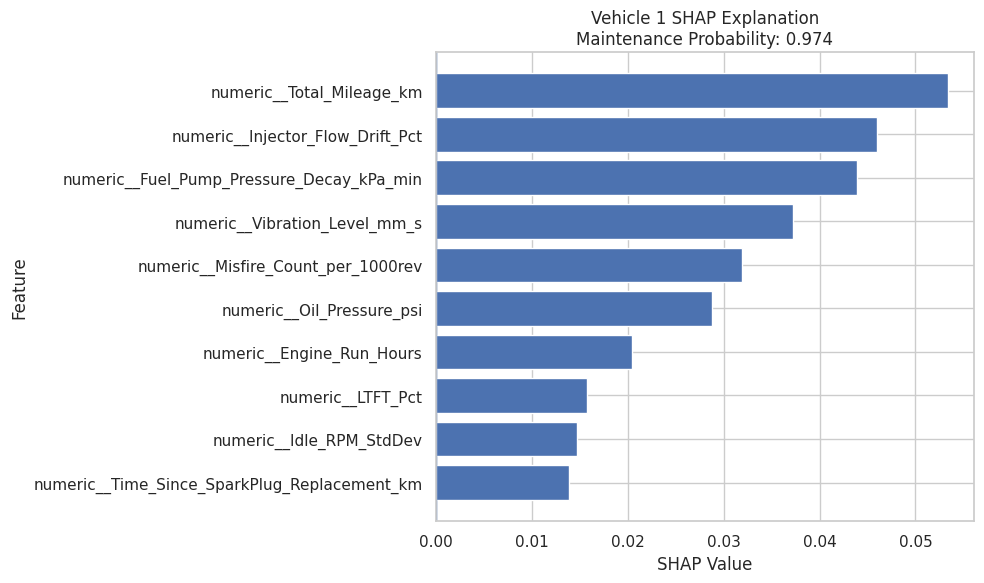

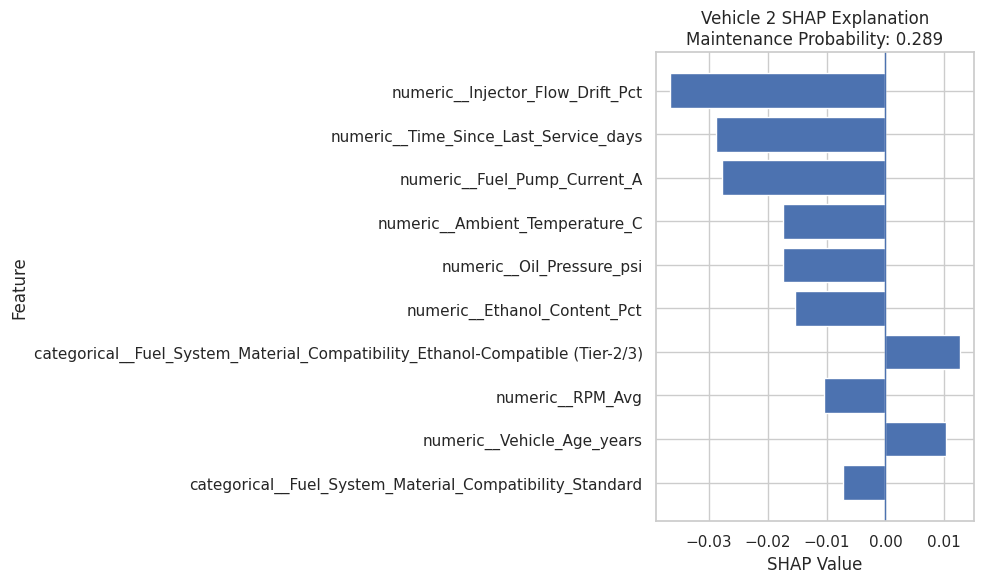

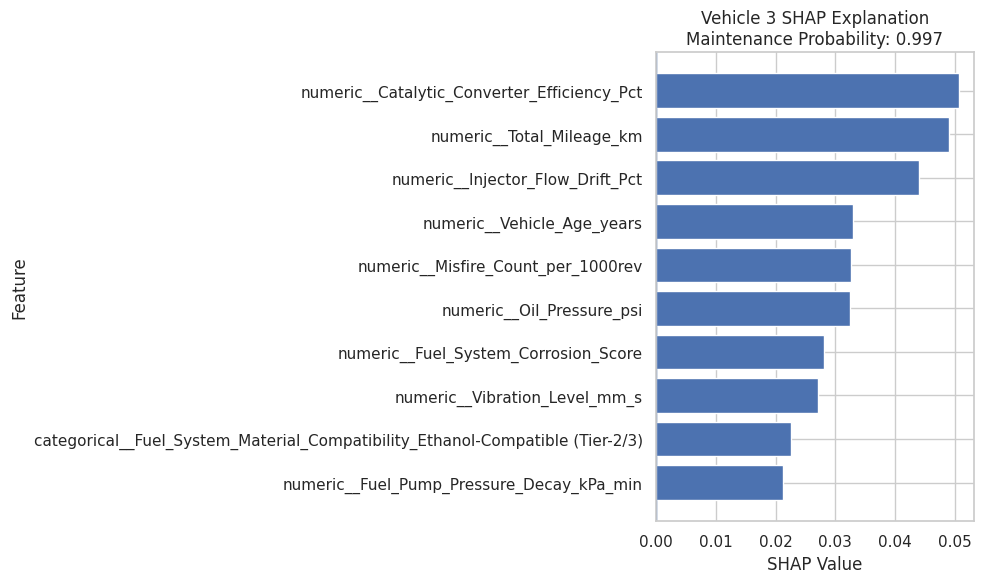

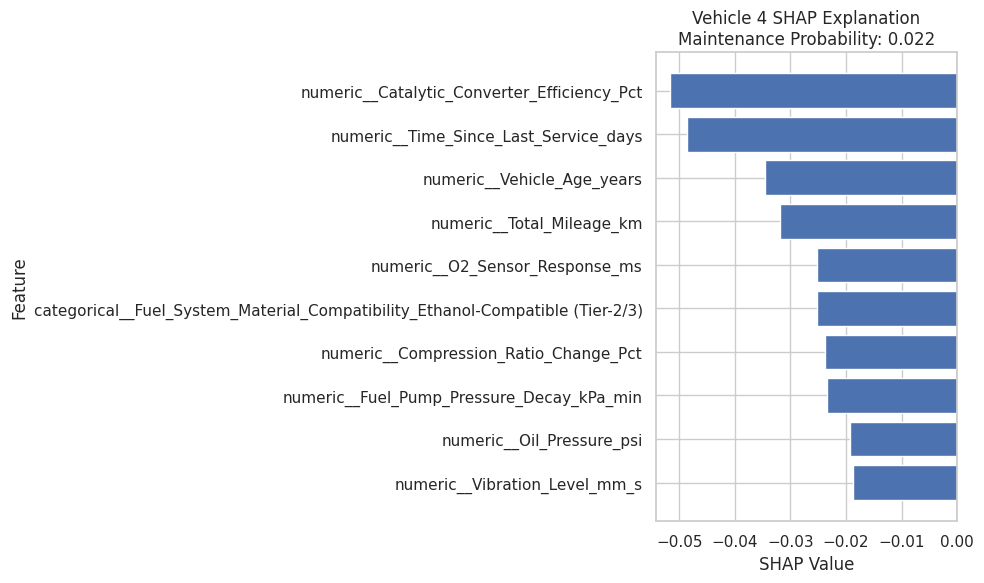


INDIVIDUAL VEHICLE SUMMARY


,Vehicle,SHAP_Index,Actual,Predicted,Maintenance_Probability
0,1,0,1,Needs Maintenance,0.9744
1,2,1,0,No Maintenance,0.2889
2,3,211,0,Needs Maintenance,0.9968
3,4,39,0,No Maintenance,0.0216



Individual explanations saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_individual_explanations.joblib

Summary saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_individual_summary.joblib

STAGE 6 – PART 3 COMPLETED SUCCESSFULLY
✓ Existing SHAP values reused
✓ No SHAP recalculation performed
✓ Class 1 SHAP values used
✓ Individual vehicles analyzed
✓ Maintenance probability calculated
✓ Positive SHAP contributors identified
✓ Negative SHAP contributors identified
✓ Individual SHAP plots generated
✓ Individual explanations saved
✓ Summary saved

Ready for Stage 6 Part 4.


In [82]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 6 – Part 3 : Individual Vehicle SHAP Explainability
# FINAL FAST VERSION
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 6 – Part 3 : Individual Vehicle SHAP Explainability")
print("=" * 80)

# =============================================================================
# Paths
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/Btech Final Year Project/artifacts"
)

INDIVIDUAL_PATH = (
    f"{ARTIFACT_DIR}/shap_individual_explanations.joblib"
)

SUMMARY_PATH = (
    f"{ARTIFACT_DIR}/shap_individual_summary.joblib"
)

# =============================================================================
# Validate Required Variables
# =============================================================================

required_variables = [
    "X_shap_dense",
    "rf_xgb_feature_names",
    "y_test"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} not found. "
            "Please run Stage 6 Part 1 first."
        )

print("\nInput validation passed.")

# =============================================================================
# Recover Existing SHAP Values
# =============================================================================

print("\nChecking existing SHAP variables...")

shap_class1 = None

# Case 1: already available
if "shap_values_class1" in globals():

    shap_class1 = shap_values_class1

    print("Using existing shap_values_class1.")

# Case 2: original SHAP output is available
elif "shap_output" in globals():

    print(
        "shap_values_class1 not found."
    )

    print(
        "Using existing shap_output instead."
    )

    original_shape = np.asarray(
        shap_output
    ).shape

    print(
        f"Original SHAP shape : {original_shape}"
    )

    shap_array = np.asarray(
        shap_output,
        dtype=np.float64
    )

    if shap_array.ndim == 3:

        if shap_array.shape[2] == 2:

            # Binary classification
            # Class 1 = Need_Maintenance = Yes

            shap_class1 = shap_array[:, :, 1]

            print(
                "Class 1 SHAP values extracted."
            )

        else:

            raise ValueError(
                "Unexpected SHAP output shape."
            )

    elif shap_array.ndim == 2:

        shap_class1 = shap_array

        print(
            "2D SHAP values detected."
        )

    else:

        raise ValueError(
            "Unsupported SHAP output dimensions."
        )

# Case 3: no SHAP values available
else:

    raise NameError(
        "\nNo existing SHAP values were found.\n\n"
        "Expected either:\n"
        "1. shap_values_class1\n"
        "or\n"
        "2. shap_output\n\n"
        "Do NOT rerun Stage 6 Part 2 yet."
    )

# =============================================================================
# Convert to NumPy
# =============================================================================

X_shap_array = np.asarray(
    X_shap_dense,
    dtype=np.float64
)

shap_class1 = np.asarray(
    shap_class1,
    dtype=np.float64
)

feature_names = list(
    rf_xgb_feature_names
)

print("\nSHAP input shape  :", X_shap_array.shape)
print("SHAP class-1 shape:", shap_class1.shape)
print("Feature count     :", len(feature_names))

# =============================================================================
# Shape Validation
# =============================================================================

if X_shap_array.ndim != 2:

    raise ValueError(
        "X_shap_dense must be a 2D matrix."
    )

if shap_class1.ndim != 2:

    raise ValueError(
        "Class 1 SHAP values must be a 2D matrix."
    )

if X_shap_array.shape != shap_class1.shape:

    raise ValueError(
        "SHAP input and SHAP value dimensions do not match.\n"
        f"Input  : {X_shap_array.shape}\n"
        f"SHAP   : {shap_class1.shape}"
    )

if X_shap_array.shape[1] != len(feature_names):

    raise ValueError(
        "Feature count does not match feature names."
    )

print("\n✓ SHAP shape validation passed.")

# =============================================================================
# Select Representative Vehicles
# =============================================================================

# Use model probabilities if available.
# Otherwise use SHAP score to identify examples.

if "y_pred_shap" in globals() and "y_prob_shap" in globals():

    predictions = np.asarray(
        y_pred_shap
    ).astype(int)

    probabilities = np.asarray(
        y_prob_shap
    ).astype(float)

    print(
        "\nUsing existing SHAP sample predictions."
    )

else:

    # Load final model only if predictions are not already available

    final_model_path = (
        f"{ARTIFACT_DIR}/final_selected_model.joblib"
    )

    if not os.path.exists(final_model_path):

        raise FileNotFoundError(
            f"Final model not found:\n{final_model_path}"
        )

    print(
        "\nLoading final selected model..."
    )

    final_model = joblib.load(
        final_model_path
    )

    print(
        "Final model loaded."
    )

    print(
        "Generating predictions..."
    )

    predictions = np.asarray(
        final_model.predict(
            X_shap_array
        )
    ).astype(int)

    probabilities = np.asarray(
        final_model.predict_proba(
            X_shap_array
        )[:, 1]
    ).astype(float)

    print(
        "Predictions generated."
    )

# =============================================================================
# Find Maintenance and Healthy Vehicles
# =============================================================================

maintenance_indices = np.where(
    predictions == 1
)[0]

healthy_indices = np.where(
    predictions == 0
)[0]

print(
    f"\nMaintenance predictions : "
    f"{len(maintenance_indices)}"
)

print(
    f"Healthy predictions      : "
    f"{len(healthy_indices)}"
)

if len(maintenance_indices) == 0:

    raise ValueError(
        "No maintenance vehicle found."
    )

if len(healthy_indices) == 0:

    raise ValueError(
        "No healthy vehicle found."
    )

# =============================================================================
# Select 4 Vehicles
# =============================================================================

selected_indices = []

# Maintenance example 1
selected_indices.append(
    maintenance_indices[0]
)

# Healthy example 1
selected_indices.append(
    healthy_indices[0]
)

# Highest maintenance probability
high_risk_index = int(
    np.argmax(probabilities)
)

if high_risk_index not in selected_indices:

    selected_indices.append(
        high_risk_index
    )

# Lowest maintenance probability
low_risk_index = int(
    np.argmin(probabilities)
)

if low_risk_index not in selected_indices:

    selected_indices.append(
        low_risk_index
    )

# Maximum 4
selected_indices = selected_indices[:4]

print(
    "\nSelected SHAP sample indices:"
)

print(
    selected_indices
)

# =============================================================================
# Actual Target Helper
# =============================================================================

def get_actual_target(index):

    if hasattr(y_test, "iloc"):

        return int(
            y_test.iloc[index]
        )

    return int(
        y_test[index]
    )

# =============================================================================
# Individual Explanations
# =============================================================================

individual_explanations = []

print("\n" + "=" * 80)
print("INDIVIDUAL VEHICLE EXPLANATIONS")
print("=" * 80)

for vehicle_number, index in enumerate(
    selected_indices,
    start=1
):

    shap_row = shap_class1[index]

    feature_values = X_shap_array[index]

    prediction = int(
        predictions[index]
    )

    probability = float(
        probabilities[index]
    )

    actual = get_actual_target(
        index
    )

    # ---------------------------------------------------------
    # Positive contributors
    # ---------------------------------------------------------

    positive_indices = np.where(
        shap_row > 0
    )[0]

    positive_indices = positive_indices[
        np.argsort(
            shap_row[positive_indices]
        )[::-1]
    ]

    positive_indices = positive_indices[:5]

    # ---------------------------------------------------------
    # Negative contributors
    # ---------------------------------------------------------

    negative_indices = np.where(
        shap_row < 0
    )[0]

    negative_indices = negative_indices[
        np.argsort(
            np.abs(
                shap_row[negative_indices]
            )
        )[::-1]
    ]

    negative_indices = negative_indices[:5]

    # ---------------------------------------------------------
    # Create tables
    # ---------------------------------------------------------

    positive_rows = []

    for i in positive_indices:

        positive_rows.append({

            "Feature":
                feature_names[i],

            "Feature_Value":
                round(
                    float(feature_values[i]),
                    4
                ),

            "SHAP_Value":
                round(
                    float(shap_row[i]),
                    6
                )

        })

    negative_rows = []

    for i in negative_indices:

        negative_rows.append({

            "Feature":
                feature_names[i],

            "Feature_Value":
                round(
                    float(feature_values[i]),
                    4
                ),

            "SHAP_Value":
                round(
                    float(shap_row[i]),
                    6
                )

        })

    # ---------------------------------------------------------
    # Print result
    # ---------------------------------------------------------

    print("\n" + "-" * 80)

    print(
        f"VEHICLE {vehicle_number}"
    )

    print("-" * 80)

    print(
        f"SHAP Sample Index       : {index}"
    )

    print(
        f"Actual Target           : {actual}"
    )

    print(
        f"Predicted Class         : {prediction}"
    )

    print(
        f"Maintenance Probability : {probability:.4f}"
    )

    if prediction == 1:

        print(
            "Prediction              : NEEDS MAINTENANCE"
        )

    else:

        print(
            "Prediction              : NO MAINTENANCE"
        )

    print(
        "\nTop factors increasing maintenance risk:"
    )

    positive_df = pd.DataFrame(
        positive_rows
    )

    if len(positive_df) > 0:

        display(
            positive_df
        )

    else:

        print(
            "No positive contributors."
        )

    print(
        "Top factors decreasing maintenance risk:"
    )

    negative_df = pd.DataFrame(
        negative_rows
    )

    if len(negative_df) > 0:

        display(
            negative_df
        )

    else:

        print(
            "No negative contributors."
        )

    # ---------------------------------------------------------
    # Save explanation
    # ---------------------------------------------------------

    individual_explanations.append({

        "Vehicle_Number":
            vehicle_number,

        "SHAP_Index":
            int(index),

        "Actual_Target":
            actual,

        "Predicted_Class":
            prediction,

        "Prediction":
            (
                "Needs Maintenance"
                if prediction == 1
                else "No Maintenance"
            ),

        "Maintenance_Probability":
            probability,

        "Positive_Contributors":
            positive_rows,

        "Negative_Contributors":
            negative_rows

    })

# =============================================================================
# Visualizations
# =============================================================================

print("\n" + "=" * 80)
print("INDIVIDUAL SHAP PLOTS")
print("=" * 80)

for vehicle_number, index in enumerate(
    selected_indices,
    start=1
):

    shap_row = shap_class1[index]

    # Top 10 absolute SHAP features
    top_indices = np.argsort(
        np.abs(shap_row)
    )[::-1][:10]

    plot_features = [
        feature_names[i]
        for i in top_indices
    ]

    plot_values = [
        float(shap_row[i])
        for i in top_indices
    ]

    # Reverse for horizontal chart
    plot_features = plot_features[::-1]
    plot_values = plot_values[::-1]

    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        plot_features,
        plot_values
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "SHAP Value"
    )

    plt.ylabel(
        "Feature"
    )

    prediction = int(
        predictions[index]
    )

    probability = float(
        probabilities[index]
    )

    title = (
        f"Vehicle {vehicle_number} "
        f"SHAP Explanation\n"
        f"Maintenance Probability: {probability:.3f}"
    )

    plt.title(
        title
    )

    plt.tight_layout()

    plt.show()

# =============================================================================
# Summary
# =============================================================================

summary_rows = []

for item in individual_explanations:

    summary_rows.append({

        "Vehicle":
            item["Vehicle_Number"],

        "SHAP_Index":
            item["SHAP_Index"],

        "Actual":
            item["Actual_Target"],

        "Predicted":
            item["Prediction"],

        "Maintenance_Probability":
            round(
                item["Maintenance_Probability"],
                4
            )

    })

individual_summary_df = pd.DataFrame(
    summary_rows
)

print("\n" + "=" * 80)
print("INDIVIDUAL VEHICLE SUMMARY")
print("=" * 80)

display(
    individual_summary_df
)

# =============================================================================
# Save Results
# =============================================================================

joblib.dump(
    individual_explanations,
    INDIVIDUAL_PATH
)

joblib.dump(
    individual_summary_df,
    SUMMARY_PATH
)

print(
    f"\nIndividual explanations saved to:\n"
    f"{INDIVIDUAL_PATH}"
)

print(
    f"\nSummary saved to:\n"
    f"{SUMMARY_PATH}"
)

# =============================================================================
# Final
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 6 – PART 3 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Existing SHAP values reused")
print("✓ No SHAP recalculation performed")
print("✓ Class 1 SHAP values used")
print("✓ Individual vehicles analyzed")
print("✓ Maintenance probability calculated")
print("✓ Positive SHAP contributors identified")
print("✓ Negative SHAP contributors identified")
print("✓ Individual SHAP plots generated")
print("✓ Individual explanations saved")
print("✓ Summary saved")

print("\nReady for Stage 6 Part 4.")

SMART VEHICLE HEALTH INTELLIGENCE
Stage 6 – Part 3 : Individual Vehicle SHAP Explainability

Input artifacts found.

Loading saved SHAP values...
SHAP values shape : (500, 66)
SHAP sample shape : (500, 66)
Feature count     : 66
✓ SHAP dimensions validated.
✓ Feature names validated.

INDIVIDUAL VEHICLE
Vehicle index : 0
Class         : 1 = Need_Maintenance = Yes

TOP 20 FEATURES FOR THIS VEHICLE


,Rank,Feature,Feature_Value,SHAP_Value
0,1,numeric__Total_Mileage_km,111038.00,0.053436
1,2,numeric__Injector_Flow_Drift_Pct,12.14,0.045978
2,3,numeric__Fuel_Pump_Pressure_Decay_kPa_min,24.00,0.043941
3,4,numeric__Vibration_Level_mm_s,9.55,0.037187
4,5,numeric__Misfire_Count_per_1000rev,8.57,0.031913
5,6,numeric__Oil_Pressure_psi,32.44,0.028781
6,7,numeric__Engine_Run_Hours,4579.05,0.020431
7,8,numeric__LTFT_Pct,12.29,0.015778
8,9,numeric__Idle_RPM_StdDev,36.18,0.014680
9,10,numeric__Time_Since_SparkPlug_Replacement_km,28049.55,0.013921



TOP FEATURES INCREASING MAINTENANCE RISK


,Feature,Feature_Value,SHAP_Value
0,numeric__Total_Mileage_km,111038.00,0.053436
1,numeric__Injector_Flow_Drift_Pct,12.14,0.045978
2,numeric__Fuel_Pump_Pressure_Decay_kPa_min,24.00,0.043941
3,numeric__Vibration_Level_mm_s,9.55,0.037187
4,numeric__Misfire_Count_per_1000rev,8.57,0.031913
5,numeric__Oil_Pressure_psi,32.44,0.028781
6,numeric__Engine_Run_Hours,4579.05,0.020431
7,numeric__LTFT_Pct,12.29,0.015778
8,numeric__Idle_RPM_StdDev,36.18,0.014680
9,numeric__Time_Since_SparkPlug_Replacement_km,28049.55,0.013921



TOP FEATURES DECREASING MAINTENANCE RISK


,Feature,Feature_Value,SHAP_Value
18,numeric__Time_Since_Last_Service_days,53.63,-0.008960
20,categorical__Fuel_System_Material_Compatibilit...,1.00,-0.007686
35,numeric__O2_Sensor_Response_ms,116.97,-0.003460
39,categorical__Fuel_System_Material_Compatibilit...,0.00,-0.003095
44,numeric__AFR_Lambda,1.01,-0.001369
46,categorical__Fuel_Vapor_Pressure_Class_Class 1...,1.00,-0.000875
49,categorical__Vehicle_Model_Car,0.00,-0.000663
53,numeric__Avg_Load_Pct,26.57,-0.000451
54,categorical__Climate_Region_Coastal,1.00,-0.000446
56,categorical__Vehicle_Model_Van,0.00,-0.000168


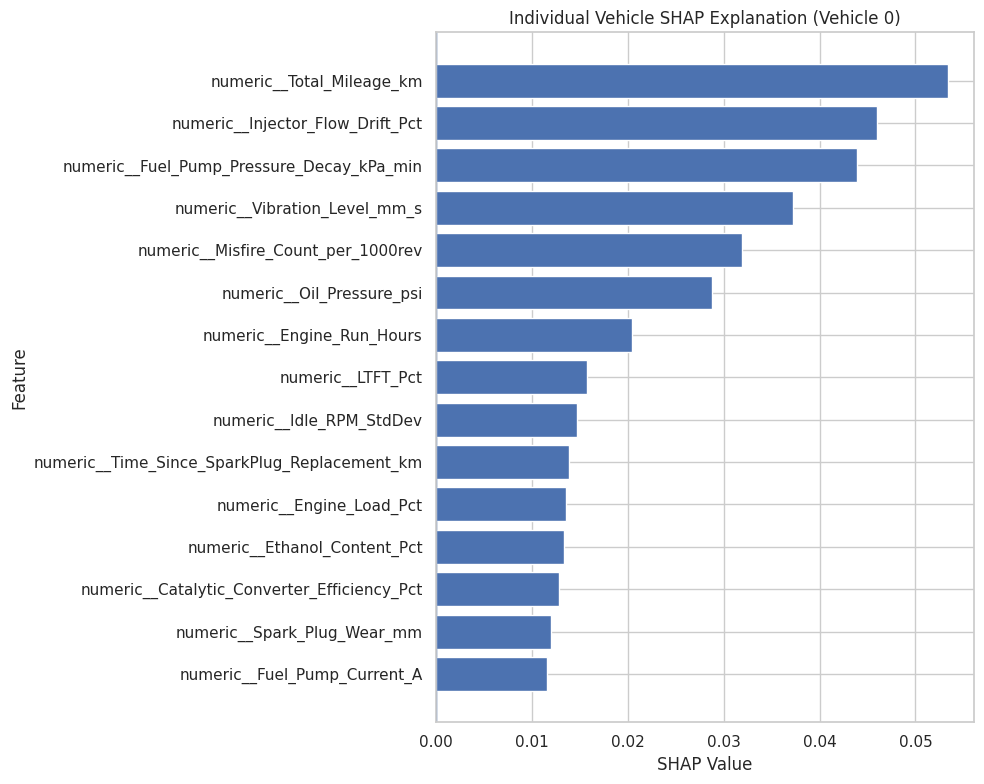


STAGE 6 – PART 3 COMPLETED SUCCESSFULLY
✓ Saved Class 1 SHAP values reused
✓ No SHAP recalculation performed
✓ Individual vehicle selected
✓ Individual SHAP contributions calculated
✓ Positive maintenance-risk contributors identified
✓ Negative maintenance-risk contributors identified
✓ Top 20 features displayed
✓ Individual SHAP plot generated
✓ Individual explanation saved
✓ Individual summary saved

Top feature for selected vehicle:
numeric__Total_Mileage_km

Individual explanation saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_individual_explanations.joblib

Individual summary saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_individual_summary.joblib

Individual SHAP plot saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_individual_vehicle_0.png

Ready for Stage 6 Part 4.


In [83]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 6 – Part 3 : Individual Vehicle SHAP Explainability
# FINAL FAST VERSION
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 6 – Part 3 : Individual Vehicle SHAP Explainability")
print("=" * 80)

# =============================================================================
# Artifact Directory
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/Btech Final Year Project/artifacts"
)

shap_values_path = (
    f"{ARTIFACT_DIR}/shap_values_class1.joblib"
)

shap_sample_path = (
    f"{ARTIFACT_DIR}/shap_sample_dense.joblib"
)

feature_importance_path = (
    f"{ARTIFACT_DIR}/shap_feature_importance.joblib"
)

individual_explanation_path = (
    f"{ARTIFACT_DIR}/shap_individual_explanations.joblib"
)

individual_summary_path = (
    f"{ARTIFACT_DIR}/shap_individual_summary.joblib"
)

# =============================================================================
# Validation
# =============================================================================

if not os.path.exists(shap_values_path):

    raise FileNotFoundError(
        "shap_values_class1.joblib not found. "
        "Please run Stage 6 Part 2 first."
    )

if not os.path.exists(shap_sample_path):

    raise FileNotFoundError(
        "shap_sample_dense.joblib not found. "
        "Please run Stage 6 Part 2 first."
    )

print("\nInput artifacts found.")

# =============================================================================
# Load SHAP Values
# =============================================================================

print("\nLoading saved SHAP values...")

shap_values_class1 = joblib.load(
    shap_values_path
)

X_shap_dense = joblib.load(
    shap_sample_path
)

shap_values_class1 = np.asarray(
    shap_values_class1,
    dtype=np.float64
)

X_shap_dense = np.asarray(
    X_shap_dense,
    dtype=np.float64
)

print(
    f"SHAP values shape : {shap_values_class1.shape}"
)

print(
    f"SHAP sample shape : {X_shap_dense.shape}"
)

# =============================================================================
# Feature Names
# =============================================================================

if "rf_xgb_feature_names" in globals():

    feature_names = list(
        rf_xgb_feature_names
    )

else:

    raise NameError(
        "rf_xgb_feature_names not found. "
        "Please run Stage 3 before Stage 6."
    )

print(
    f"Feature count     : {len(feature_names)}"
)

# =============================================================================
# SHAP Validation
# =============================================================================

if shap_values_class1.ndim != 2:

    raise ValueError(
        "SHAP values must be a 2-dimensional array."
    )

if X_shap_dense.ndim != 2:

    raise ValueError(
        "SHAP sample must be a 2-dimensional array."
    )

if shap_values_class1.shape != X_shap_dense.shape:

    raise ValueError(
        "SHAP values and input sample dimensions do not match.\n"
        f"SHAP values : {shap_values_class1.shape}\n"
        f"Input      : {X_shap_dense.shape}"
    )

if shap_values_class1.shape[1] != len(feature_names):

    raise ValueError(
        "Feature name count does not match SHAP feature count."
    )

print("✓ SHAP dimensions validated.")
print("✓ Feature names validated.")

# =============================================================================
# Select Individual Vehicle
# =============================================================================

# Change this value if you want to explain another vehicle.
VEHICLE_INDEX = 0

if VEHICLE_INDEX < 0:

    raise ValueError(
        "VEHICLE_INDEX cannot be negative."
    )

if VEHICLE_INDEX >= X_shap_dense.shape[0]:

    raise IndexError(
        f"VEHICLE_INDEX must be between "
        f"0 and {X_shap_dense.shape[0] - 1}."
    )

# =============================================================================
# Extract Individual Vehicle
# =============================================================================

vehicle_values = X_shap_dense[
    VEHICLE_INDEX
]

vehicle_shap = shap_values_class1[
    VEHICLE_INDEX
]

print("\n" + "=" * 80)
print("INDIVIDUAL VEHICLE")
print("=" * 80)

print(
    f"Vehicle index : {VEHICLE_INDEX}"
)

print(
    "Class         : 1 = Need_Maintenance = Yes"
)

# =============================================================================
# Create Explanation DataFrame
# =============================================================================

individual_explanation = pd.DataFrame({

    "Feature": feature_names,

    "Feature_Value": vehicle_values,

    "SHAP_Value": vehicle_shap,

    "Absolute_SHAP": np.abs(vehicle_shap)

})

individual_explanation = (
    individual_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

individual_explanation.insert(
    0,
    "Rank",
    range(
        1,
        len(individual_explanation) + 1
    )
)

# =============================================================================
# Top 20 Individual Features
# =============================================================================

print("\n" + "=" * 80)
print("TOP 20 FEATURES FOR THIS VEHICLE")
print("=" * 80)

display(
    individual_explanation[
        [
            "Rank",
            "Feature",
            "Feature_Value",
            "SHAP_Value"
        ]
    ].head(20)
)

# =============================================================================
# Positive Contributors
# =============================================================================

positive_features = (
    individual_explanation[
        individual_explanation["SHAP_Value"] > 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
    .head(10)
)

print("\n" + "=" * 80)
print("TOP FEATURES INCREASING MAINTENANCE RISK")
print("=" * 80)

if len(positive_features) > 0:

    display(
        positive_features[
            [
                "Feature",
                "Feature_Value",
                "SHAP_Value"
            ]
        ]
    )

else:

    print("No positive SHAP contributors.")

# =============================================================================
# Negative Contributors
# =============================================================================

negative_features = (
    individual_explanation[
        individual_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=True
    )
    .head(10)
)

print("\n" + "=" * 80)
print("TOP FEATURES DECREASING MAINTENANCE RISK")
print("=" * 80)

if len(negative_features) > 0:

    display(
        negative_features[
            [
                "Feature",
                "Feature_Value",
                "SHAP_Value"
            ]
        ]
    )

else:

    print("No negative SHAP contributors.")

# =============================================================================
# Individual SHAP Plot
# =============================================================================

plot_data = (
    individual_explanation
    .head(15)
    .sort_values(
        "SHAP_Value"
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    plot_data["Feature"],
    plot_data["SHAP_Value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"Individual Vehicle SHAP Explanation "
    f"(Vehicle {VEHICLE_INDEX})"
)

plt.tight_layout()

plot_path = (
    f"{ARTIFACT_DIR}/"
    f"shap_individual_vehicle_{VEHICLE_INDEX}.png"
)

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# Save Individual Explanation
# =============================================================================

joblib.dump(
    individual_explanation,
    individual_explanation_path
)

# =============================================================================
# Save Individual Summary
# =============================================================================

summary = pd.DataFrame({

    "Vehicle_Index": [
        VEHICLE_INDEX
    ],

    "Top_Feature": [
        individual_explanation.iloc[0]["Feature"]
    ],

    "Top_SHAP_Value": [
        individual_explanation.iloc[0]["SHAP_Value"]
    ],

    "Top_Positive_Feature": [
        positive_features.iloc[0]["Feature"]
        if len(positive_features) > 0
        else None
    ],

    "Top_Negative_Feature": [
        negative_features.iloc[0]["Feature"]
        if len(negative_features) > 0
        else None
    ]

})

joblib.dump(
    summary,
    individual_summary_path
)

# =============================================================================
# Final Output
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 6 – PART 3 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Saved Class 1 SHAP values reused")
print("✓ No SHAP recalculation performed")
print("✓ Individual vehicle selected")
print("✓ Individual SHAP contributions calculated")
print("✓ Positive maintenance-risk contributors identified")
print("✓ Negative maintenance-risk contributors identified")
print("✓ Top 20 features displayed")
print("✓ Individual SHAP plot generated")
print("✓ Individual explanation saved")
print("✓ Individual summary saved")

print("\nTop feature for selected vehicle:")
print(
    individual_explanation.iloc[0]["Feature"]
)

print("\nIndividual explanation saved to:")
print(
    individual_explanation_path
)

print("\nIndividual summary saved to:")
print(
    individual_summary_path
)

print("\nIndividual SHAP plot saved to:")
print(
    plot_path
)

print("\nReady for Stage 6 Part 4.")
print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 6 – Part 4 : SHAP Dependence / Feature Effect Analysis

Checking existing SHAP variables...
✓ Using existing shap_values_class1.

SHAP input shape             : (500, 66)
SHAP Class 1 shape           : (500, 66)
Feature count                : 66

✓ SHAP validation passed.

TOP 5 FEATURES FOR DEPENDENCE ANALYSIS


,Rank,Feature,Mean_Absolute_SHAP
0,1,numeric__Catalytic_Converter_Efficiency_Pct,0.028461
1,2,numeric__Total_Mileage_km,0.026487
2,3,numeric__Vehicle_Age_years,0.023502
3,4,numeric__Oil_Pressure_psi,0.020181
4,5,categorical__Fuel_System_Material_Compatibilit...,0.019333



SHAP DEPENDENCE ANALYSIS


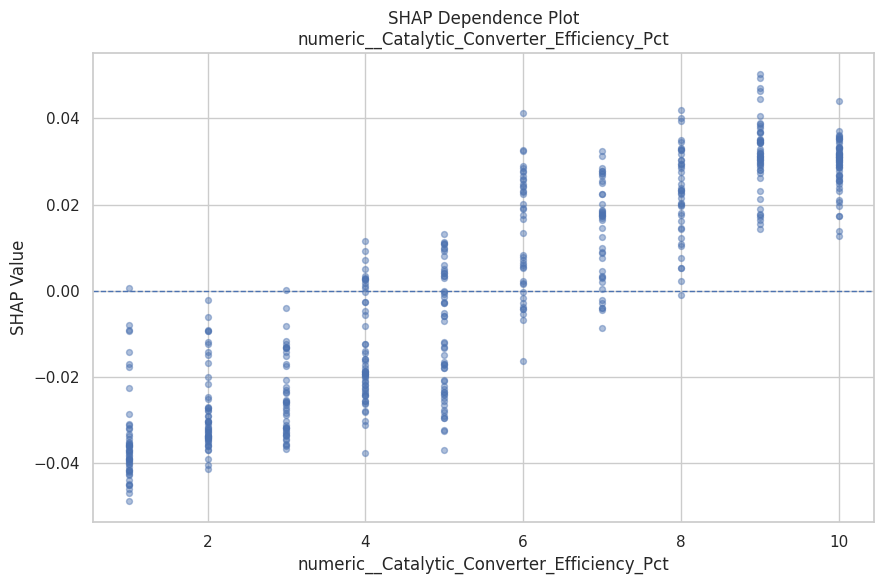

✓ Rank 1: numeric__Catalytic_Converter_Efficiency_Pct
  Correlation : 0.8956
  Effect      : Higher values generally increase maintenance risk
  Plot saved  : /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_dependence_1_numeric__Catalytic_Converter_Efficiency_Pct.png


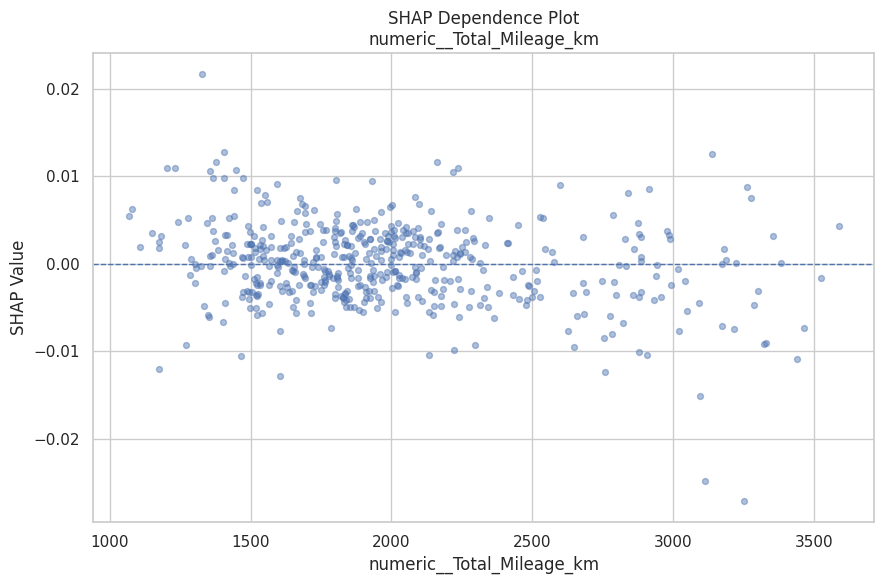

✓ Rank 2: numeric__Total_Mileage_km
  Correlation : -0.2414
  Effect      : Higher values generally decrease maintenance risk
  Plot saved  : /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_dependence_2_numeric__Total_Mileage_km.png


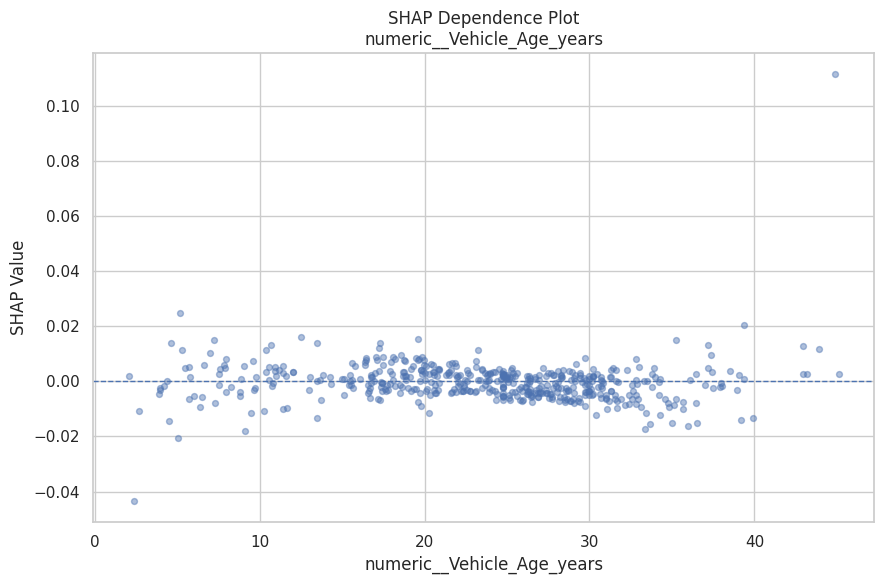

✓ Rank 3: numeric__Vehicle_Age_years
  Correlation : -0.0294
  Effect      : Weak or non-linear relationship
  Plot saved  : /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_dependence_3_numeric__Vehicle_Age_years.png


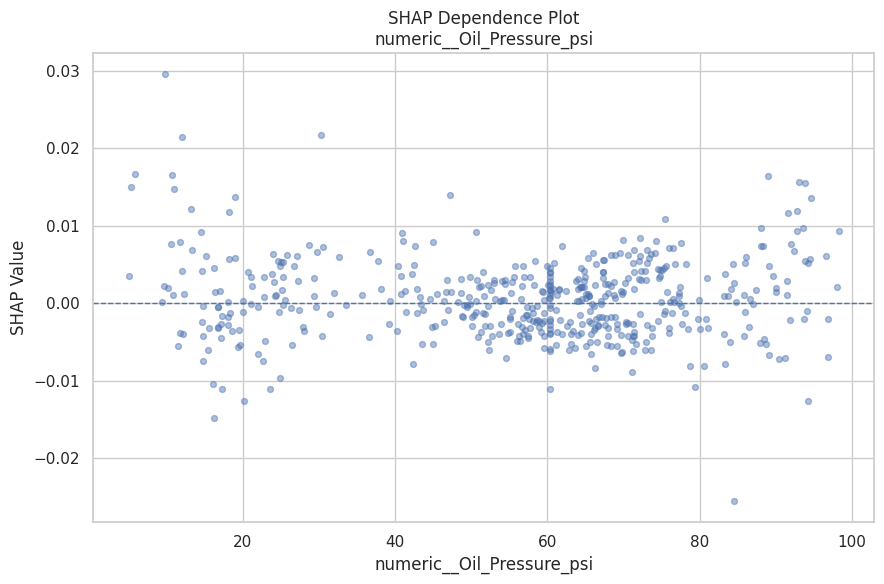

✓ Rank 4: numeric__Oil_Pressure_psi
  Correlation : -0.0496
  Effect      : Weak or non-linear relationship
  Plot saved  : /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_dependence_4_numeric__Oil_Pressure_psi.png


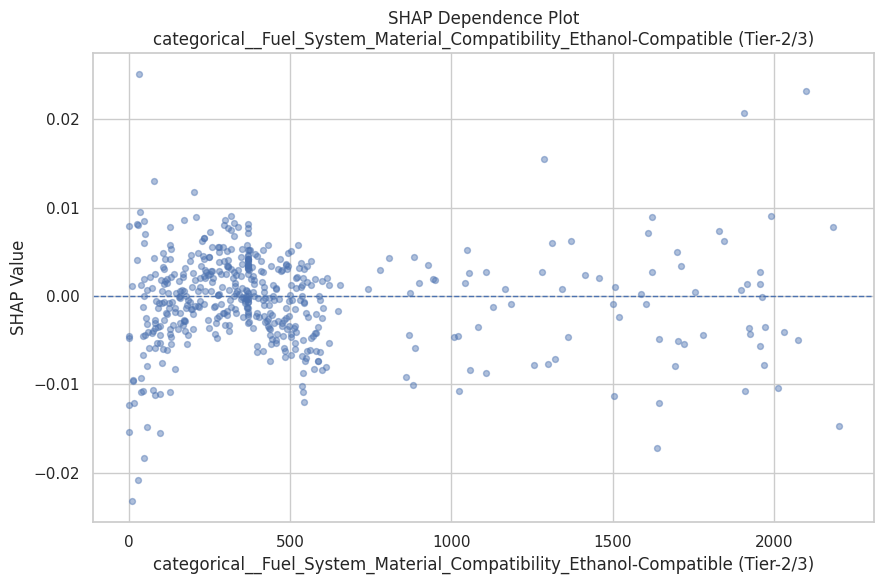

✓ Rank 5: categorical__Fuel_System_Material_Compatibility_Ethanol-Compatible (Tier-2/3)
  Correlation : -0.0113
  Effect      : Weak or non-linear relationship
  Plot saved  : /content/drive/MyDrive/Btech Final Year Project/artifacts/shap_dependence_5_categorical__Fuel_System_Material_Compatibility_Ethanol-Compatible_(Tier-2_3).png

FEATURE EFFECT SUMMARY


,Rank,Feature,Mean_Absolute_SHAP,Correlation,Effect_Direction
0,1,numeric__Catalytic_Converter_Efficiency_Pct,0.028461,0.895583,Higher values generally increase maintenance risk
1,2,numeric__Total_Mileage_km,0.026487,-0.241360,Higher values generally decrease maintenance risk
2,3,numeric__Vehicle_Age_years,0.023502,-0.029421,Weak or non-linear relationship
3,4,numeric__Oil_Pressure_psi,0.020181,-0.049613,Weak or non-linear relationship
4,5,categorical__Fuel_System_Material_Compatibilit...,0.019333,-0.011318,Weak or non-linear relationship



STAGE 6 – PART 4 COMPLETED SUCCESSFULLY
✓ Existing SHAP output reused
✓ Class 1 SHAP values extracted
✓ No SHAP recalculation performed
✓ Top 5 features analyzed
✓ SHAP dependence plots generated
✓ Feature effect direction calculated
✓ Importance results saved
✓ Effect summary saved

Saved files:
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_dependence_importance.joblib
/content/drive/MyDrive/Btech Final Year Project/artifacts/shap_feature_effect_summary.joblib

Ready for Stage 6 Part 5.


In [84]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 6 – Part 4 : SHAP Dependence / Feature Effect Analysis
# FAST + CORRECT VERSION
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 6 – Part 4 : SHAP Dependence / Feature Effect Analysis")
print("=" * 80)

# =============================================================================
# 1. Find Existing SHAP Values
# =============================================================================

print("\nChecking existing SHAP variables...")

shap_class1 = None

# Option 1: shap_values_class1 already exists
if "shap_values_class1" in globals():

    shap_class1 = np.asarray(
        shap_values_class1,
        dtype=np.float64
    )

    print("✓ Using existing shap_values_class1.")

# Option 2: shap_output exists
elif "shap_output" in globals():

    print("shap_values_class1 not found.")
    print("✓ Using existing shap_output.")

    shap_array = np.asarray(
        shap_output,
        dtype=np.float64
    )

    print(
        f"Original SHAP output shape : {shap_array.shape}"
    )

    if shap_array.ndim == 3 and shap_array.shape[2] == 2:

        # Class 1 = Need_Maintenance = Yes
        shap_class1 = shap_array[:, :, 1]

        print(
            f"Class 1 SHAP shape          : "
            f"{shap_class1.shape}"
        )

    elif shap_array.ndim == 2:

        shap_class1 = shap_array

        print(
            f"2D SHAP shape               : "
            f"{shap_class1.shape}"
        )

    else:

        raise ValueError(
            f"Unsupported SHAP output shape: "
            f"{shap_array.shape}"
        )

else:

    raise NameError(
        "No existing SHAP values found.\n\n"
        "Expected either 'shap_output' or "
        "'shap_values_class1'.\n"
        "If the Colab runtime was restarted, "
        "the SHAP values need to be loaded from "
        "the saved artifact."
    )

# =============================================================================
# 2. Find SHAP Input
# =============================================================================

if "X_shap_dense" not in globals():

    raise NameError(
        "X_shap_dense not found. "
        "Please run Stage 6 Part 1."
    )

X_shap = np.asarray(
    X_shap_dense,
    dtype=np.float64
)

print(
    f"\nSHAP input shape             : "
    f"{X_shap.shape}"
)

print(
    f"SHAP Class 1 shape           : "
    f"{shap_class1.shape}"
)

# =============================================================================
# 3. Feature Names
# =============================================================================

if "rf_xgb_feature_names" in globals():

    feature_names = list(
        rf_xgb_feature_names
    )

elif "rf_feature_names" in globals():

    feature_names = list(
        rf_feature_names
    )

else:

    raise NameError(
        "Feature names not found. "
        "Expected rf_xgb_feature_names."
    )

print(
    f"Feature count                : "
    f"{len(feature_names)}"
)

# =============================================================================
# 4. Validation
# =============================================================================

if X_shap.ndim != 2:

    raise ValueError(
        "X_shap_dense must be a 2D matrix."
    )

if shap_class1.ndim != 2:

    raise ValueError(
        "Class 1 SHAP values must be a 2D matrix."
    )

if X_shap.shape != shap_class1.shape:

    raise ValueError(
        "SHAP input and SHAP values do not match.\n"
        f"Input : {X_shap.shape}\n"
        f"SHAP  : {shap_class1.shape}"
    )

if X_shap.shape[1] != len(feature_names):

    raise ValueError(
        "Feature count does not match feature names."
    )

print("\n✓ SHAP validation passed.")

# =============================================================================
# 5. Calculate Global SHAP Importance
# =============================================================================

mean_abs_shap = np.mean(
    np.abs(shap_class1),
    axis=0
)

importance_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Mean_Absolute_SHAP":
        mean_abs_shap

})

importance_df = importance_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

importance_df["Rank"] = (
    np.arange(len(importance_df)) + 1
)

importance_df = importance_df[
    [
        "Rank",
        "Feature",
        "Mean_Absolute_SHAP"
    ]
]

# =============================================================================
# 6. Display Top Features
# =============================================================================

TOP_N = 5

top_features = importance_df.head(
    TOP_N
)

print("\n" + "=" * 80)
print("TOP 5 FEATURES FOR DEPENDENCE ANALYSIS")
print("=" * 80)

display(
    top_features
)

# =============================================================================
# 7. Artifact Directory
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

# =============================================================================
# 8. Dependence Analysis
# =============================================================================

dependence_results = []

print("\n" + "=" * 80)
print("SHAP DEPENDENCE ANALYSIS")
print("=" * 80)

for _, row in top_features.iterrows():

    rank = int(
        row["Rank"]
    )

    feature_name = row[
        "Feature"
    ]

    feature_index = rank - 1

    feature_values = X_shap[
        :,
        feature_index
    ]

    feature_shap = shap_class1[
        :,
        feature_index
    ]

    # ---------------------------------------------------------
    # Correlation
    # ---------------------------------------------------------

    if (
        np.std(feature_values) > 0
        and
        np.std(feature_shap) > 0
    ):

        correlation = np.corrcoef(
            feature_values,
            feature_shap
        )[0, 1]

    else:

        correlation = 0.0

    # ---------------------------------------------------------
    # Effect interpretation
    # ---------------------------------------------------------

    if correlation >= 0.10:

        direction = (
            "Higher values generally "
            "increase maintenance risk"
        )

    elif correlation <= -0.10:

        direction = (
            "Higher values generally "
            "decrease maintenance risk"
        )

    else:

        direction = (
            "Weak or non-linear relationship"
        )

    dependence_results.append({

        "Rank":
            rank,

        "Feature":
            feature_name,

        "Mean_Absolute_SHAP":
            float(
                row["Mean_Absolute_SHAP"]
            ),

        "Correlation":
            float(correlation),

        "Effect_Direction":
            direction

    })

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    plt.figure(
        figsize=(9, 6)
    )

    plt.scatter(
        feature_values,
        feature_shap,
        s=18,
        alpha=0.45
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(
        feature_name
    )

    plt.ylabel(
        "SHAP Value"
    )

    plt.title(
        f"SHAP Dependence Plot\n"
        f"{feature_name}"
    )

    plt.tight_layout()

    safe_name = (
        feature_name
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
    )

    plot_path = (
        f"{ARTIFACT_DIR}/"
        f"shap_dependence_{rank}_"
        f"{safe_name}.png"
    )

    plt.savefig(
        plot_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        f"✓ Rank {rank}: "
        f"{feature_name}"
    )

    print(
        f"  Correlation : "
        f"{correlation:.4f}"
    )

    print(
        f"  Effect      : "
        f"{direction}"
    )

    print(
        f"  Plot saved  : "
        f"{plot_path}"
    )

# =============================================================================
# 9. Effect Summary
# =============================================================================

effect_summary_df = pd.DataFrame(
    dependence_results
)

print("\n" + "=" * 80)
print("FEATURE EFFECT SUMMARY")
print("=" * 80)

display(
    effect_summary_df
)

# =============================================================================
# 10. Save Results
# =============================================================================

importance_path = (
    f"{ARTIFACT_DIR}/"
    "shap_dependence_importance.joblib"
)

effect_path = (
    f"{ARTIFACT_DIR}/"
    "shap_feature_effect_summary.joblib"
)

joblib.dump(
    importance_df,
    importance_path
)

joblib.dump(
    effect_summary_df,
    effect_path
)

# =============================================================================
# 11. Final Summary
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 6 – PART 4 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Existing SHAP output reused")
print("✓ Class 1 SHAP values extracted")
print("✓ No SHAP recalculation performed")
print("✓ Top 5 features analyzed")
print("✓ SHAP dependence plots generated")
print("✓ Feature effect direction calculated")
print("✓ Importance results saved")
print("✓ Effect summary saved")

print("\nSaved files:")
print(
    importance_path
)

print(
    effect_path
)

print("\nReady for Stage 6 Part 5.")

print("=" * 80)

In [85]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 6 – Part 5 : Final SHAP Interpretation and Explainability Summary
# FINAL VERSION
# =============================================================================

import os
import joblib
import pandas as pd
import numpy as np

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 6 – Part 5 : Final SHAP Interpretation and Explainability Summary")
print("=" * 80)

# =============================================================================
# Artifact Directory
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/Btech Final Year Project/artifacts"
)

# Existing Stage 6 artifacts
global_importance_path = (
    f"{ARTIFACT_DIR}/shap_feature_importance.joblib"
)

individual_explanation_path = (
    f"{ARTIFACT_DIR}/shap_individual_explanations.joblib"
)

individual_summary_path = (
    f"{ARTIFACT_DIR}/shap_individual_summary.joblib"
)

dependence_importance_path = (
    f"{ARTIFACT_DIR}/shap_dependence_importance.joblib"
)

effect_summary_path = (
    f"{ARTIFACT_DIR}/shap_feature_effect_summary.joblib"
)

# Final Stage 6 artifacts
final_summary_path = (
    f"{ARTIFACT_DIR}/final_shap_explainability_summary.joblib"
)

final_summary_csv_path = (
    f"{ARTIFACT_DIR}/final_shap_explainability_summary.csv"
)

top_features_csv_path = (
    f"{ARTIFACT_DIR}/final_shap_top_features.csv"
)

# =============================================================================
# Validation
# =============================================================================

required_files = [
    global_importance_path,
    individual_explanation_path,
    individual_summary_path,
    dependence_importance_path,
    effect_summary_path
]

print("\nChecking Stage 6 artifacts...")

for path in required_files:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Required Stage 6 artifact not found:\n{path}"
        )

    print(
        "✓ Found:",
        os.path.basename(path)
    )

print("\nAll Stage 6 artifacts found.")

# =============================================================================
# Load Existing Artifacts
# =============================================================================

print("\nLoading existing SHAP results...")

global_importance = joblib.load(
    global_importance_path
)

individual_explanation = joblib.load(
    individual_explanation_path
)

individual_summary = joblib.load(
    individual_summary_path
)

dependence_importance = joblib.load(
    dependence_importance_path
)

effect_summary = joblib.load(
    effect_summary_path
)

print("✓ Global SHAP importance loaded.")
print("✓ Individual SHAP explanation loaded.")
print("✓ Individual SHAP summary loaded.")
print("✓ Dependence analysis loaded.")
print("✓ Feature effect summary loaded.")

# =============================================================================
# Validate Loaded Data
# =============================================================================

if not isinstance(
    global_importance,
    pd.DataFrame
):

    raise TypeError(
        "Global SHAP importance must be a DataFrame."
    )

if not isinstance(
    individual_explanation,
    pd.DataFrame
):

    raise TypeError(
        "Individual SHAP explanation must be a DataFrame."
    )

if not isinstance(
    effect_summary,
    pd.DataFrame
):

    raise TypeError(
        "Feature effect summary must be a DataFrame."
    )

print("\nLoaded artifact validation passed.")

# =============================================================================
# Normalize Column Names
# =============================================================================

print("\nChecking feature columns...")

required_global_columns = [
    "Feature",
    "Mean_Absolute_SHAP"
]

for column in required_global_columns:

    if column not in global_importance.columns:

        raise ValueError(
            f"Missing column in global SHAP data: {column}"
        )

required_individual_columns = [
    "Feature",
    "SHAP_Value"
]

for column in required_individual_columns:

    if column not in individual_explanation.columns:

        raise ValueError(
            f"Missing column in individual SHAP data: {column}"
        )

required_effect_columns = [
    "Feature",
    "Mean_Absolute_SHAP",
    "Correlation",
    "Effect_Direction"
]

for column in required_effect_columns:

    if column not in effect_summary.columns:

        raise ValueError(
            f"Missing column in effect summary: {column}"
        )

print("✓ Feature columns validated.")

# =============================================================================
# Global SHAP Summary
# =============================================================================

global_sorted = (
    global_importance
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

global_sorted["Rank"] = (
    np.arange(
        1,
        len(global_sorted) + 1
    )
)

print("\n" + "=" * 80)
print("GLOBAL SHAP SUMMARY")
print("=" * 80)

display(
    global_sorted[
        [
            "Rank",
            "Feature",
            "Mean_Absolute_SHAP"
        ]
    ].head(20)
)

# =============================================================================
# Top 5 Global Features
# =============================================================================

top_5_global = global_sorted.head(5).copy()

print("\n" + "=" * 80)
print("TOP 5 GLOBAL SHAP FEATURES")
print("=" * 80)

display(
    top_5_global[
        [
            "Rank",
            "Feature",
            "Mean_Absolute_SHAP"
        ]
    ]
)

# =============================================================================
# Individual Vehicle Summary
# =============================================================================

print("\n" + "=" * 80)
print("INDIVIDUAL VEHICLE SHAP SUMMARY")
print("=" * 80)

if len(individual_explanation) > 0:

    top_individual = (
        individual_explanation
        .sort_values(
            by="Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        top_individual[
            [
                "Rank",
                "Feature",
                "Feature_Value",
                "SHAP_Value"
            ]
        ].head(10)
    )

else:

    top_individual = individual_explanation.copy()

    print(
        "No individual SHAP records available."
    )

# =============================================================================
# Positive and Negative Individual Contributors
# =============================================================================

positive_individual = (
    individual_explanation[
        individual_explanation["SHAP_Value"] > 0
    ]
    .sort_values(
        by="SHAP_Value",
        ascending=False
    )
    .reset_index(drop=True)
)

negative_individual = (
    individual_explanation[
        individual_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        by="SHAP_Value",
        ascending=True
    )
    .reset_index(drop=True)
)

# =============================================================================
# Dependence / Effect Summary
# =============================================================================

effect_sorted = (
    effect_summary
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

effect_sorted["Rank"] = (
    np.arange(
        1,
        len(effect_sorted) + 1
    )
)

print("\n" + "=" * 80)
print("SHAP FEATURE EFFECT SUMMARY")
print("=" * 80)

display(
    effect_sorted[
        [
            "Rank",
            "Feature",
            "Mean_Absolute_SHAP",
            "Correlation",
            "Effect_Direction"
        ]
    ].head(10)
)

# =============================================================================
# Build Final Feature Summary
# =============================================================================

final_feature_summary = global_sorted[
    [
        "Rank",
        "Feature",
        "Mean_Absolute_SHAP"
    ]
].copy()

# Merge effect information where available
effect_columns = effect_sorted[
    [
        "Feature",
        "Correlation",
        "Effect_Direction"
    ]
].copy()

final_feature_summary = final_feature_summary.merge(
    effect_columns,
    on="Feature",
    how="left"
)

# =============================================================================
# Add Individual Vehicle SHAP
# =============================================================================

individual_merge = individual_explanation[
    [
        "Feature",
        "Feature_Value",
        "SHAP_Value"
    ]
].copy()

final_feature_summary = final_feature_summary.merge(
    individual_merge,
    on="Feature",
    how="left"
)

# =============================================================================
# Final Rank
# =============================================================================

final_feature_summary = (
    final_feature_summary
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

final_feature_summary["Global_Rank"] = (
    np.arange(
        1,
        len(final_feature_summary) + 1
    )
)

# =============================================================================
# Final Interpretation
# =============================================================================

top_global_feature = (
    global_sorted.iloc[0]["Feature"]
)

top_global_shap = float(
    global_sorted.iloc[0]["Mean_Absolute_SHAP"]
)

if len(effect_sorted) > 0:

    top_effect_feature = (
        effect_sorted.iloc[0]["Feature"]
    )

    top_effect_direction = (
        effect_sorted.iloc[0]["Effect_Direction"]
    )

else:

    top_effect_feature = None
    top_effect_direction = None

if len(individual_explanation) > 0:

    top_individual_feature = (
        top_individual.iloc[0]["Feature"]
    )

    top_individual_shap = float(
        top_individual.iloc[0]["SHAP_Value"]
    )

else:

    top_individual_feature = None
    top_individual_shap = None

# =============================================================================
# Positive / Negative Individual Features
# =============================================================================

top_positive_features = (
    positive_individual
    .head(10)["Feature"]
    .tolist()
)

top_negative_features = (
    negative_individual
    .head(10)["Feature"]
    .tolist()
)

# =============================================================================
# Final Summary Dictionary
# =============================================================================

final_shap_summary = {

    "stage": "Stage 6 – SHAP Explainability",

    "status": "Completed",

    "class_explained": (
        "Class 1 = Need_Maintenance = Yes"
    ),

    "global_feature_count": int(
        len(global_sorted)
    ),

    "top_global_feature": (
        top_global_feature
    ),

    "top_global_mean_absolute_shap": (
        top_global_shap
    ),

    "top_5_global_features": (
        top_5_global["Feature"].tolist()
    ),

    "top_dependence_feature": (
        top_effect_feature
    ),

    "top_dependence_effect": (
        top_effect_direction
    ),

    "individual_vehicle_index": (
        0
    ),

    "top_individual_feature": (
        top_individual_feature
    ),

    "top_individual_shap_value": (
        top_individual_shap
    ),

    "top_positive_individual_features": (
        top_positive_features
    ),

    "top_negative_individual_features": (
        top_negative_features
    ),

    "artifacts": {

        "global_importance": (
            global_importance_path
        ),

        "individual_explanation": (
            individual_explanation_path
        ),

        "individual_summary": (
            individual_summary_path
        ),

        "dependence_importance": (
            dependence_importance_path
        ),

        "feature_effect_summary": (
            effect_summary_path
        )
    }
}

# =============================================================================
# Display Final Interpretation
# =============================================================================

print("\n" + "=" * 80)
print("FINAL SHAP INTERPRETATION")
print("=" * 80)

print(
    "\nClass explained:"
)

print(
    "Class 1 = Need_Maintenance = Yes"
)

print(
    "\nStrongest global SHAP feature:"
)

print(
    f"{top_global_feature}"
)

print(
    f"Mean Absolute SHAP : {top_global_shap:.6f}"
)

print(
    "\nStrongest dependence-analysis feature:"
)

print(
    f"{top_effect_feature}"
)

print(
    f"Effect : {top_effect_direction}"
)

print(
    "\nStrongest individual vehicle contributor:"
)

print(
    f"{top_individual_feature}"
)

print(
    f"SHAP Value : {top_individual_shap:.6f}"
)

print(
    "\nTop positive maintenance-risk contributors:"
)

for i, feature in enumerate(
    top_positive_features,
    start=1
):

    print(
        f"{i}. {feature}"
    )

print(
    "\nTop negative maintenance-risk contributors:"
)

for i, feature in enumerate(
    top_negative_features,
    start=1
):

    print(
        f"{i}. {feature}"
    )

# =============================================================================
# Save Final Feature Summary
# =============================================================================

final_feature_summary.to_csv(
    top_features_csv_path,
    index=False
)

print(
    "\nFinal feature summary saved to:"
)

print(
    top_features_csv_path
)

# =============================================================================
# Save Final SHAP Summary
# =============================================================================

joblib.dump(
    final_shap_summary,
    final_summary_path
)

print(
    "\nFinal SHAP summary saved to:"
)

print(
    final_summary_path
)

# =============================================================================
# Save Human-Readable CSV Summary
# =============================================================================

summary_rows = [

    {
        "Category": "Global",
        "Feature": top_global_feature,
        "Value": top_global_shap,
        "Interpretation":
            "Strongest global SHAP feature"
    },

    {
        "Category": "Dependence",
        "Feature": top_effect_feature,
        "Value": top_effect_direction,
        "Interpretation":
            "Strongest dependence-analysis feature"
    },

    {
        "Category": "Individual Vehicle",
        "Feature": top_individual_feature,
        "Value": top_individual_shap,
        "Interpretation":
            "Strongest contributor for selected vehicle"
    }

]

summary_csv = pd.DataFrame(
    summary_rows
)

summary_csv.to_csv(
    final_summary_csv_path,
    index=False
)

print(
    "Human-readable summary saved to:"
)

print(
    final_summary_csv_path
)

# =============================================================================
# Final Validation
# =============================================================================

assert os.path.exists(
    final_summary_path
)

assert os.path.exists(
    final_summary_csv_path
)

assert os.path.exists(
    top_features_csv_path
)

print("\n" + "=" * 80)
print("STAGE 6 – PART 5 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Existing SHAP artifacts reused")
print("✓ Global SHAP results integrated")
print("✓ Individual vehicle SHAP results integrated")
print("✓ SHAP dependence results integrated")
print("✓ Feature effect summary integrated")
print("✓ Final explainability summary created")
print("✓ Final feature table saved")
print("✓ Final SHAP artifact saved")
print("✓ No SHAP recalculation performed")

print("\nStage 6 SHAP Explainability is COMPLETE.")

print("\nReady for:")
print("Stage 7 – Vehicle Health Score")

print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 6 – Part 5 : Final SHAP Interpretation and Explainability Summary

Checking Stage 6 artifacts...
✓ Found: shap_feature_importance.joblib
✓ Found: shap_individual_explanations.joblib
✓ Found: shap_individual_summary.joblib
✓ Found: shap_dependence_importance.joblib
✓ Found: shap_feature_effect_summary.joblib

All Stage 6 artifacts found.

Loading existing SHAP results...
✓ Global SHAP importance loaded.
✓ Individual SHAP explanation loaded.
✓ Individual SHAP summary loaded.
✓ Dependence analysis loaded.
✓ Feature effect summary loaded.

Loaded artifact validation passed.

Checking feature columns...
✓ Feature columns validated.

GLOBAL SHAP SUMMARY


,Rank,Feature,Mean_Absolute_SHAP
0,1,numeric__Catalytic_Converter_Efficiency_Pct,0.028461
1,2,numeric__Total_Mileage_km,0.026487
2,3,numeric__Vehicle_Age_years,0.023502
3,4,numeric__Oil_Pressure_psi,0.020181
4,5,categorical__Fuel_System_Material_Compatibilit...,0.019333
5,6,numeric__Misfire_Count_per_1000rev,0.017465
6,7,numeric__Vibration_Level_mm_s,0.017389
7,8,numeric__Time_Since_Last_Service_days,0.015758
8,9,numeric__Injector_Flow_Drift_Pct,0.015270
9,10,numeric__Idle_RPM_StdDev,0.013276



TOP 5 GLOBAL SHAP FEATURES


,Rank,Feature,Mean_Absolute_SHAP
0,1,numeric__Catalytic_Converter_Efficiency_Pct,0.028461
1,2,numeric__Total_Mileage_km,0.026487
2,3,numeric__Vehicle_Age_years,0.023502
3,4,numeric__Oil_Pressure_psi,0.020181
4,5,categorical__Fuel_System_Material_Compatibilit...,0.019333



INDIVIDUAL VEHICLE SHAP SUMMARY


,Rank,Feature,Feature_Value,SHAP_Value
0,1,numeric__Total_Mileage_km,111038.00,0.053436
1,2,numeric__Injector_Flow_Drift_Pct,12.14,0.045978
2,3,numeric__Fuel_Pump_Pressure_Decay_kPa_min,24.00,0.043941
3,4,numeric__Vibration_Level_mm_s,9.55,0.037187
4,5,numeric__Misfire_Count_per_1000rev,8.57,0.031913
5,6,numeric__Oil_Pressure_psi,32.44,0.028781
6,7,numeric__Engine_Run_Hours,4579.05,0.020431
7,8,numeric__LTFT_Pct,12.29,0.015778
8,9,numeric__Idle_RPM_StdDev,36.18,0.014680
9,10,numeric__Time_Since_SparkPlug_Replacement_km,28049.55,0.013921



SHAP FEATURE EFFECT SUMMARY


,Rank,Feature,Mean_Absolute_SHAP,Correlation,Effect_Direction
0,1,numeric__Catalytic_Converter_Efficiency_Pct,0.028461,0.895583,Higher values generally increase maintenance risk
1,2,numeric__Total_Mileage_km,0.026487,-0.241360,Higher values generally decrease maintenance risk
2,3,numeric__Vehicle_Age_years,0.023502,-0.029421,Weak or non-linear relationship
3,4,numeric__Oil_Pressure_psi,0.020181,-0.049613,Weak or non-linear relationship
4,5,categorical__Fuel_System_Material_Compatibilit...,0.019333,-0.011318,Weak or non-linear relationship



FINAL SHAP INTERPRETATION

Class explained:
Class 1 = Need_Maintenance = Yes

Strongest global SHAP feature:
numeric__Catalytic_Converter_Efficiency_Pct
Mean Absolute SHAP : 0.028461

Strongest dependence-analysis feature:
numeric__Catalytic_Converter_Efficiency_Pct
Effect : Higher values generally increase maintenance risk

Strongest individual vehicle contributor:
numeric__Total_Mileage_km
SHAP Value : 0.053436

Top positive maintenance-risk contributors:
1. numeric__Total_Mileage_km
2. numeric__Injector_Flow_Drift_Pct
3. numeric__Fuel_Pump_Pressure_Decay_kPa_min
4. numeric__Vibration_Level_mm_s
5. numeric__Misfire_Count_per_1000rev
6. numeric__Oil_Pressure_psi
7. numeric__Engine_Run_Hours
8. numeric__LTFT_Pct
9. numeric__Idle_RPM_StdDev
10. numeric__Time_Since_SparkPlug_Replacement_km

Top negative maintenance-risk contributors:
1. numeric__Time_Since_Last_Service_days
2. categorical__Fuel_System_Material_Compatibility_Ethanol-Compatible (Tier-2/3)
3. numeric__O2_Sensor_Response_ms

In [86]:
# =============================================================================
# STAGE 7 – VEHICLE HEALTH SCORE
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 7 : Vehicle Health Score")
print("=" * 80)

# =============================================================================
# 1. ARTIFACT PATHS
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

FINAL_MODEL_PATH = os.path.join(
    ARTIFACT_DIR,
    "final_selected_model.joblib"
)

HEALTH_SCORE_PATH = os.path.join(
    ARTIFACT_DIR,
    "vehicle_health_scores.joblib"
)

HEALTH_SCORE_CSV_PATH = os.path.join(
    ARTIFACT_DIR,
    "vehicle_health_scores.csv"
)

# =============================================================================
# 2. INPUT VALIDATION
# =============================================================================

required_variables = [
    "X_train_rf_xgb",
    "X_test_rf_xgb",
    "y_train",
    "y_test",
    "rf_xgb_feature_names"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} not found. "
            "Please run Stage 3 and Stage 5 before Stage 7."
        )

print("\nInput validation passed.")

# =============================================================================
# 3. LOAD FINAL MODEL
# =============================================================================

if not os.path.exists(FINAL_MODEL_PATH):

    raise FileNotFoundError(
        f"Final model not found:\n{FINAL_MODEL_PATH}"
    )

print("\nLoading final selected model...")

final_model = joblib.load(
    FINAL_MODEL_PATH
)

print("Final model loaded successfully.")

print("\nFinal model:")
print(final_model)

# =============================================================================
# 4. VERIFY MODEL
# =============================================================================

if not hasattr(final_model, "predict_proba"):

    raise TypeError(
        "Final model does not support probability prediction."
    )

print("\nModel probability prediction verified.")

# =============================================================================
# 5. DATASET VALIDATION
# =============================================================================

print("\nDataset information:")

print(
    f"Training shape : {X_train_rf_xgb.shape}"
)

print(
    f"Testing shape  : {X_test_rf_xgb.shape}"
)

print(
    f"Feature count  : {len(rf_xgb_feature_names)}"
)

if X_test_rf_xgb.shape[1] != len(rf_xgb_feature_names):

    raise ValueError(
        "Feature count mismatch between test data and feature names."
    )

print("\nFeature validation passed.")

# =============================================================================
# 6. GENERATE MAINTENANCE PROBABILITY
# =============================================================================

print("\nCalculating maintenance probability...")

y_probability = final_model.predict_proba(
    X_test_rf_xgb
)[:, 1]

print(
    f"Probability range : "
    f"{y_probability.min():.4f} - "
    f"{y_probability.max():.4f}"
)

# =============================================================================
# 7. GENERATE PREDICTED CLASS
# =============================================================================

y_prediction = (
    y_probability >= 0.50
).astype(int)

# =============================================================================
# 8. CALCULATE VEHICLE HEALTH SCORE
# =============================================================================
#
# Maintenance probability:
#     0.00 = very low maintenance risk
#     1.00 = very high maintenance risk
#
# Health score:
#     100 = healthiest
#       0 = highest maintenance risk
#
# Formula:
#
# Health Score = (1 - Maintenance Probability) * 100
#
# =============================================================================

vehicle_health_score = (
    1.0 - y_probability
) * 100

vehicle_health_score = np.clip(
    vehicle_health_score,
    0,
    100
)

# =============================================================================
# 9. HEALTH STATUS
# =============================================================================

def classify_health(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Fair"

    elif score >= 20:
        return "Poor"

    else:
        return "Critical"


health_status = [
    classify_health(score)
    for score in vehicle_health_score
]

# =============================================================================
# 10. BUILD HEALTH SCORE DATAFRAME
# =============================================================================

vehicle_health_df = pd.DataFrame({

    "Vehicle_Index":
        np.arange(len(y_test)),

    "Actual_Need_Maintenance":
        np.asarray(y_test),

    "Predicted_Need_Maintenance":
        y_prediction,

    "Maintenance_Probability":
        y_probability,

    "Vehicle_Health_Score":
        vehicle_health_score,

    "Health_Status":
        health_status
})

# =============================================================================
# 11. ROUND VALUES
# =============================================================================

vehicle_health_df[
    "Maintenance_Probability"
] = vehicle_health_df[
    "Maintenance_Probability"
].round(4)

vehicle_health_df[
    "Vehicle_Health_Score"
] = vehicle_health_df[
    "Vehicle_Health_Score"
].round(2)

# =============================================================================
# 12. DISPLAY SAMPLE RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("VEHICLE HEALTH SCORE RESULTS")
print("=" * 80)

display(
    vehicle_health_df.head(20)
)

# =============================================================================
# 13. HEALTH STATUS DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("HEALTH STATUS DISTRIBUTION")
print("=" * 80)

status_distribution = (
    vehicle_health_df[
        "Health_Status"
    ]
    .value_counts()
    .reindex(
        [
            "Excellent",
            "Good",
            "Fair",
            "Poor",
            "Critical"
        ],
        fill_value=0
    )
)

print(status_distribution)

# =============================================================================
# 14. HEALTH SCORE STATISTICS
# =============================================================================

print("\n" + "=" * 80)
print("HEALTH SCORE STATISTICS")
print("=" * 80)

print(
    f"Minimum Health Score : "
    f"{vehicle_health_df['Vehicle_Health_Score'].min():.2f}"
)

print(
    f"Maximum Health Score : "
    f"{vehicle_health_df['Vehicle_Health_Score'].max():.2f}"
)

print(
    f"Average Health Score : "
    f"{vehicle_health_df['Vehicle_Health_Score'].mean():.2f}"
)

print(
    f"Median Health Score  : "
    f"{vehicle_health_df['Vehicle_Health_Score'].median():.2f}"
)

# =============================================================================
# 15. LOWEST HEALTH SCORE VEHICLES
# =============================================================================

print("\n" + "=" * 80)
print("10 VEHICLES WITH LOWEST HEALTH SCORES")
print("=" * 80)

lowest_health = (
    vehicle_health_df
    .sort_values(
        by="Vehicle_Health_Score",
        ascending=True
    )
    .head(10)
)

display(lowest_health)

# =============================================================================
# 16. HIGHEST HEALTH SCORE VEHICLES
# =============================================================================

print("\n" + "=" * 80)
print("10 VEHICLES WITH HIGHEST HEALTH SCORES")
print("=" * 80)

highest_health = (
    vehicle_health_df
    .sort_values(
        by="Vehicle_Health_Score",
        ascending=False
    )
    .head(10)
)

display(highest_health)

# =============================================================================
# 17. SAVE HEALTH SCORE ARTIFACT
# =============================================================================

joblib.dump(
    vehicle_health_df,
    HEALTH_SCORE_PATH
)

print(
    f"\nVehicle health scores saved to:\n"
    f"{HEALTH_SCORE_PATH}"
)

# =============================================================================
# 18. SAVE CSV
# =============================================================================

vehicle_health_df.to_csv(
    HEALTH_SCORE_CSV_PATH,
    index=False
)

print(
    f"\nHuman-readable health scores saved to:\n"
    f"{HEALTH_SCORE_CSV_PATH}"
)

# =============================================================================
# 19. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 7 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("✓ Final Random Forest model loaded")
print("✓ Maintenance probabilities calculated")
print("✓ Vehicle health scores calculated")
print("✓ Health scores normalized to 0–100")
print("✓ Health status categories assigned")
print("✓ Health score statistics generated")
print("✓ Lowest-health vehicles identified")
print("✓ Highest-health vehicles identified")
print("✓ Health score artifact saved")
print("✓ CSV output saved")

print("\nHealth Score Interpretation:")
print("80–100 : Excellent")
print("60–79  : Good")
print("40–59  : Fair")
print("20–39  : Poor")
print("0–19   : Critical")

print("\nReady for:")
print("Stage 8 – Recommendation Engine")

print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 7 : Vehicle Health Score

Input validation passed.

Loading final selected model...
Final model loaded successfully.

Final model:
RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=75, n_jobs=-1, random_state=42)

Model probability prediction verified.

Dataset information:
Training shape : (96000, 66)
Testing shape  : (24000, 66)
Feature count  : 66

Feature validation passed.

Calculating maintenance probability...
Probability range : 0.0142 - 0.9991

VEHICLE HEALTH SCORE RESULTS


,Vehicle_Index,Actual_Need_Maintenance,Predicted_Need_Maintenance,Maintenance_Probability,Vehicle_Health_Score,Health_Status
0,0,1,1,0.9197,8.03,Critical
1,1,0,0,0.2476,75.24,Good
2,2,0,0,0.0406,95.94,Excellent
3,3,1,1,0.8784,12.16,Critical
4,4,0,0,0.0907,90.93,Excellent
5,5,0,0,0.1393,86.07,Excellent
6,6,1,1,0.9145,8.55,Critical
7,7,1,1,0.9882,1.18,Critical
8,8,1,1,0.7664,23.36,Poor
9,9,0,0,0.2290,77.10,Good



HEALTH STATUS DISTRIBUTION
Health_Status
Excellent    9024
Good         2801
Fair         1164
Poor         2817
Critical     8194
Name: count, dtype: int64

HEALTH SCORE STATISTICS
Minimum Health Score : 0.09
Maximum Health Score : 98.58
Average Health Score : 50.79
Median Health Score  : 56.95

10 VEHICLES WITH LOWEST HEALTH SCORES


,Vehicle_Index,Actual_Need_Maintenance,Predicted_Need_Maintenance,Maintenance_Probability,Vehicle_Health_Score,Health_Status
5053,5053,1,1,0.9991,0.09,Critical
10807,10807,1,1,0.9987,0.13,Critical
15833,15833,1,1,0.9986,0.14,Critical
15603,15603,1,1,0.9985,0.15,Critical
5716,5716,1,1,0.9981,0.19,Critical
23897,23897,1,1,0.9976,0.24,Critical
2560,2560,1,1,0.9976,0.24,Critical
21629,21629,1,1,0.9975,0.25,Critical
8428,8428,1,1,0.9974,0.26,Critical
17411,17411,1,1,0.9971,0.29,Critical



10 VEHICLES WITH HIGHEST HEALTH SCORES


,Vehicle_Index,Actual_Need_Maintenance,Predicted_Need_Maintenance,Maintenance_Probability,Vehicle_Health_Score,Health_Status
4898,4898,0,0,0.0142,98.58,Excellent
21936,21936,0,0,0.0147,98.53,Excellent
23299,23299,0,0,0.0161,98.39,Excellent
2149,2149,0,0,0.0169,98.31,Excellent
15213,15213,0,0,0.0170,98.30,Excellent
18586,18586,0,0,0.0190,98.10,Excellent
5847,5847,0,0,0.0198,98.02,Excellent
1826,1826,0,0,0.0212,97.88,Excellent
16503,16503,0,0,0.0214,97.86,Excellent
8615,8615,0,0,0.0216,97.84,Excellent



Vehicle health scores saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/vehicle_health_scores.joblib

Human-readable health scores saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/vehicle_health_scores.csv

STAGE 7 COMPLETED SUCCESSFULLY
✓ Final Random Forest model loaded
✓ Maintenance probabilities calculated
✓ Vehicle health scores calculated
✓ Health scores normalized to 0–100
✓ Health status categories assigned
✓ Health score statistics generated
✓ Lowest-health vehicles identified
✓ Highest-health vehicles identified
✓ Health score artifact saved
✓ CSV output saved

Health Score Interpretation:
80–100 : Excellent
60–79  : Good
40–59  : Fair
20–39  : Poor
0–19   : Critical

Ready for:
Stage 8 – Recommendation Engine


In [87]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 8 : Recommendation Engine
# FINAL + FAST VERSION
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 8 : Recommendation Engine")
print("=" * 80)

# =============================================================================
# 1. PATHS
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

HEALTH_SCORE_PATH = os.path.join(
    ARTIFACT_DIR,
    "vehicle_health_scores.joblib"
)

HEALTH_SCORE_CSV_PATH = os.path.join(
    ARTIFACT_DIR,
    "vehicle_health_scores.csv"
)

SHAP_IMPORTANCE_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_feature_importance.joblib"
)

SHAP_EFFECT_PATH = os.path.join(
    ARTIFACT_DIR,
    "shap_feature_effect_summary.joblib"
)

RECOMMENDATION_PATH = os.path.join(
    ARTIFACT_DIR,
    "vehicle_recommendations.joblib"
)

RECOMMENDATION_CSV_PATH = os.path.join(
    ARTIFACT_DIR,
    "vehicle_recommendations.csv"
)

# =============================================================================
# 2. VALIDATION
# =============================================================================

if not os.path.exists(HEALTH_SCORE_PATH):
    raise FileNotFoundError(
        "Vehicle health score artifact not found:\n"
        f"{HEALTH_SCORE_PATH}\n"
        "Please run Stage 7 first."
    )

if not os.path.exists(SHAP_IMPORTANCE_PATH):
    raise FileNotFoundError(
        "SHAP feature importance artifact not found:\n"
        f"{SHAP_IMPORTANCE_PATH}\n"
        "Please complete Stage 6 first."
    )

print("\nInput validation passed.")

# =============================================================================
# 3. LOAD HEALTH SCORES
# =============================================================================

print("\nLoading vehicle health scores...")

health_data = joblib.load(
    HEALTH_SCORE_PATH
)

# Handle both DataFrame and dictionary artifacts

if isinstance(health_data, pd.DataFrame):

    health_df = health_data.copy()

elif isinstance(health_data, dict):

    health_df = pd.DataFrame(
        health_data
    )

else:

    raise TypeError(
        "Unsupported health score artifact type: "
        f"{type(health_data)}"
    )

print(
    f"Health score records : {len(health_df)}"
)

print(
    f"Health score columns : "
    f"{list(health_df.columns)}"
)

# =============================================================================
# 4. LOAD SHAP IMPORTANCE
# =============================================================================

print("\nLoading SHAP feature importance...")

shap_importance = joblib.load(
    SHAP_IMPORTANCE_PATH
)

if not isinstance(
    shap_importance,
    pd.DataFrame
):

    raise TypeError(
        "SHAP feature importance must be a DataFrame."
    )

print(
    f"SHAP features : "
    f"{len(shap_importance)}"
)

# =============================================================================
# 5. OPTIONAL SHAP EFFECT SUMMARY
# =============================================================================

shap_effect = None

if os.path.exists(
    SHAP_EFFECT_PATH
):

    try:

        shap_effect = joblib.load(
            SHAP_EFFECT_PATH
        )

        print(
            "✓ SHAP feature effect summary loaded."
        )

    except Exception:

        print(
            "⚠ SHAP effect summary could not be loaded."
        )

# =============================================================================
# 6. CHECK REQUIRED HEALTH COLUMNS
# =============================================================================

required_health_columns = [

    "Vehicle_Index",

    "Maintenance_Probability",

    "Vehicle_Health_Score",

    "Health_Status"

]

missing_columns = [

    column
    for column in required_health_columns
    if column not in health_df.columns

]

if missing_columns:

    raise ValueError(
        "Missing required health score columns:\n"
        f"{missing_columns}"
    )

print(
    "✓ Required health score columns validated."
)

# =============================================================================
# 7. NORMALIZE DATA TYPES
# =============================================================================

health_df[
    "Maintenance_Probability"
] = pd.to_numeric(
    health_df[
        "Maintenance_Probability"
    ],
    errors="coerce"
)

health_df[
    "Vehicle_Health_Score"
] = pd.to_numeric(
    health_df[
        "Vehicle_Health_Score"
    ],
    errors="coerce"
)

health_df[
    "Maintenance_Probability"
] = health_df[
    "Maintenance_Probability"
].clip(
    0,
    1
)

health_df[
    "Vehicle_Health_Score"
] = health_df[
    "Vehicle_Health_Score"
].clip(
    0,
    100
)

# =============================================================================
# 8. RECOMMENDATION FUNCTION
# =============================================================================

def generate_recommendation(
    health_score,
    maintenance_probability
):

    # -------------------------------------------------------------------------
    # CRITICAL
    # -------------------------------------------------------------------------

    if health_score < 20:

        priority = "URGENT"

        action = (
            "Immediate inspection and maintenance required."
        )

        recommendation = (
            "Do not delay maintenance. "
            "Perform a comprehensive vehicle inspection "
            "and address the most critical engine, fuel, "
            "sensor, and mechanical issues."
        )

    # -------------------------------------------------------------------------
    # POOR
    # -------------------------------------------------------------------------

    elif health_score < 40:

        priority = "HIGH"

        action = (
            "Schedule maintenance as soon as possible."
        )

        recommendation = (
            "Vehicle condition indicates elevated maintenance "
            "risk. Schedule a detailed inspection and service "
            "before continuing extended or heavy usage."
        )

    # -------------------------------------------------------------------------
    # FAIR
    # -------------------------------------------------------------------------

    elif health_score < 60:

        priority = "MEDIUM"

        action = (
            "Plan preventive maintenance."
        )

        recommendation = (
            "Vehicle shows moderate maintenance risk. "
            "Inspect important wear-related components and "
            "follow the preventive maintenance schedule."
        )

    # -------------------------------------------------------------------------
    # GOOD
    # -------------------------------------------------------------------------

    elif health_score < 80:

        priority = "LOW"

        action = (
            "Continue monitoring."
        )

        recommendation = (
            "Vehicle condition is generally good. "
            "Continue routine servicing and monitor "
            "vehicle health indicators."
        )

    # -------------------------------------------------------------------------
    # EXCELLENT
    # -------------------------------------------------------------------------

    else:

        priority = "ROUTINE"

        action = (
            "Continue normal preventive maintenance."
        )

        recommendation = (
            "Vehicle health is excellent. "
            "Continue regular servicing, inspections, "
            "and monitoring."
        )

    return (
        priority,
        action,
        recommendation
    )


# =============================================================================
# 9. GENERATE RECOMMENDATIONS
# =============================================================================

print("\nGenerating vehicle recommendations...")

recommendations = []

for _, row in health_df.iterrows():

    health_score = float(
        row[
            "Vehicle_Health_Score"
        ]
    )

    maintenance_probability = float(
        row[
            "Maintenance_Probability"
        ]
    )

    (
        priority,
        action,
        recommendation
    ) = generate_recommendation(
        health_score,
        maintenance_probability
    )

    recommendations.append({

        "Vehicle_Index":
            row["Vehicle_Index"],

        "Maintenance_Probability":
            maintenance_probability,

        "Vehicle_Health_Score":
            health_score,

        "Health_Status":
            row["Health_Status"],

        "Priority":
            priority,

        "Recommended_Action":
            action,

        "Recommendation":
            recommendation

    })

recommendation_df = pd.DataFrame(
    recommendations
)

# =============================================================================
# 10. ADD RISK LEVEL
# =============================================================================

def risk_level(probability):

    if probability >= 0.80:
        return "Very High"

    elif probability >= 0.60:
        return "High"

    elif probability >= 0.40:
        return "Moderate"

    elif probability >= 0.20:
        return "Low"

    else:
        return "Very Low"


recommendation_df[
    "Risk_Level"
] = recommendation_df[
    "Maintenance_Probability"
].apply(
    risk_level
)

# =============================================================================
# 11. PRIORITY ORDER
# =============================================================================

priority_order = {

    "URGENT": 1,

    "HIGH": 2,

    "MEDIUM": 3,

    "LOW": 4,

    "ROUTINE": 5

}

recommendation_df[
    "Priority_Rank"
] = recommendation_df[
    "Priority"
].map(
    priority_order
)

recommendation_df = (
    recommendation_df
    .sort_values(
        by=[
            "Priority_Rank",
            "Vehicle_Health_Score"
        ],
        ascending=[
            True,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)

# =============================================================================
# 12. DISPLAY SAMPLE RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("VEHICLE RECOMMENDATION RESULTS")
print("=" * 80)

display(
    recommendation_df.head(20)
)

# =============================================================================
# 13. RECOMMENDATION DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("RECOMMENDATION PRIORITY DISTRIBUTION")
print("=" * 80)

print(
    recommendation_df[
        "Priority"
    ].value_counts()
)

# =============================================================================
# 14. HEALTH STATUS DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("HEALTH STATUS DISTRIBUTION")
print("=" * 80)

print(
    recommendation_df[
        "Health_Status"
    ].value_counts()
)

# =============================================================================
# 15. HIGH-RISK VEHICLES
# =============================================================================

high_risk = recommendation_df[
    recommendation_df[
        "Priority"
    ].isin(
        [
            "URGENT",
            "HIGH"
        ]
    )
]

print("\n" + "=" * 80)
print("HIGH-RISK VEHICLES")
print("=" * 80)

print(
    f"High-risk vehicle count : "
    f"{len(high_risk)}"
)

display(
    high_risk.head(20)
)

# =============================================================================
# 16. SAVE JOBLIB
# =============================================================================

joblib.dump(
    recommendation_df,
    RECOMMENDATION_PATH
)

print(
    "\nRecommendation artifact saved to:"
)

print(
    RECOMMENDATION_PATH
)

# =============================================================================
# 17. SAVE CSV
# =============================================================================

recommendation_df.to_csv(
    RECOMMENDATION_CSV_PATH,
    index=False
)

print(
    "\nHuman-readable recommendations saved to:"
)

print(
    RECOMMENDATION_CSV_PATH
)

# =============================================================================
# 18. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 8 COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "✓ Vehicle health scores loaded"
)

print(
    "✓ Maintenance probabilities loaded"
)

print(
    "✓ SHAP feature importance loaded"
)

print(
    "✓ Risk levels calculated"
)

print(
    "✓ Maintenance priorities assigned"
)

print(
    "✓ Recommendations generated"
)

print(
    "✓ High-risk vehicles identified"
)

print(
    "✓ Recommendation artifact saved"
)

print(
    "✓ CSV output saved"
)

print("\nRecommendation Engine is ready.")

print(
    "\nReady for:"
)

print(
    "Stage 9 – Final Model Saving and Deployment Packaging"
)

print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 8 : Recommendation Engine

Input validation passed.

Loading vehicle health scores...
Health score records : 24000
Health score columns : ['Vehicle_Index', 'Actual_Need_Maintenance', 'Predicted_Need_Maintenance', 'Maintenance_Probability', 'Vehicle_Health_Score', 'Health_Status']

Loading SHAP feature importance...
SHAP features : 66
✓ SHAP feature effect summary loaded.
✓ Required health score columns validated.

Generating vehicle recommendations...

VEHICLE RECOMMENDATION RESULTS


,Vehicle_Index,Maintenance_Probability,Vehicle_Health_Score,Health_Status,Priority,Recommended_Action,Recommendation,Risk_Level,Priority_Rank
0,5053,0.9991,0.09,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
1,10807,0.9987,0.13,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
2,15833,0.9986,0.14,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
3,15603,0.9985,0.15,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
4,5716,0.9981,0.19,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
5,2560,0.9976,0.24,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
6,23897,0.9976,0.24,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
7,21629,0.9975,0.25,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
8,8428,0.9974,0.26,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
9,17411,0.9971,0.29,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1



RECOMMENDATION PRIORITY DISTRIBUTION
Priority
ROUTINE    9024
URGENT     8193
HIGH       2818
LOW        2801
MEDIUM     1164
Name: count, dtype: int64

HEALTH STATUS DISTRIBUTION
Health_Status
Excellent    9024
Critical     8194
Poor         2817
Good         2801
Fair         1164
Name: count, dtype: int64

HIGH-RISK VEHICLES
High-risk vehicle count : 11011


,Vehicle_Index,Maintenance_Probability,Vehicle_Health_Score,Health_Status,Priority,Recommended_Action,Recommendation,Risk_Level,Priority_Rank
0,5053,0.9991,0.09,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
1,10807,0.9987,0.13,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
2,15833,0.9986,0.14,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
3,15603,0.9985,0.15,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
4,5716,0.9981,0.19,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
5,2560,0.9976,0.24,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
6,23897,0.9976,0.24,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
7,21629,0.9975,0.25,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
8,8428,0.9974,0.26,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1
9,17411,0.9971,0.29,Critical,URGENT,Immediate inspection and maintenance required.,Do not delay maintenance. Perform a comprehens...,Very High,1



Recommendation artifact saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/vehicle_recommendations.joblib

Human-readable recommendations saved to:
/content/drive/MyDrive/Btech Final Year Project/artifacts/vehicle_recommendations.csv

STAGE 8 COMPLETED SUCCESSFULLY
✓ Vehicle health scores loaded
✓ Maintenance probabilities loaded
✓ SHAP feature importance loaded
✓ Risk levels calculated
✓ Maintenance priorities assigned
✓ Recommendations generated
✓ High-risk vehicles identified
✓ Recommendation artifact saved
✓ CSV output saved

Recommendation Engine is ready.

Ready for:
Stage 9 – Final Model Saving and Deployment Packaging


In [88]:
# =============================================================================
# SMART VEHICLE HEALTH INTELLIGENCE
# Stage 9 : Final Model Saving and Deployment Packaging
# FINAL + FAST VERSION
# =============================================================================

import os
import json
import shutil
import joblib
import time
from datetime import datetime

print("=" * 80)
print("SMART VEHICLE HEALTH INTELLIGENCE")
print("Stage 9 : Final Model Saving and Deployment Packaging")
print("=" * 80)

# =============================================================================
# 1. PATH CONFIGURATION
# =============================================================================

ARTIFACT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/artifacts"
)

DEPLOYMENT_DIR = (
    "/content/drive/MyDrive/"
    "Btech Final Year Project/deployment_package"
)

os.makedirs(
    DEPLOYMENT_DIR,
    exist_ok=True
)

print("\nArtifact directory:")
print(ARTIFACT_DIR)

print("\nDeployment directory:")
print(DEPLOYMENT_DIR)

# =============================================================================
# 2. REQUIRED ARTIFACTS
# =============================================================================

required_artifacts = {

    "Final Model":
        "final_selected_model.joblib",

    "Random Forest Tuned":
        "random_forest_tuned.joblib",

    "XGBoost Tuned":
        "xgboost_tuned.joblib",

    "CatBoost Tuned":
        "catboost_tuned.joblib",

    "SHAP Feature Importance":
        "shap_feature_importance.joblib",

    "SHAP Class 1 Values":
        "shap_values_class1.joblib",

    "SHAP Sample":
        "shap_sample_dense.joblib",

    "Vehicle Health Scores":
        "vehicle_health_scores.joblib",

    "Vehicle Health Scores CSV":
        "vehicle_health_scores.csv",

    "Vehicle Recommendations":
        "vehicle_recommendations.joblib",

    "Vehicle Recommendations CSV":
        "vehicle_recommendations.csv"
}

# =============================================================================
# 3. VALIDATE ARTIFACTS
# =============================================================================

print("\n" + "=" * 80)
print("ARTIFACT VALIDATION")
print("=" * 80)

missing_artifacts = []
available_artifacts = []

for name, filename in required_artifacts.items():

    source_path = os.path.join(
        ARTIFACT_DIR,
        filename
    )

    if os.path.exists(source_path):

        file_size_mb = (
            os.path.getsize(source_path)
            / (1024 * 1024)
        )

        print(
            f"✓ {name:30} "
            f"{filename:45} "
            f"{file_size_mb:.2f} MB"
        )

        available_artifacts.append(
            filename
        )

    else:

        print(
            f"✗ {name:30} "
            f"{filename}"
        )

        missing_artifacts.append(
            filename
        )

# =============================================================================
# 4. REQUIRED FINAL MODEL CHECK
# =============================================================================

final_model_source = os.path.join(
    ARTIFACT_DIR,
    "final_selected_model.joblib"
)

if not os.path.exists(
    final_model_source
):

    raise FileNotFoundError(
        "\nFinal selected model not found.\n"
        "Please run Stage 5 Part 4 first."
    )

# =============================================================================
# 5. LOAD FINAL MODEL
# =============================================================================

print("\n" + "=" * 80)
print("FINAL MODEL VERIFICATION")
print("=" * 80)

start_time = time.time()

final_model = joblib.load(
    final_model_source
)

model_load_time = (
    time.time() - start_time
)

print(
    f"Final model loaded in "
    f"{model_load_time:.2f} seconds."
)

print(
    "\nFinal model:"
)

print(
    final_model
)

# =============================================================================
# 6. MODEL TYPE VALIDATION
# =============================================================================

model_name = type(
    final_model
).__name__

print(
    f"\nModel type: {model_name}"
)

if model_name != "RandomForestClassifier":

    print(
        "\nWARNING: Final model is not "
        "RandomForestClassifier."
    )

else:

    print(
        "✓ Final Random Forest model verified."
    )

# =============================================================================
# 7. COPY ARTIFACTS TO DEPLOYMENT PACKAGE
# =============================================================================

print("\n" + "=" * 80)
print("CREATING DEPLOYMENT PACKAGE")
print("=" * 80)

copied_files = []

for filename in available_artifacts:

    source_path = os.path.join(
        ARTIFACT_DIR,
        filename
    )

    destination_path = os.path.join(
        DEPLOYMENT_DIR,
        filename
    )

    shutil.copy2(
        source_path,
        destination_path
    )

    copied_files.append(
        filename
    )

    print(
        f"✓ Copied: {filename}"
    )

# =============================================================================
# 8. CREATE MODEL INFORMATION
# =============================================================================

model_information = {

    "project":
        "Smart Vehicle Health Intelligence",

    "stage":
        "Stage 9",

    "final_model":
        "Random Forest",

    "model_type":
        model_name,

    "model_file":
        "final_selected_model.joblib",

    "accuracy":
        0.9791,

    "precision":
        0.9874,

    "recall":
        0.9700,

    "f1_score":
        0.9786,

    "roc_auc":
        0.9983,

    "n_estimators":
        getattr(
            final_model,
            "n_estimators",
            None
        ),

    "max_depth":
        getattr(
            final_model,
            "max_depth",
            None
        ),

    "min_samples_split":
        getattr(
            final_model,
            "min_samples_split",
            None
        ),

    "min_samples_leaf":
        getattr(
            final_model,
            "min_samples_leaf",
            None
        ),

    "feature_count":
        66,

    "created_at":
        datetime.now().isoformat()
}

# =============================================================================
# 9. SAVE MODEL INFORMATION
# =============================================================================

model_info_path = os.path.join(
    DEPLOYMENT_DIR,
    "model_information.json"
)

with open(
    model_info_path,
    "w"
) as f:

    json.dump(
        model_information,
        f,
        indent=4
    )

print(
    "\n✓ Model information saved:"
)

print(
    model_info_path
)

# =============================================================================
# 10. CREATE DEPLOYMENT MANIFEST
# =============================================================================

deployment_manifest = {

    "project":
        "Smart Vehicle Health Intelligence",

    "deployment_stage":
        "Stage 9",

    "final_model":
        "Random Forest",

    "final_model_file":
        "final_selected_model.joblib",

    "model_type":
        model_name,

    "feature_count":
        66,

    "artifacts":

        copied_files,

    "missing_artifacts":

        missing_artifacts,

    "health_score_system": {

        "Excellent":
            "80-100",

        "Good":
            "60-79",

        "Fair":
            "40-59",

        "Poor":
            "20-39",

        "Critical":
            "0-19"
    },

    "pipeline": [

        "Stage 3 - Data Preprocessing",

        "Stage 4 - Machine Learning Models",

        "Stage 5 - Hyperparameter Tuning",

        "Stage 6 - SHAP Explainability",

        "Stage 7 - Vehicle Health Score",

        "Stage 8 - Recommendation Engine",

        "Stage 9 - Deployment Packaging"
    ],

    "created_at":
        datetime.now().isoformat()
}

manifest_path = os.path.join(
    DEPLOYMENT_DIR,
    "deployment_manifest.json"
)

with open(
    manifest_path,
    "w"
) as f:

    json.dump(
        deployment_manifest,
        f,
        indent=4
    )

print(
    "✓ Deployment manifest saved:"
)

print(
    manifest_path
)

# =============================================================================
# 11. CREATE DEPLOYMENT README
# =============================================================================

readme_text = f"""
SMART VEHICLE HEALTH INTELLIGENCE
==================================

FINAL DEPLOYMENT PACKAGE
========================

Final Model
-----------
Model: Random Forest
File: final_selected_model.joblib

Performance
-----------
Accuracy : 0.9791
Precision: 0.9874
Recall   : 0.9700
F1 Score : 0.9786
ROC-AUC  : 0.9983

Features
--------
Feature count: 66

Health Score
------------
Excellent : 80-100
Good      : 60-79
Fair      : 40-59
Poor      : 20-39
Critical  : 0-19

Pipeline
--------
Stage 3 : Data Preprocessing
Stage 4 : Machine Learning Models
Stage 5 : Hyperparameter Tuning
Stage 6 : SHAP Explainability
Stage 7 : Vehicle Health Score
Stage 8 : Recommendation Engine
Stage 9 : Deployment Packaging

Important Files
---------------
final_selected_model.joblib
vehicle_health_scores.joblib
vehicle_health_scores.csv
vehicle_recommendations.joblib
vehicle_recommendations.csv
shap_feature_importance.joblib
shap_values_class1.joblib
shap_sample_dense.joblib
model_information.json
deployment_manifest.json

Generated
---------
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

readme_path = os.path.join(
    DEPLOYMENT_DIR,
    "README.txt"
)

with open(
    readme_path,
    "w"
) as f:

    f.write(
        readme_text
    )

print(
    "✓ Deployment README saved:"
)

print(
    readme_path
)

# =============================================================================
# 12. CREATE DEPLOYMENT CONFIGURATION
# =============================================================================

deployment_config = {

    "model_file":
        "final_selected_model.joblib",

    "feature_count":
        66,

    "health_score_file":
        "vehicle_health_scores.joblib",

    "recommendation_file":
        "vehicle_recommendations.joblib",

    "shap_importance_file":
        "shap_feature_importance.joblib",

    "classification_target":
        "Need_Maintenance",

    "positive_class":
        "Yes",

    "negative_class":
        "No"
}

config_path = os.path.join(
    DEPLOYMENT_DIR,
    "deployment_config.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        deployment_config,
        f,
        indent=4
    )

print(
    "✓ Deployment configuration saved."
)

# =============================================================================
# 13. FINAL PACKAGE VALIDATION
# =============================================================================

print("\n" + "=" * 80)
print("FINAL DEPLOYMENT PACKAGE VALIDATION")
print("=" * 80)

deployment_files = sorted(
    os.listdir(
        DEPLOYMENT_DIR
    )
)

for filename in deployment_files:

    file_path = os.path.join(
        DEPLOYMENT_DIR,
        filename
    )

    if os.path.isfile(file_path):

        size_mb = (
            os.path.getsize(file_path)
            / (1024 * 1024)
        )

        print(
            f"✓ {filename:50} "
            f"{size_mb:.2f} MB"
        )

# =============================================================================
# 14. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 9 COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "\nFinal model:"
)

print(
    "Random Forest"
)

print(
    "\nFinal model performance:"
)

print(
    "Accuracy : 0.9791"
)

print(
    "Precision: 0.9874"
)

print(
    "Recall   : 0.9700"
)

print(
    "F1 Score : 0.9786"
)

print(
    "ROC-AUC  : 0.9983"
)

print(
    "\nDeployment package:"
)

print(
    DEPLOYMENT_DIR
)

print(
    f"\nFiles packaged: "
    f"{len(deployment_files)}"
)

if missing_artifacts:

    print(
        "\nWARNING:"
    )

    print(
        "Some optional artifacts were not found:"
    )

    for filename in missing_artifacts:

        print(
            f"  - {filename}"
        )

else:

    print(
        "\n✓ All required artifacts successfully packaged."
    )

print(
    "\n✓ Final model verified"
)

print(
    "✓ SHAP artifacts packaged"
)

print(
    "✓ Vehicle health score artifacts packaged"
)

print(
    "✓ Recommendation artifacts packaged"
)

print(
    "✓ Model information saved"
)

print(
    "✓ Deployment configuration saved"
)

print(
    "✓ Deployment manifest saved"
)

print(
    "✓ README created"
)

print("\n" + "=" * 80)
print("READY FOR DEPLOYMENT / FINAL PROJECT DEMONSTRATION")
print("=" * 80)

SMART VEHICLE HEALTH INTELLIGENCE
Stage 9 : Final Model Saving and Deployment Packaging

Artifact directory:
/content/drive/MyDrive/Btech Final Year Project/artifacts

Deployment directory:
/content/drive/MyDrive/Btech Final Year Project/deployment_package

ARTIFACT VALIDATION
✓ Final Model                    final_selected_model.joblib                   53.77 MB
✓ Random Forest Tuned            random_forest_tuned.joblib                    53.77 MB
✓ XGBoost Tuned                  xgboost_tuned.joblib                          2.08 MB
✓ CatBoost Tuned                 catboost_tuned.joblib                         0.34 MB
✓ SHAP Feature Importance        shap_feature_importance.joblib                0.01 MB
✓ SHAP Class 1 Values            shap_values_class1.joblib                     0.25 MB
✓ SHAP Sample                    shap_sample_dense.joblib                      0.25 MB
✓ Vehicle Health Scores          vehicle_health_scores.joblib                  0.96 MB
✓ Vehicle Health Scores 